<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys"], n)

df_collection["formated_table"].head

<bound method NDFrame.head of                 credit_score          country         gender  \
0          Credit_Score_Fair   Country_France  Gender_Female   
1          Credit_Score_Fair    Country_Spain  Gender_Female   
2          Credit_Score_Poor   Country_France  Gender_Female   
3          Credit_Score_Good   Country_France  Gender_Female   
4     Credit_Score_Excellent    Country_Spain  Gender_Female   
...                      ...              ...            ...   
9995  Credit_Score_Very_Good   Country_France    Gender_Male   
9996       Credit_Score_Poor   Country_France    Gender_Male   
9997       Credit_Score_Good   Country_France  Gender_Female   
9998  Credit_Score_Very_Good  Country_Germany    Gender_Male   
9999  Credit_Score_Very_Good   Country_France  Gender_Female   

                            age     tenure            balance  \
0     Age_Adults_in_their_Prime   Tenure_2  Balance_Cluster_1   
1     Age_Adults_in_their_Prime   Tenure_1  Balance_Cluster_4   
2     

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path

seeds = [1, 42]

trainer = ModelTrainer()
repository = ModelRepository(base_dir=Path.cwd())

models = {}  
categories = {} 

# Führe Experimente durch
for seed in seeds:
    base_config = ModelConfig(
        vector_size = 150,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
        window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
        epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
        min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
        negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
        sample = 0,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
        hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
        alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
        seed = seed,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
    )
    runner = ExperimentRunner(trainer, repository, base_config)
    models[seed], categories[seed] = runner.create_many_models(
        sentences=df_collection["n_sentences"]["20"],
        n_sentences_tokenized=df_collection["n_sentences"],
        n_used_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
        verbose=True
    )
    

Model Creation started.
...Creating sentence models...
Started Model-Creation with: CBOW, vs=50, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_4_ep_30_nsent_10000_sentlen_17_mc_1_neg_5_sample_0_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=50, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_50_win_4_ep_30_nsent_10000_sentlen_17_mc_1_neg_5_sample_0_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=50, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_4_ep_30_nsent_10000_sentlen_85_mc_1_neg_5_sample_0_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=50, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_50_win_4_ep_30_nsent_10000_sentlen_85_mc_1_neg_5_sample_0_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=50, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_4_ep_30_nsent_10000_sentlen_340_mc_1_neg_5_sa

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = {}

for seed in seeds:
    if seed not in average_sentence_vectors:
        average_sentence_vectors[seed] = {}
    for category in categories[seed]:  
        print(f"(-------------Vector calculation of category: {category.upper()}-------------)")
        
        if category not in average_sentence_vectors[seed]:
            average_sentence_vectors[seed][category] = []
        
        for model in models[seed][category]:
            vectors = create_average_sentence_vectors(
                model, 
                df_collection["formated_table_with_keys"], 
                base_dir=Path.cwd(), 
                verbose=False
            )
            average_sentence_vectors[seed][category].append([vectors, model[1]])
        
        print(f"(-------------Finished Vector calculation of category: {category.upper()}-------------)")

(-------------Vector calculation of category: SENTENCE-------------)
(-------------Finished Vector calculation of category: SENTENCE-------------)
(-------------Vector calculation of category: VECTOR-------------)
(-------------Finished Vector calculation of category: VECTOR-------------)
(-------------Vector calculation of category: WINDOWSIZE-------------)
(-------------Finished Vector calculation of category: WINDOWSIZE-------------)
(-------------Vector calculation of category: EPOCH-------------)
(-------------Finished Vector calculation of category: EPOCH-------------)
(-------------Vector calculation of category: SENTENCE-------------)
(-------------Finished Vector calculation of category: SENTENCE-------------)
(-------------Vector calculation of category: VECTOR-------------)
(-------------Finished Vector calculation of category: VECTOR-------------)
(-------------Vector calculation of category: WINDOWSIZE-------------)
(-------------Finished Vector calculation of category: WI

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.collect_test_data import get_all_sweep_results
    
test_results = get_all_sweep_results(average_sentence_vectors, models, df_collection["formated_table_with_keys"] , verbose=False)

(-------------Test of category: SENTENCE-------------)

(-------------Test of category: VECTOR-------------)

(-------------Test of category: WINDOWSIZE-------------)

(-------------Test of category: EPOCH-------------)

Tests abgeschlossen. 174 Modelle getestet.


In [5]:
i=0
print(test_results)
category:str = ""
for test_result in test_results:
    if category != test_result['params']['Test_Category']:
        print(test_result)
        print(test_result['params']['Test_Category'])
        category = test_result['params']['Test_Category']
        print(f"\n")
    i += 1

[{'params': {'Vector Size': 50, 'Window': 4, 'Algorithmus': 'CBOW', 'Kleinste Worthäufigkeit': 1, 'Workers': 4, 'Epochs': 30, 'Satzanzahl': 10000, 'Satzlänge': 17, 'Negative Sampling': 5, 'Sample': 0, 'Hierarchical Softmax': 0, 'Alpha': 0.025, 'Test_Category': 'sentence'}, 'nd': np.float64(0.8208434694327803), 'rs_mean': np.float64(0.6634634589779518), 'rs_5': 0.6148809523809525, 'rs_10': 0.6530935730935731, 'rs_20': 0.7224158514593296, 'fc': 0.7017373546649429, 'kvc': {'model_score': np.float64(0.030909090909090907), 'avg_proximity_score': np.float64(0.030909090909090907), 'avg_weighted_proximity_score': np.float64(0.030909090909090907), 'total_found_values': 17, 'total_possible_values': 550, 'overall_recall': 0.03090909090909091, 'keys_evaluated': 50, 'topn': 20, 'filter_keys': True, 'max_fetch': 10000, 'interpretation': 'Ungenügend - Keys kodieren ihre Zeilenwerte kaum'}, 'used_sentence_vectors': {'model_info': {'Vector Size': 50, 'Window': 4, 'Algorithmus': 'CBOW', 'Kleinste Worthä

<h2>Visualisierung<h2>

=== COMPREHENSIVE METRICS COMPARISON ===

=== ÜBERSICHTPLOT FÜR KATEGORIE: SENTENCE ===


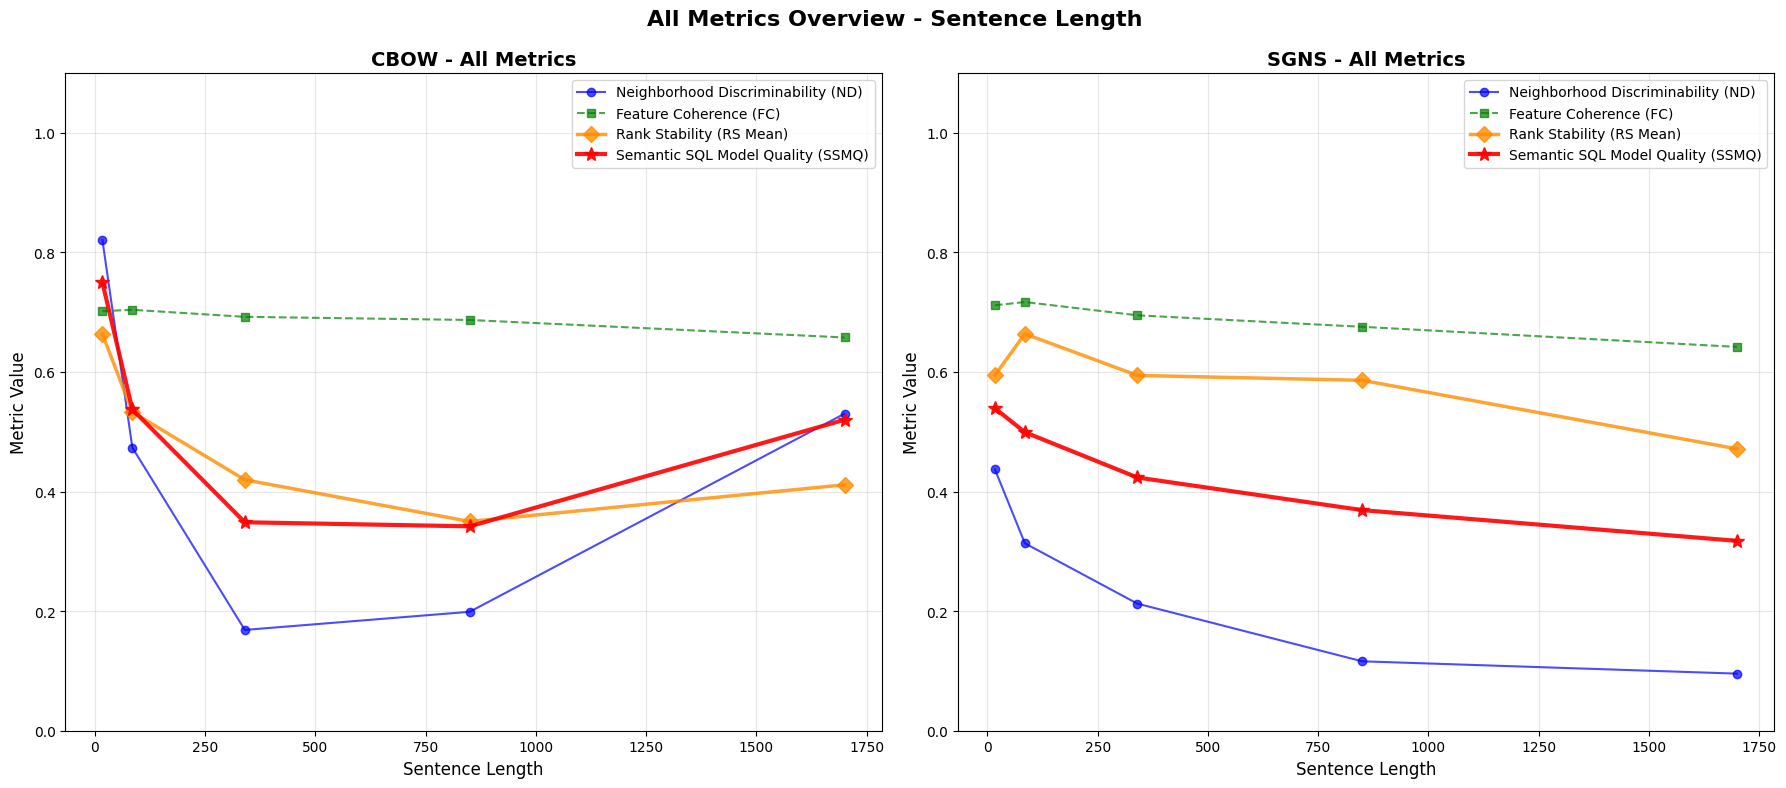

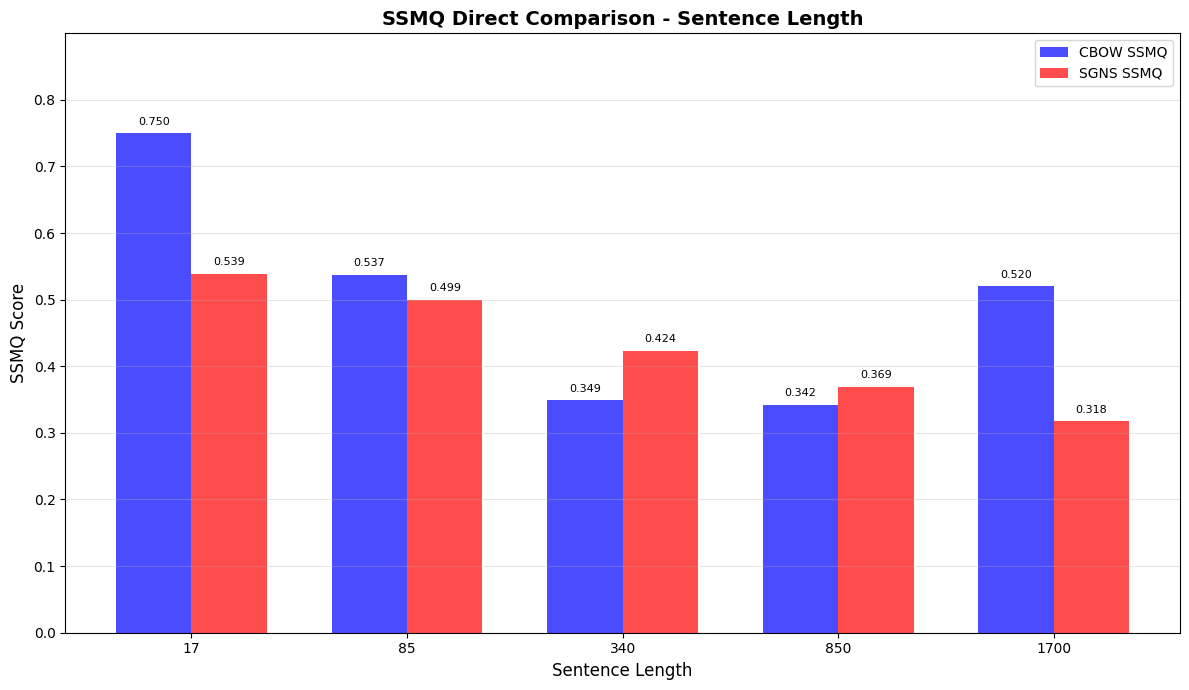


=== DETAILPLOTS FÜR KATEGORIE: SENTENCE ===


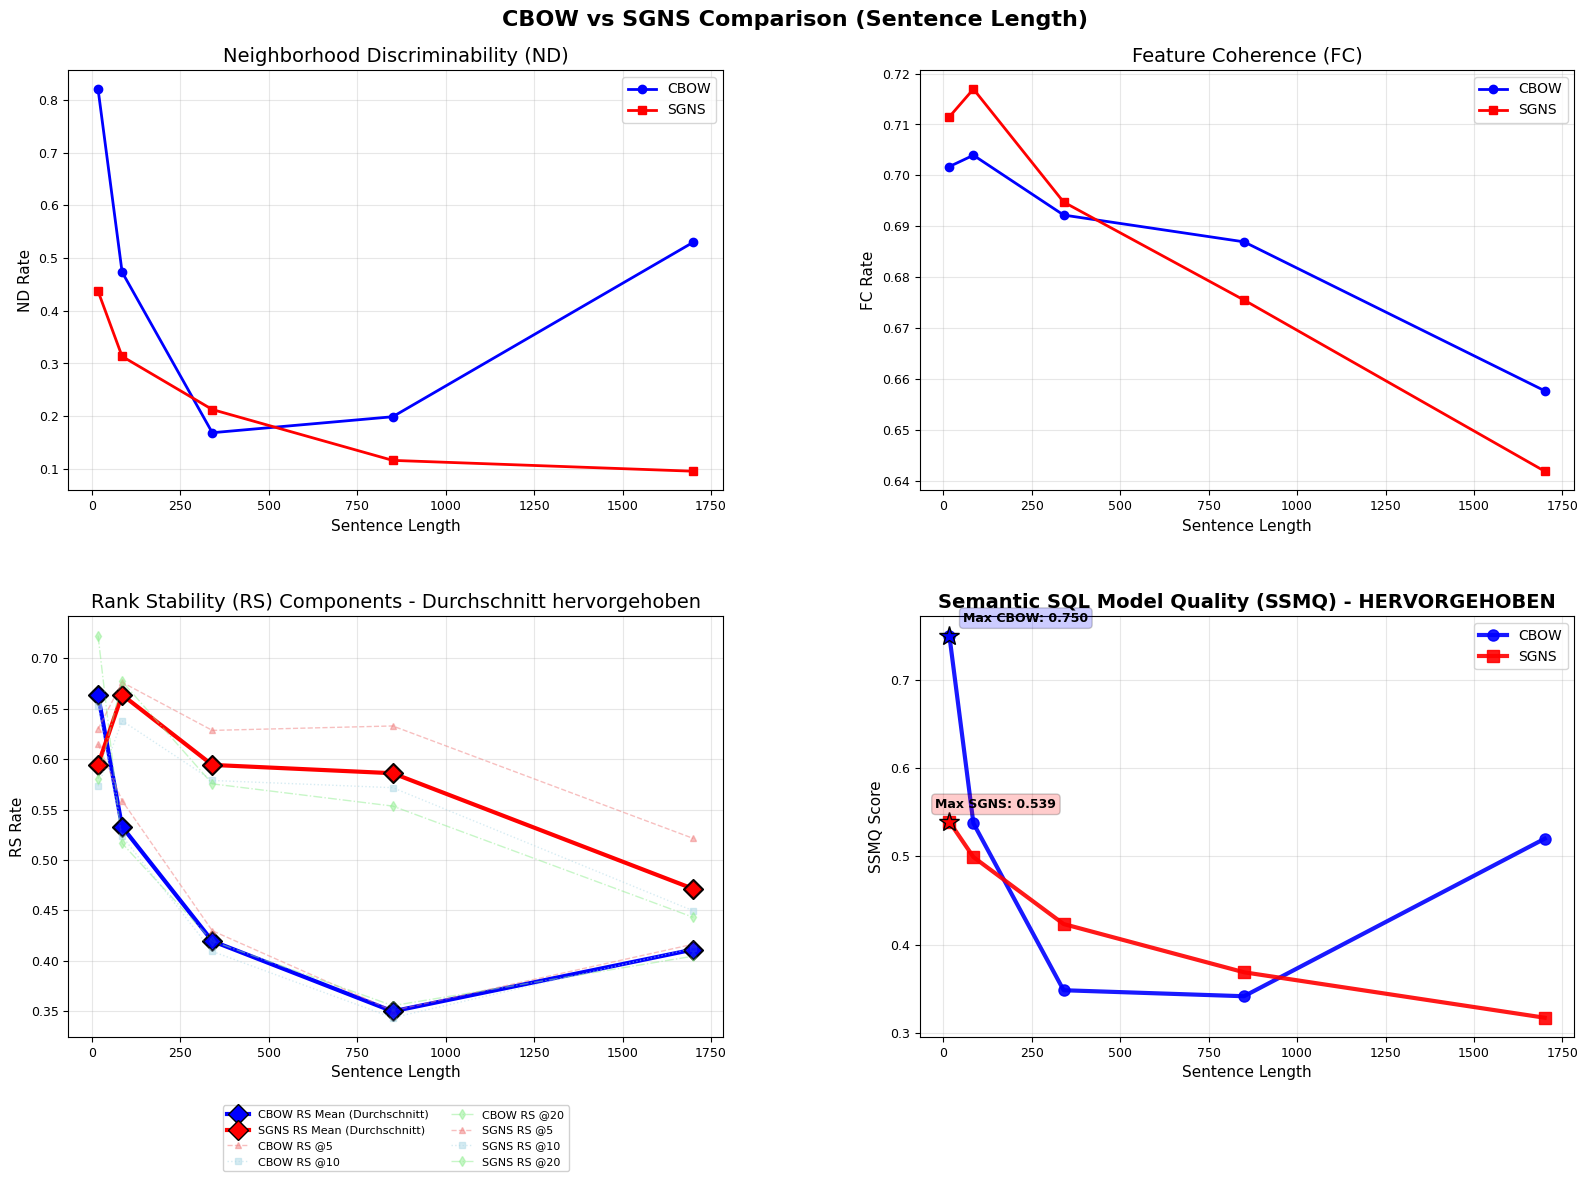


COMPREHENSIVE DATA FOR CATEGORY: SENTENCE

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Sentence Length CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
17              0.8208   0.7017   0.7498   0.4372   0.7115   0.5392  
85              0.4735   0.704    0.5374   0.3134   0.717    0.4992  
340             0.1686   0.6922   0.3486   0.2126   0.6948   0.4235  
850             0.1989   0.687    0.3418   0.1161   0.6755   0.3689  
1700            0.5302   0.6577   0.52     0.0955   0.6419   0.3175  

DETAILED RANK STABILITY (RS) COMPONENTS:
----------------------------------------------------------------------------------------------------
Sentence Length CBOW RS COMPONENTS:                           SGNS RS COMPONENTS:                          
                Mean     @5      

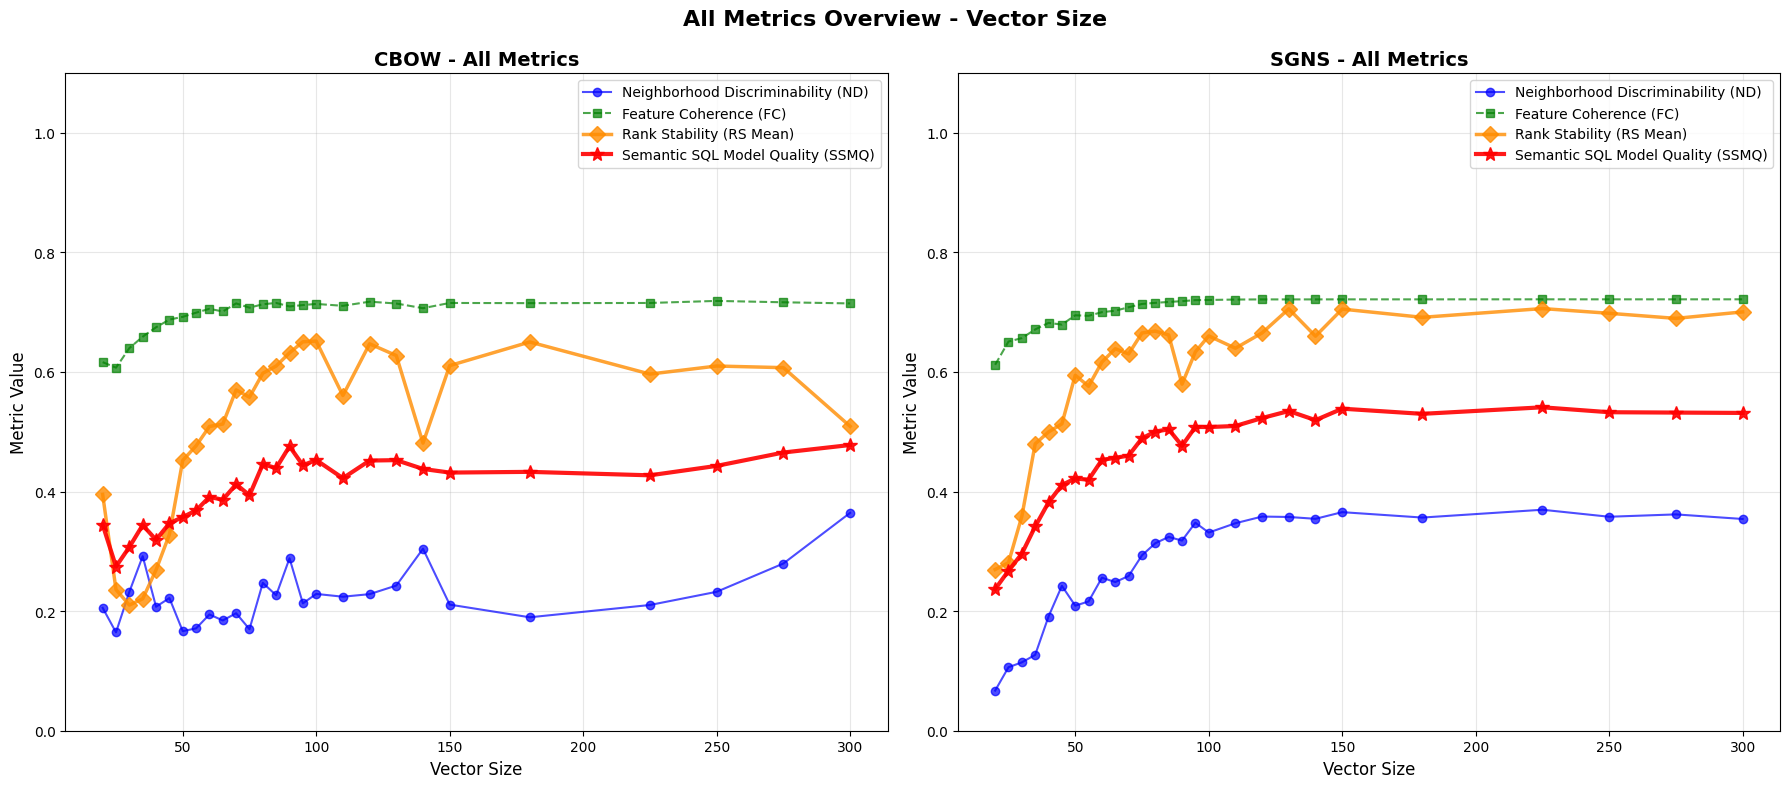

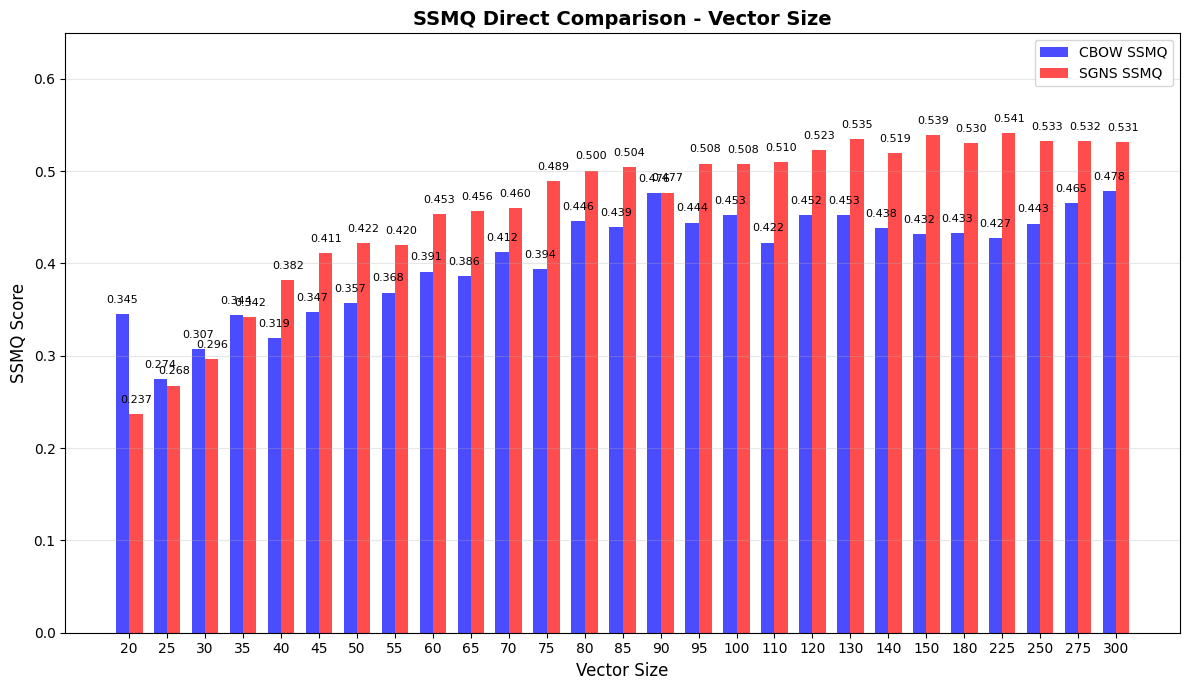


=== DETAILPLOTS FÜR KATEGORIE: VECTOR ===


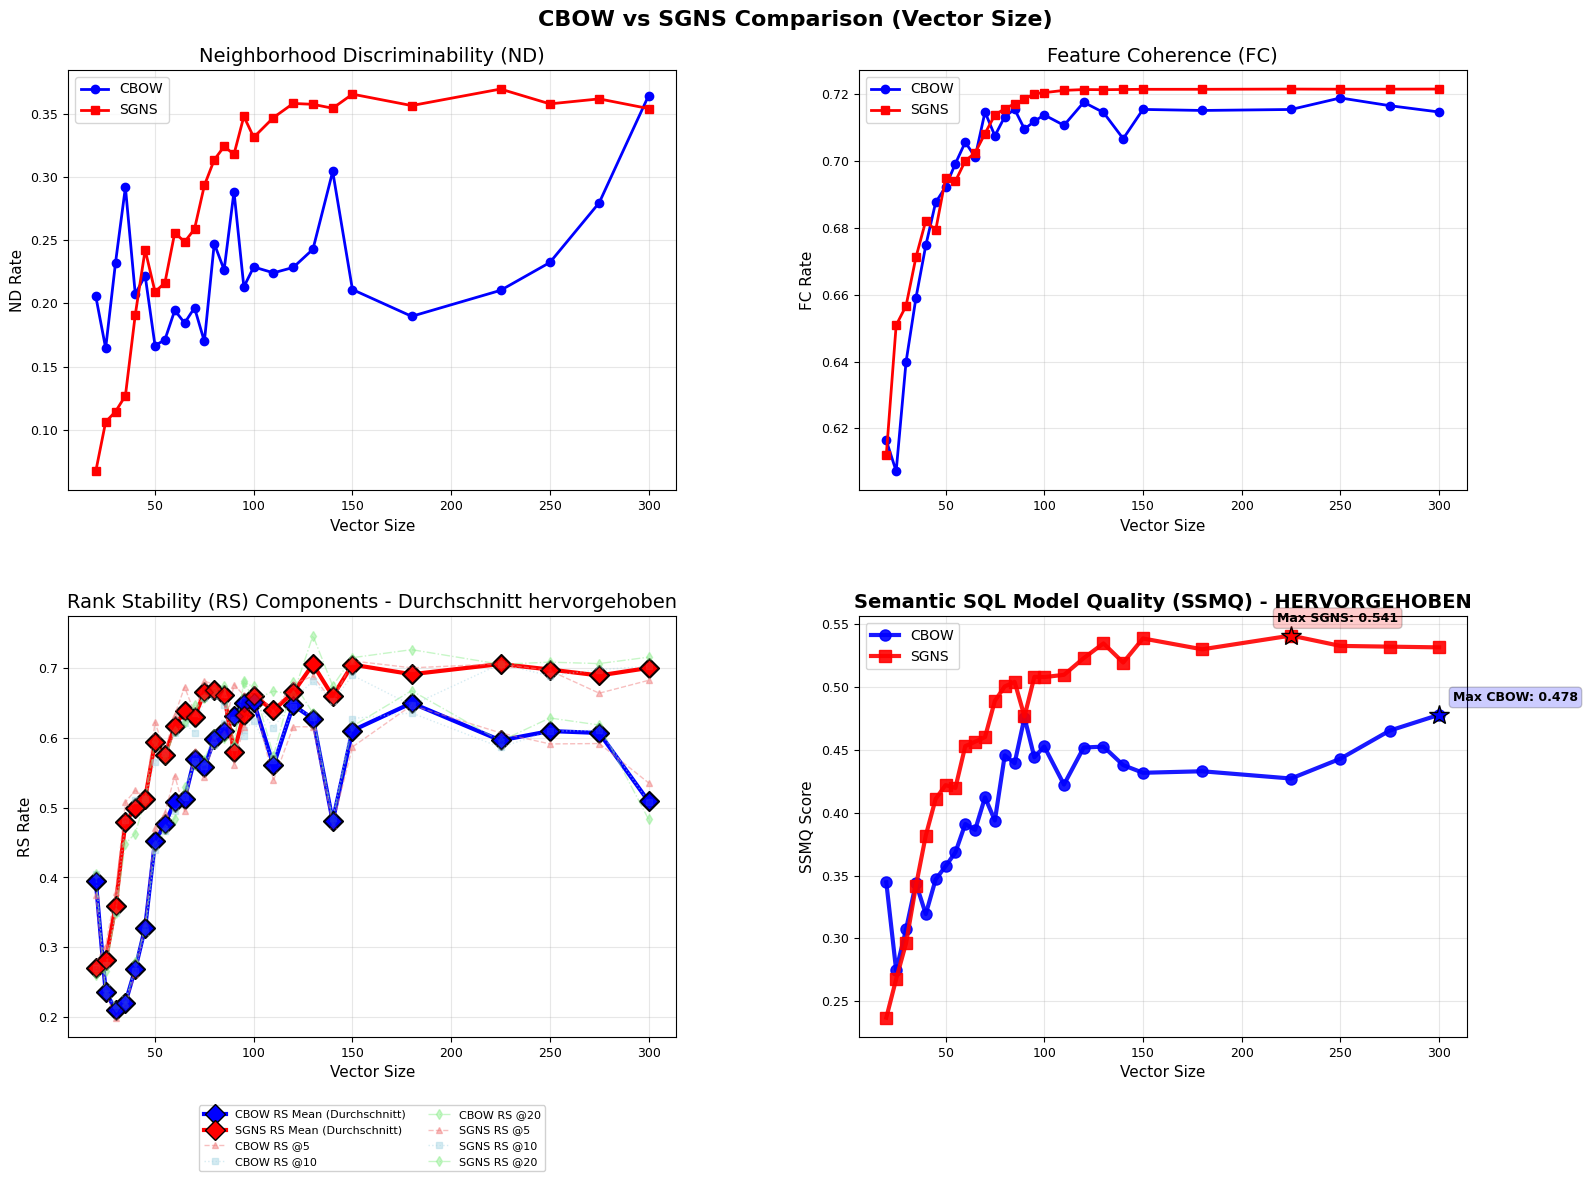


COMPREHENSIVE DATA FOR CATEGORY: VECTOR

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Vector Size     CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
20              0.2056   0.6164   0.3446   0.0671   0.612    0.2369  
25              0.1645   0.6072   0.2745   0.1062   0.6509   0.2676  
30              0.2322   0.6399   0.3071   0.1143   0.6566   0.2961  
35              0.2919   0.659    0.3439   0.1269   0.6711   0.3416  
40              0.2073   0.6747   0.3193   0.191    0.6821   0.3818  
45              0.2219   0.6876   0.3469   0.2423   0.6792   0.411   
50              0.1666   0.6922   0.3573   0.2091   0.6948   0.4219  
55              0.1712   0.6992   0.3684   0.2162   0.6939   0.4197  
60              0.1944   0.7056   0.391    0.2559   0.7      0.4529  
65    

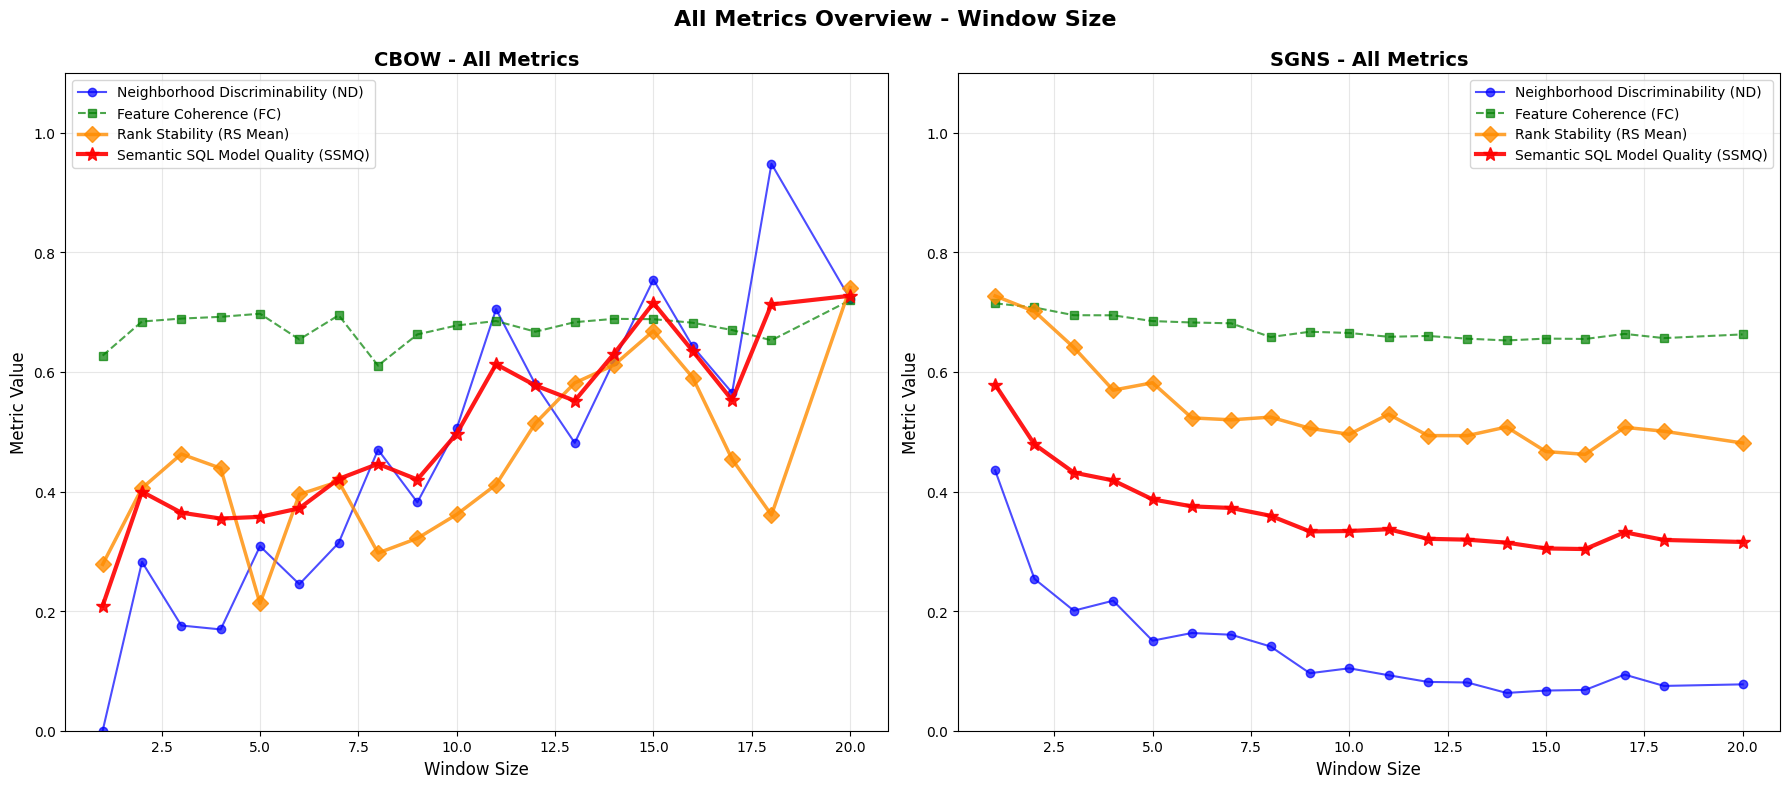

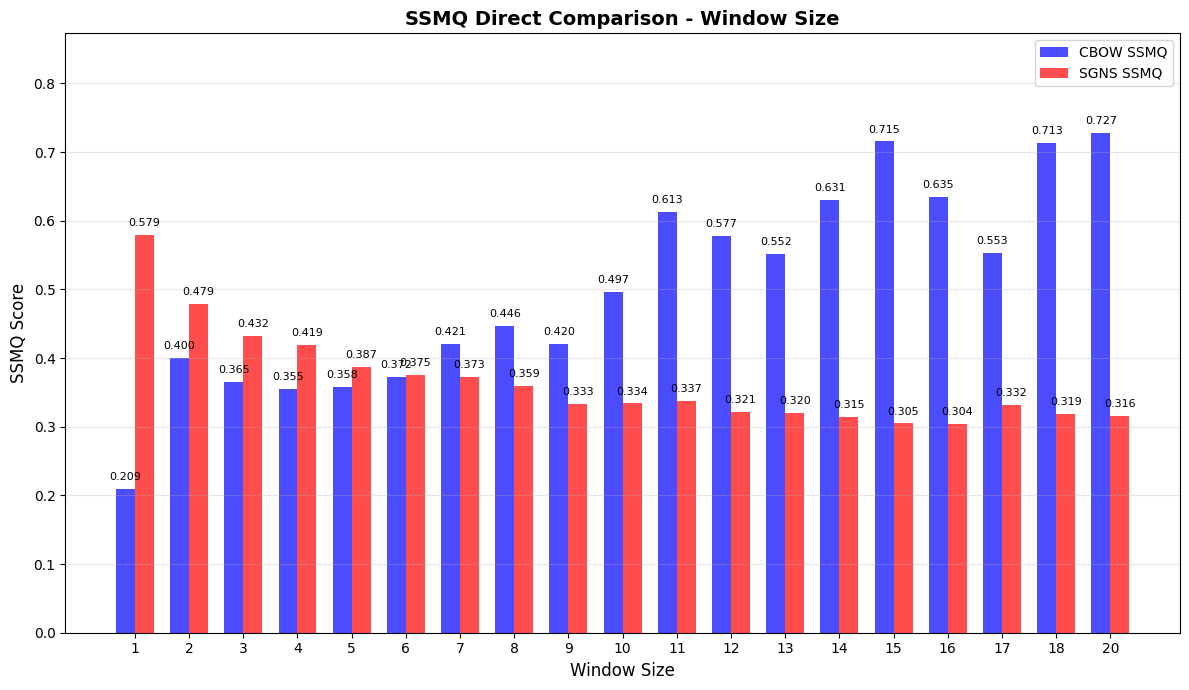


=== DETAILPLOTS FÜR KATEGORIE: WINDOWSIZE ===


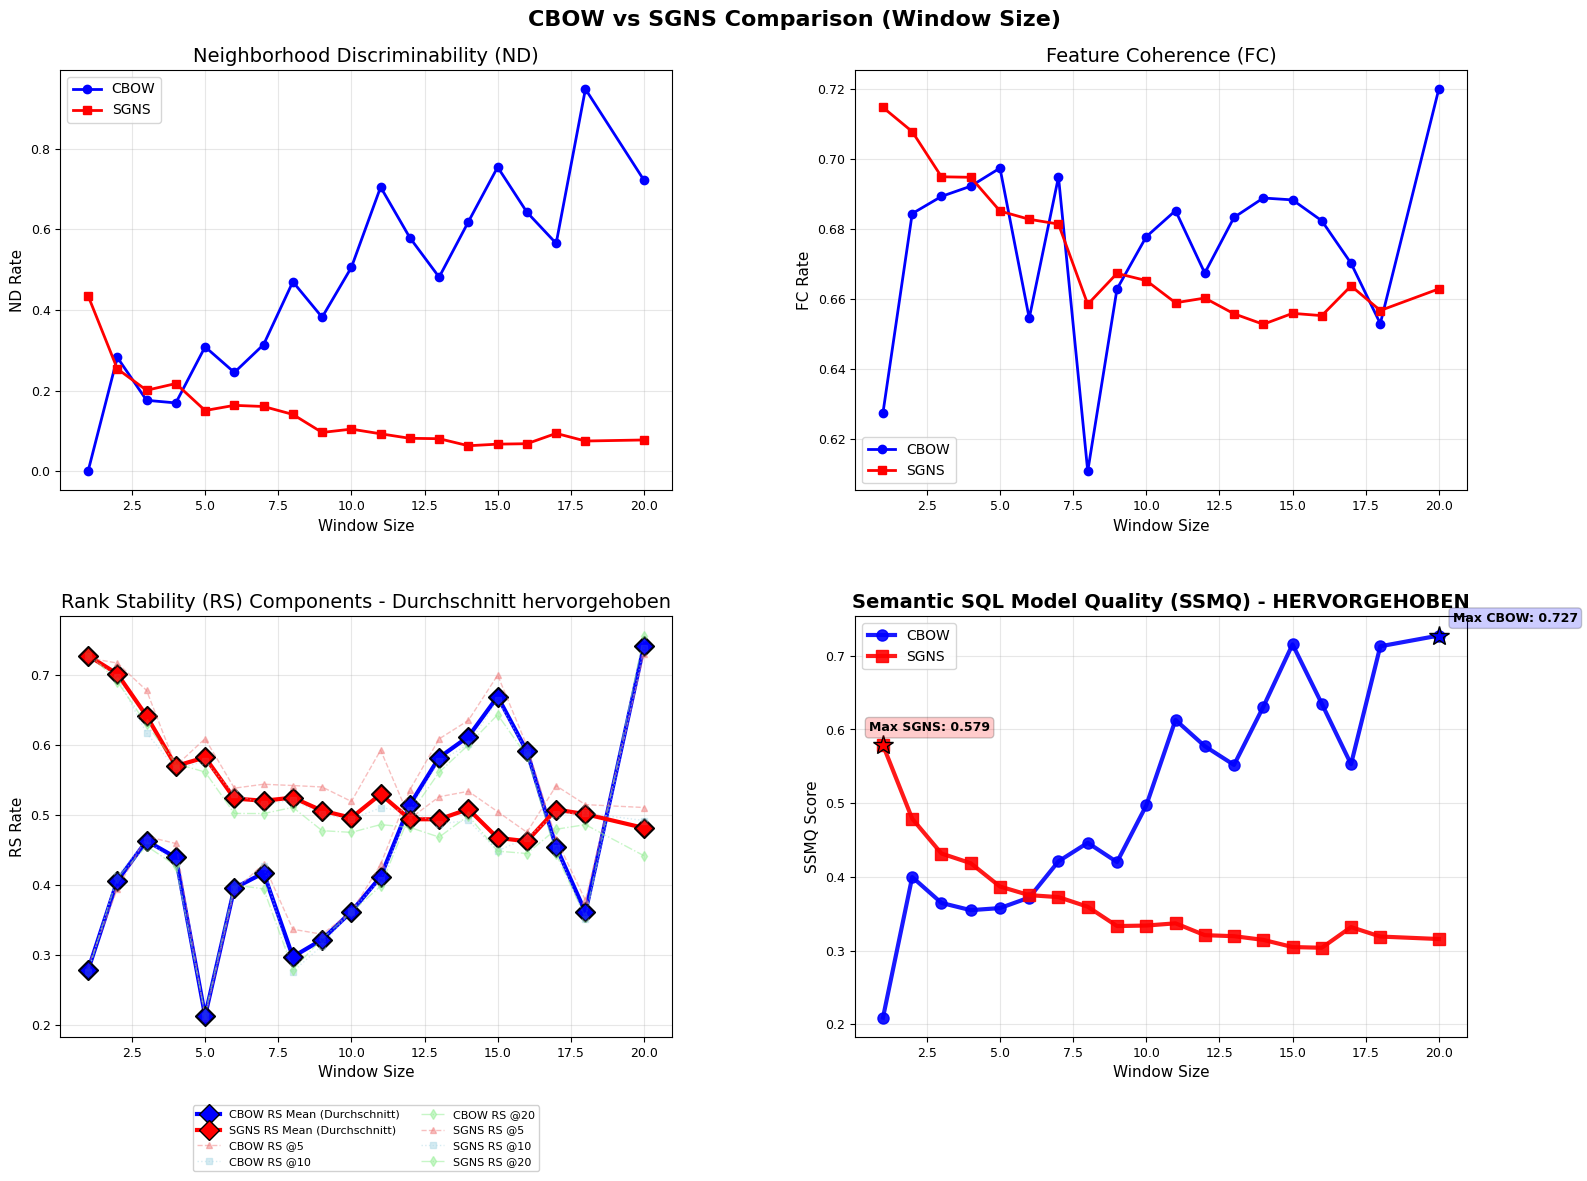


COMPREHENSIVE DATA FOR CATEGORY: WINDOWSIZE

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Window Size     CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
1               0.0      0.6273   0.2089   0.4354   0.7148   0.5788  
2               0.2823   0.6844   0.3997   0.2539   0.7078   0.4789  
3               0.176    0.6893   0.3647   0.2008   0.6949   0.4317  
4               0.1694   0.6922   0.3548   0.2175   0.6948   0.4186  
5               0.3086   0.6974   0.3577   0.1506   0.6851   0.3869  
6               0.245    0.6544   0.372    0.1634   0.6827   0.3752  
7               0.3142   0.6949   0.4211   0.1606   0.6814   0.3725  
8               0.47     0.6106   0.4463   0.1409   0.6584   0.3595  
9               0.382    0.6628   0.4201   0.0962   0.6673   0.3333  
10

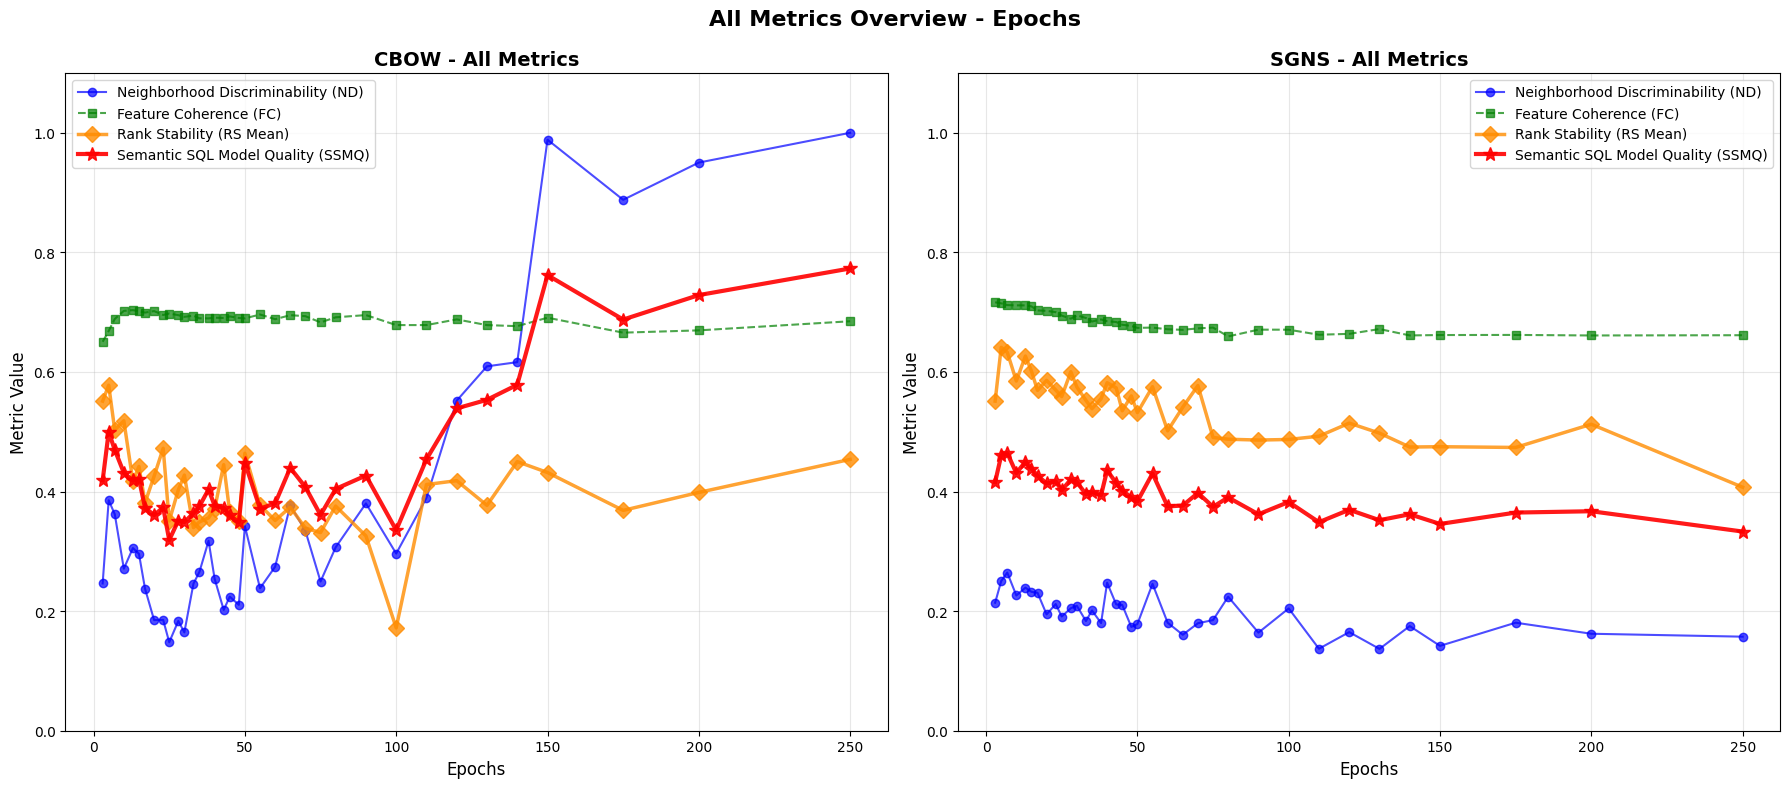

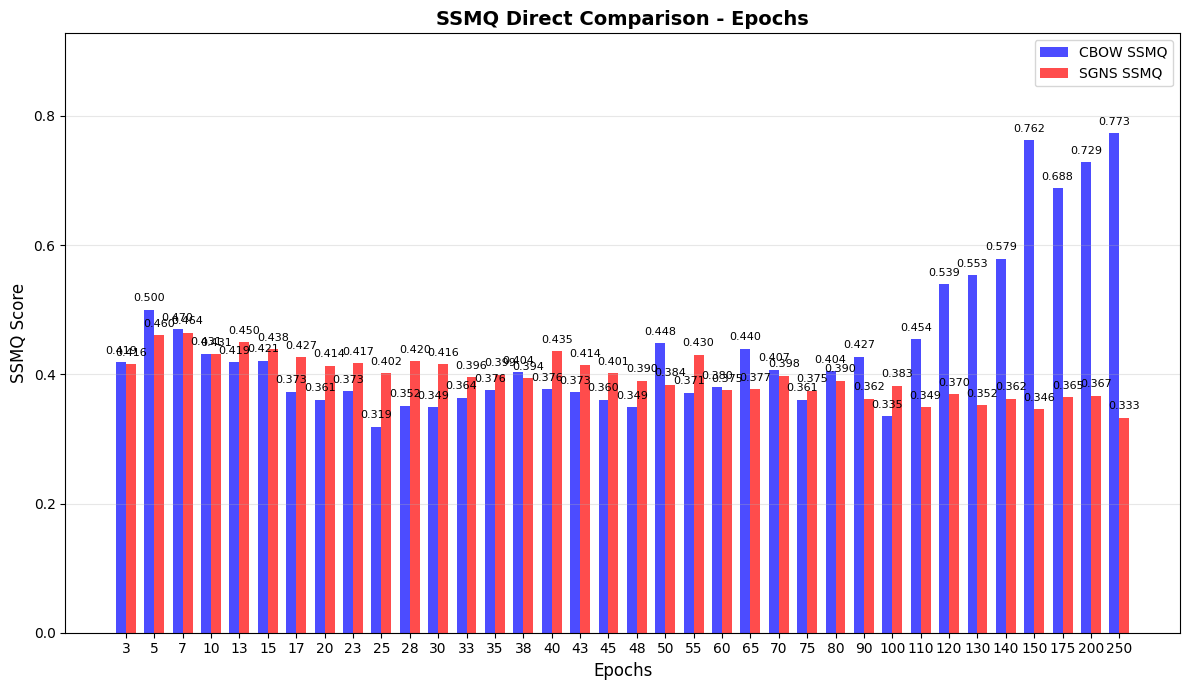


=== DETAILPLOTS FÜR KATEGORIE: EPOCH ===


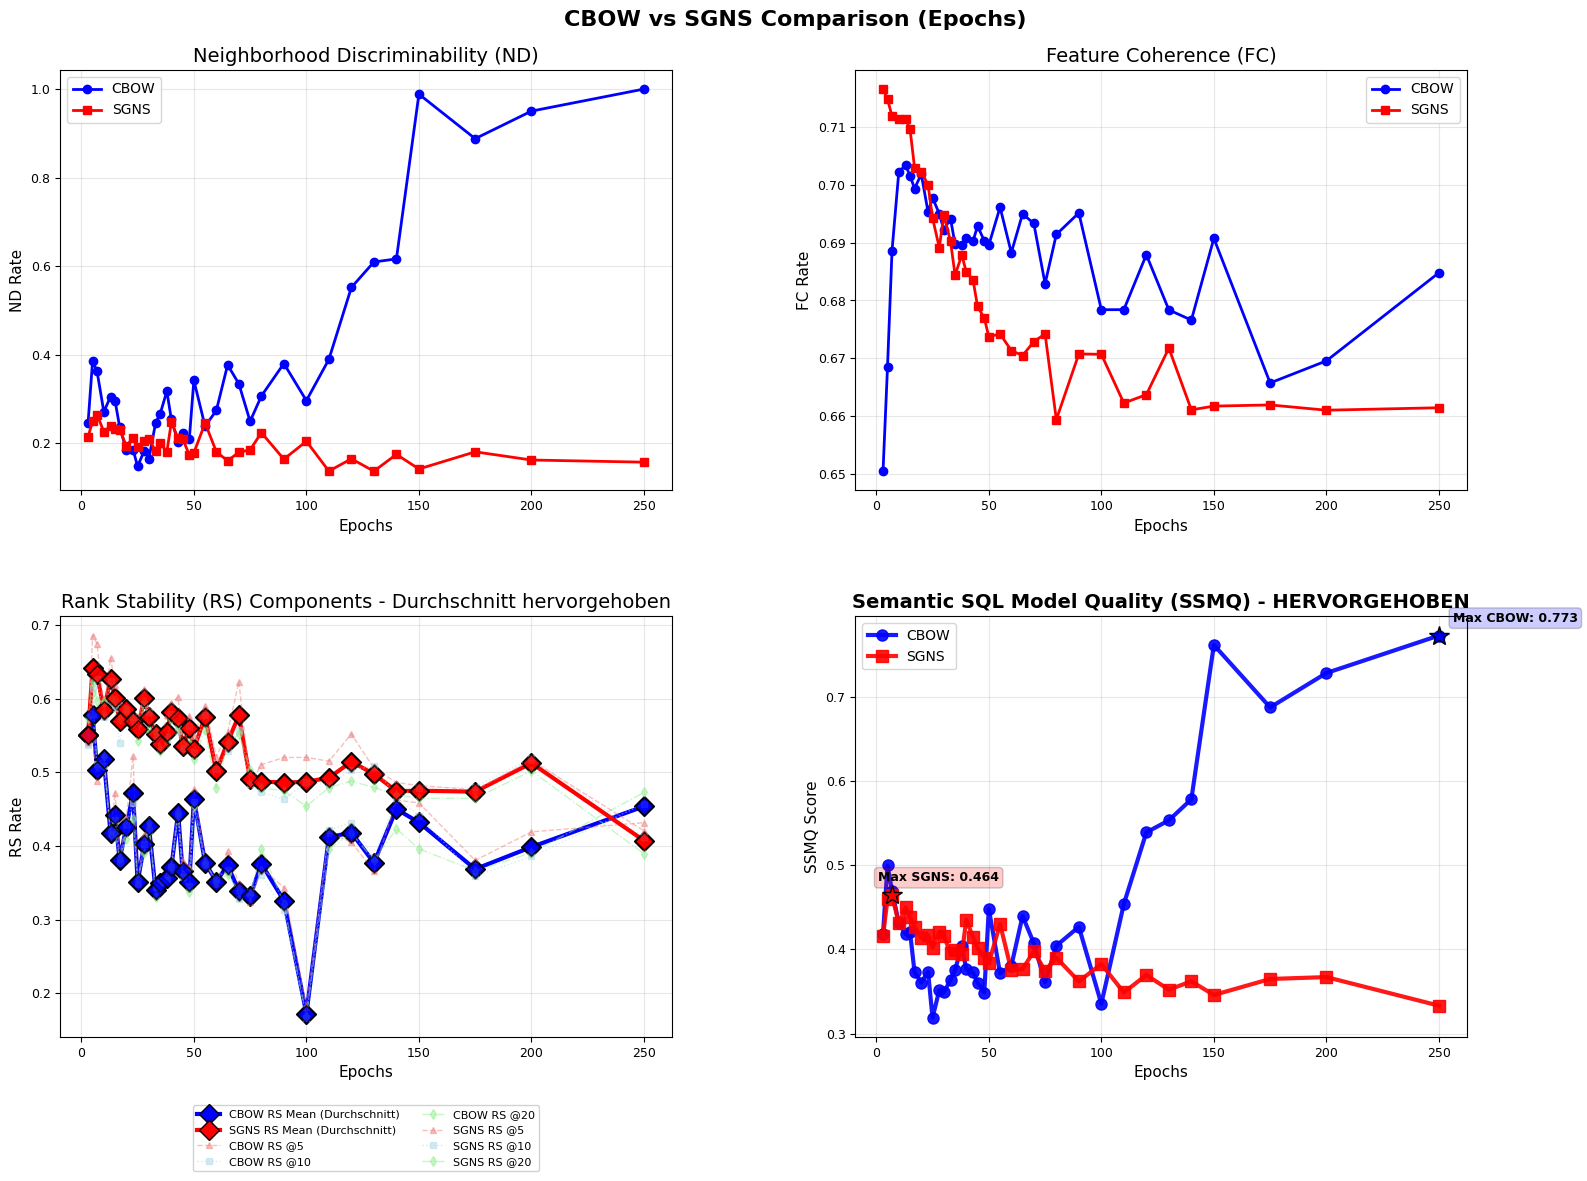


COMPREHENSIVE DATA FOR CATEGORY: EPOCH

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Epochs          CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
3               0.2463   0.6505   0.4186   0.2141   0.7165   0.4157  
5               0.3854   0.6686   0.4998   0.2503   0.7148   0.4605  
7               0.3622   0.6886   0.4697   0.2644   0.7118   0.4645  
10              0.271    0.7022   0.4315   0.2262   0.7114   0.4308  
13              0.3055   0.7034   0.4185   0.2393   0.7114   0.4499  
15              0.2957   0.7016   0.4208   0.2323   0.7096   0.4385  
17              0.2376   0.6994   0.373    0.2307   0.703    0.4267  
20              0.1851   0.7018   0.3606   0.1946   0.7022   0.4135  
23              0.1853   0.6953   0.3734   0.2118   0.7      0.4169  
25     

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Daten nach Kategorien und Algorithmen strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        # Erweiterte Datenstruktur für alle Metriken
        data_by_category[category] = {
            'CBOW': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            },
            'SGNS': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            }
        }
    
    # Determine which parameter is relevant for this category
    if category == 'sentence':
        x_value = result['params']['Satzlänge']
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_value = result['params']['Vector Size']
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_value = result['params']['Window']
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_value = result['params']['Epochs']
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_value = result['params']['Negative Sampling']
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_value = result['params']['Sample']
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_value = result['params']['Hierarchical Softmax']
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_value = result['params']['Alpha']
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_value = None
        x_label = 'UNKNOWN - PLEASE SET'
        title_category = category
        print(f"Unknown category: {category}")
    
    # Extract all metrics if they exist - KORRIGIERT für nd
    # nd ist jetzt ein einzelner Wert, keine Liste mehr
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            # Direkter Zugriff wenn es ein Skalar ist
            nd_value = float(result['nd'])
    
    # Extract other metrics
    rs_mean_value = float(result['rs_mean']) if 'rs_mean' in result else None
    rs_5_value = float(result['rs_5']) if 'rs_5' in result else None
    rs_10_value = float(result['rs_10']) if 'rs_10' in result else None
    rs_20_value = float(result['rs_20']) if 'rs_20' in result else None
    fc_value = float(result['fc']) if 'fc' in result else None
    ssmq_value = float(result['ssmq']) if 'ssmq' in result else None
    
    if x_value is not None:
        # Store all available metrics
        metrics = [
            ('nd', nd_value),
            ('rs_mean', rs_mean_value),
            ('rs_5', rs_5_value),
            ('rs_10', rs_10_value),
            ('rs_20', rs_20_value),
            ('fc', fc_value),
            ('ssmq', ssmq_value)
        ]
        
        for metric_name, metric_value in metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value

# Create plots for each category
print("=== COMPREHENSIVE METRICS COMPARISON ===")
for category, category_data in data_by_category.items():
    # Get the correct labels for this category
    if category == 'sentence':
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_label = 'X-Axis'
        title_category = category
    
    # ERSTER PLOT: Übersichtsplot mit allen 4 Metriken
    print(f"\n=== ÜBERSICHTPLOT FÜR KATEGORIE: {category.upper()} ===")
    
    # Find common x-values for CBOW and SGNS
    all_x_cbow = set()
    all_x_sgns = set()
    
    for metric in ['nd', 'fc', 'ssmq', 'rs_mean']:
        all_x_cbow.update(category_data['CBOW'][metric].keys())
        all_x_sgns.update(category_data['SGNS'][metric].keys())
    
    common_x_cbow = sorted(all_x_cbow)
    common_x_sgns = sorted(all_x_sgns)
    
    if common_x_cbow or common_x_sgns:
        # Create overview plot with all 4 metrics
        fig_overview, (ax_overview_cbow, ax_overview_sgns) = plt.subplots(1, 2, figsize=(18, 8))
        fig_overview.suptitle(f'All Metrics Overview - {title_category}', fontsize=16, fontweight='bold')
        
        # Define colors for different metrics
        metric_colors = {
            'nd': 'blue',
            'fc': 'green',
            'rs_mean': 'darkorange',
            'ssmq': 'red'
        }
        
        metric_styles = {
            'nd': 'solid',
            'fc': 'dashed',
            'rs_mean': 'solid',
            'ssmq': 'solid'
        }
        
        metric_linewidths = {
            'nd': 1.5,
            'fc': 1.5,
            'rs_mean': 2.5,  # RS Mean dicker
            'ssmq': 3.0  # SSMQ am dicksten
        }
        
        metric_markers = {
            'nd': 'o',
            'fc': 's',
            'rs_mean': 'D',  # Diamant für RS Mean
            'ssmq': '*'
        }
        
        metric_labels = {
            'nd': 'Neighborhood Discriminability (ND)',
            'fc': 'Feature Coherence (FC)',
            'rs_mean': 'Rank Stability (RS Mean)',
            'ssmq': 'Semantic SQL Model Quality (SSMQ)'
        }
        
        # Plot CBOW metrics
        ax_overview_cbow.set_title('CBOW - All Metrics', fontsize=14, fontweight='bold')
        
        for metric in ['nd', 'fc', 'rs_mean', 'ssmq']:
            data = category_data['CBOW'][metric]
            if data and common_x_cbow:
                x_values = sorted(data.keys())
                y_values = [data[x] for x in x_values]
                
                # Interpolate if some x-values are missing
                if len(x_values) < len(common_x_cbow):
                    # Simple linear interpolation for missing values
                    from scipy import interpolate
                    if len(x_values) > 1:
                        f = interpolate.interp1d(x_values, y_values, kind='linear', fill_value='extrapolate')
                        x_interp = common_x_cbow
                        y_interp = f(common_x_cbow)
                        ax_overview_cbow.plot(x_interp, y_interp, 
                                            color=metric_colors[metric],
                                            linestyle=metric_styles[metric],
                                            linewidth=metric_linewidths[metric],
                                            marker=metric_markers[metric],
                                            markersize=10 if metric == 'ssmq' else 8 if metric == 'rs_mean' else 6,
                                            label=metric_labels[metric],
                                            alpha=0.9 if metric == 'ssmq' else 0.8 if metric == 'rs_mean' else 0.7)
                    else:
                        # Not enough points for interpolation, plot as scatter
                        ax_overview_cbow.scatter(x_values, y_values,
                                               color=metric_colors[metric],
                                               marker=metric_markers[metric],
                                               s=120 if metric == 'ssmq' else 100 if metric == 'rs_mean' else 60,
                                               label=metric_labels[metric],
                                               alpha=0.9 if metric == 'ssmq' else 0.8 if metric == 'rs_mean' else 0.7)
                else:
                    # Plot all data points
                    ax_overview_cbow.plot(x_values, y_values,
                                        color=metric_colors[metric],
                                        linestyle=metric_styles[metric],
                                        linewidth=metric_linewidths[metric],
                                        marker=metric_markers[metric],
                                        markersize=10 if metric == 'ssmq' else 8 if metric == 'rs_mean' else 6,
                                        label=metric_labels[metric],
                                        alpha=0.9 if metric == 'ssmq' else 0.8 if metric == 'rs_mean' else 0.7)
        
        ax_overview_cbow.set_xlabel(x_label, fontsize=12)
        ax_overview_cbow.set_ylabel('Metric Value', fontsize=12)
        ax_overview_cbow.grid(True, alpha=0.3)
        ax_overview_cbow.legend(fontsize=10, loc='best')
        ax_overview_cbow.set_ylim([0, 1.1])  # Assuming metrics are in [0,1] range
        
        # Plot SGNS metrics
        ax_overview_sgns.set_title('SGNS - All Metrics', fontsize=14, fontweight='bold')
        
        for metric in ['nd', 'fc', 'rs_mean', 'ssmq']:
            data = category_data['SGNS'][metric]
            if data and common_x_sgns:
                x_values = sorted(data.keys())
                y_values = [data[x] for x in x_values]
                
                # Interpolate if some x-values are missing
                if len(x_values) < len(common_x_sgns):
                    # Simple linear interpolation for missing values
                    from scipy import interpolate
                    if len(x_values) > 1:
                        f = interpolate.interp1d(x_values, y_values, kind='linear', fill_value='extrapolate')
                        x_interp = common_x_sgns
                        y_interp = f(common_x_sgns)
                        ax_overview_sgns.plot(x_interp, y_interp, 
                                            color=metric_colors[metric],
                                            linestyle=metric_styles[metric],
                                            linewidth=metric_linewidths[metric],
                                            marker=metric_markers[metric],
                                            markersize=10 if metric == 'ssmq' else 8 if metric == 'rs_mean' else 6,
                                            label=metric_labels[metric],
                                            alpha=0.9 if metric == 'ssmq' else 0.8 if metric == 'rs_mean' else 0.7)
                    else:
                        # Not enough points for interpolation, plot as scatter
                        ax_overview_sgns.scatter(x_values, y_values,
                                               color=metric_colors[metric],
                                               marker=metric_markers[metric],
                                               s=120 if metric == 'ssmq' else 100 if metric == 'rs_mean' else 60,
                                               label=metric_labels[metric],
                                               alpha=0.9 if metric == 'ssmq' else 0.8 if metric == 'rs_mean' else 0.7)
                else:
                    # Plot all data points
                    ax_overview_sgns.plot(x_values, y_values,
                                        color=metric_colors[metric],
                                        linestyle=metric_styles[metric],
                                        linewidth=metric_linewidths[metric],
                                        marker=metric_markers[metric],
                                        markersize=10 if metric == 'ssmq' else 8 if metric == 'rs_mean' else 6,
                                        label=metric_labels[metric],
                                        alpha=0.9 if metric == 'ssmq' else 0.8 if metric == 'rs_mean' else 0.7)
        
        ax_overview_sgns.set_xlabel(x_label, fontsize=12)
        ax_overview_sgns.set_ylabel('Metric Value', fontsize=12)
        ax_overview_sgns.grid(True, alpha=0.3)
        ax_overview_sgns.legend(fontsize=10, loc='best')
        ax_overview_sgns.set_ylim([0, 1.1])  # Assuming metrics are in [0,1] range
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()
        
        # Zusätzlicher kombinierter Plot: CBOW und SGNS SSMQ im direkten Vergleich
        fig_ssmq_comparison, ax_ssmq = plt.subplots(figsize=(12, 7))
        
        # Find common x-values for SSMQ comparison
        cbow_ssmq_data = category_data['CBOW']['ssmq']
        sgns_ssmq_data = category_data['SGNS']['ssmq']
        
        if cbow_ssmq_data and sgns_ssmq_data:
            # Find intersection of x-values
            common_x_ssmq = sorted(set(cbow_ssmq_data.keys()) & set(sgns_ssmq_data.keys()))
            
            if common_x_ssmq:
                cbow_y = [cbow_ssmq_data[x] for x in common_x_ssmq]
                sgns_y = [sgns_ssmq_data[x] for x in common_x_ssmq]
                
                # Bar width
                bar_width = 0.35
                x_indices = np.arange(len(common_x_ssmq))
                
                # Plot bars
                bars_cbow = ax_ssmq.bar(x_indices - bar_width/2, cbow_y, bar_width,
                                      color='blue', alpha=0.7, label='CBOW SSMQ')
                bars_sgns = ax_ssmq.bar(x_indices + bar_width/2, sgns_y, bar_width,
                                      color='red', alpha=0.7, label='SGNS SSMQ')
                
                # Add value labels on bars
                def autolabel(bars):
                    for bar in bars:
                        height = bar.get_height()
                        ax_ssmq.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)
                
                autolabel(bars_cbow)
                autolabel(bars_sgns)
                
                ax_ssmq.set_xlabel(x_label, fontsize=12)
                ax_ssmq.set_ylabel('SSMQ Score', fontsize=12)
                ax_ssmq.set_title(f'SSMQ Direct Comparison - {title_category}', fontsize=14, fontweight='bold')
                ax_ssmq.set_xticks(x_indices)
                ax_ssmq.set_xticklabels(common_x_ssmq)
                ax_ssmq.legend(fontsize=10)
                ax_ssmq.grid(True, alpha=0.3, axis='y')
                ax_ssmq.set_ylim([0, max(max(cbow_y), max(sgns_y)) * 1.2])
                
                plt.tight_layout()
                plt.show()
    
    # ZWEITER PLOT: Originale 4 Subplots (wie zuvor)
    print(f"\n=== DETAILPLOTS FÜR KATEGORIE: {category.upper()} ===")
    
    # Create figure with 4 subplots (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'CBOW vs SGNS Comparison ({title_category})', fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    axs = axes.flatten()
    
    # 1. Plot ND (Top Left)
    ax1 = axs[0]
    cbow_nd_data = category_data['CBOW']['nd']
    sgns_nd_data = category_data['SGNS']['nd']
    
    has_nd_data = False
    if cbow_nd_data:
        x_cbow = sorted(cbow_nd_data.keys())
        y_cbow = [cbow_nd_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        has_nd_data = True
    
    if sgns_nd_data:
        x_sgns = sorted(sgns_nd_data.keys())
        y_sgns = [sgns_nd_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        has_nd_data = True
    
    if has_nd_data:
        ax1.set_title('Neighborhood Discriminability (ND)', fontsize=14)
        ax1.set_xlabel(x_label, fontsize=11)
        ax1.set_ylabel('ND Rate', fontsize=11)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
    else:
        ax1.text(0.5, 0.5, 'No ND data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax1.transAxes, fontsize=12)
        ax1.set_title('Neighborhood Discriminability (ND)', fontsize=14)
    
    # 2. Plot FC (Top Right)
    ax2 = axs[1]
    cbow_fc_data = category_data['CBOW']['fc']
    sgns_fc_data = category_data['SGNS']['fc']
    
    has_fc_data = False
    if cbow_fc_data:
        x_cbow = sorted(cbow_fc_data.keys())
        y_cbow = [cbow_fc_data[x] for x in x_cbow]
        ax2.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        has_fc_data = True
    
    if sgns_fc_data:
        x_sgns = sorted(sgns_fc_data.keys())
        y_sgns = [sgns_fc_data[x] for x in x_sgns]
        ax2.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        has_fc_data = True
    
    if has_fc_data:
        ax2.set_title('Feature Coherence (FC)', fontsize=14)
        ax2.set_xlabel(x_label, fontsize=11)
        ax2.set_ylabel('FC Rate', fontsize=11)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No FC data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax2.transAxes, fontsize=12)
        ax2.set_title('Feature Coherence (FC)', fontsize=14)
    
    # 3. Plot RS Components (Bottom Left) - MIT HERVORGEHOBENEM DURCHSCHNITTSWERT
    ax3 = axs[2]
    
    # Definiere Farben und Stile für RS-Metriken - DURCHSCHNITT HERAUSGEHOBEN
    rs_metrics = [
        ('rs_mean', 'RS Mean (Durchschnitt)', 'darkorange', '-', 'D', 3.0, 10, 1.0),  # Dick, sichtbar
        ('rs_5', 'RS @5', 'lightcoral', '--', '^', 1.0, 5, 0.5),      # Dünn, dezenter
        ('rs_10', 'RS @10', 'lightblue', ':', 's', 1.0, 5, 0.5),      # Dünn, dezenter
        ('rs_20', 'RS @20', 'lightgreen', '-.', 'd', 1.0, 5, 0.5)     # Dünn, dezenter
    ]
    
    # Plot CBOW RS metrics - MIT UNTERSCHIEDLICHER HERVORHEBUNG
    for rs_key, rs_label, color, linestyle, marker, linewidth, markersize, alpha in rs_metrics:
        cbow_rs_data = category_data['CBOW'][rs_key]
        if cbow_rs_data:
            x_cbow = sorted(cbow_rs_data.keys())
            y_cbow = [cbow_rs_data[x] for x in x_cbow]
            # Unterscheide zwischen Durchschnitt und Teilwerten
            if rs_key == 'rs_mean':
                # Durchschnitt: Dicke Linie, sichtbare Farbe
                ax3.plot(x_cbow, y_cbow, color='blue', linestyle=linestyle,
                        linewidth=linewidth, marker=marker, markersize=markersize, 
                        label=f'CBOW {rs_label}', alpha=alpha, markeredgecolor='black', markeredgewidth=1)
                # Zusätzlich Punkte mit Kontur für bessere Sichtbarkeit
                ax3.scatter(x_cbow, y_cbow, color='blue', marker=marker, 
                          s=80, alpha=0.8, edgecolor='black', linewidth=1, zorder=5)
            else:
                # Teilwerte: Dünnere Linie, hellere Farben
                ax3.plot(x_cbow, y_cbow, color=color, linestyle=linestyle,
                        linewidth=linewidth, marker=marker, markersize=markersize, 
                        label=f'CBOW {rs_label}', alpha=alpha)
    
    # Plot SGNS RS metrics - MIT UNTERSCHIEDLICHER HERVORHEBUNG
    for rs_key, rs_label, color, linestyle, marker, linewidth, markersize, alpha in rs_metrics:
        sgns_rs_data = category_data['SGNS'][rs_key]
        if sgns_rs_data:
            x_sgns = sorted(sgns_rs_data.keys())
            y_sgns = [sgns_rs_data[x] for x in x_sgns]
            # Unterscheide zwischen Durchschnitt und Teilwerten
            if rs_key == 'rs_mean':
                # Durchschnitt: Dicke Linie, sichtbare Farbe
                ax3.plot(x_sgns, y_sgns, color='red', linestyle=linestyle,
                        linewidth=linewidth, marker=marker, markersize=markersize, 
                        label=f'SGNS {rs_label}', alpha=alpha, markeredgecolor='black', markeredgewidth=1)
                # Zusätzlich Punkte mit Kontur für bessere Sichtbarkeit
                ax3.scatter(x_sgns, y_sgns, color='red', marker=marker, 
                          s=80, alpha=0.8, edgecolor='black', linewidth=1, zorder=5)
            else:
                # Teilwerte: Dünnere Linie, hellere Farben
                ax3.plot(x_sgns, y_sgns, color=color, linestyle=linestyle,
                        linewidth=linewidth, marker=marker, markersize=markersize, 
                        label=f'SGNS {rs_label}', alpha=alpha)
    
    ax3.set_title('Rank Stability (RS) Components - Durchschnitt hervorgehoben', fontsize=14)
    ax3.set_xlabel(x_label, fontsize=11)
    ax3.set_ylabel('RS Rate', fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    # Legendengestaltung - Durchschnitt zuerst und hervorgehoben
    # Erstelle Dummy-Linien für die Legende in der richtigen Reihenfolge
    from matplotlib.lines import Line2D
    
    # Sortiere die Metriken: zuerst Durchschnitt, dann Teilwerte
    sorted_metrics = sorted(rs_metrics, key=lambda x: 0 if x[0] == 'rs_mean' else 1)
    
    legend_handles = []
    legend_labels = []
    
    # CBOW Durchschnitt zuerst
    for rs_key, rs_label, color, linestyle, marker, linewidth, markersize, alpha in sorted_metrics:
        if rs_key == 'rs_mean':
            handle = Line2D([0], [0], color='blue', linestyle=linestyle,
                          linewidth=linewidth, marker=marker, markersize=markersize,
                          markeredgecolor='black', markeredgewidth=1)
            legend_handles.append(handle)
            legend_labels.append(f'CBOW {rs_label}')
            break
    
    # SGNS Durchschnitt als nächstes
    for rs_key, rs_label, color, linestyle, marker, linewidth, markersize, alpha in sorted_metrics:
        if rs_key == 'rs_mean':
            handle = Line2D([0], [0], color='red', linestyle=linestyle,
                          linewidth=linewidth, marker=marker, markersize=markersize,
                          markeredgecolor='black', markeredgewidth=1)
            legend_handles.append(handle)
            legend_labels.append(f'SGNS {rs_label}')
            break
    
    # Dann die Teilwerte für CBOW
    for rs_key, rs_label, color, linestyle, marker, linewidth, markersize, alpha in sorted_metrics:
        if rs_key != 'rs_mean':
            handle = Line2D([0], [0], color=color, linestyle=linestyle,
                          linewidth=linewidth, marker=marker, markersize=markersize,
                          alpha=alpha)
            legend_handles.append(handle)
            legend_labels.append(f'CBOW {rs_label}')
    
    # Dann die Teilwerte für SGNS
    for rs_key, rs_label, color, linestyle, marker, linewidth, markersize, alpha in sorted_metrics:
        if rs_key != 'rs_mean':
            handle = Line2D([0], [0], color=color, linestyle=linestyle,
                          linewidth=linewidth, marker=marker, markersize=markersize,
                          alpha=alpha)
            legend_handles.append(handle)
            legend_labels.append(f'SGNS {rs_label}')
    
    # Legende mit 2 Spalten platzieren
    ax3.legend(legend_handles, legend_labels, fontsize=8, ncol=2, 
               loc='upper center', bbox_to_anchor=(0.5, -0.15),
               framealpha=0.9)
    
    # 4. Plot SSMQ (Bottom Right) - Final combined metric
    ax4 = axs[3]
    cbow_ssmq_data = category_data['CBOW']['ssmq']
    sgns_ssmq_data = category_data['SGNS']['ssmq']
    
    has_ssmq_data = False
    if cbow_ssmq_data:
        x_cbow = sorted(cbow_ssmq_data.keys())
        y_cbow = [cbow_ssmq_data[x] for x in x_cbow]
        ax4.plot(x_cbow, y_cbow, 'b-o', linewidth=3, markersize=8, label='CBOW', alpha=0.9)  # Dickere Linie für SSMQ
        has_ssmq_data = True
    
    if sgns_ssmq_data:
        x_sgns = sorted(sgns_ssmq_data.keys())
        y_sgns = [sgns_ssmq_data[x] for x in x_sgns]
        ax4.plot(x_sgns, y_sgns, 'r-s', linewidth=3, markersize=8, label='SGNS', alpha=0.9)  # Dickere Linie für SSMQ
        has_ssmq_data = True
    
    if has_ssmq_data:
        ax4.set_title('Semantic SQL Model Quality (SSMQ) - HERVORGEHOBEN', fontsize=14, fontweight='bold')
        ax4.set_xlabel(x_label, fontsize=11)
        ax4.set_ylabel('SSMQ Score', fontsize=11)
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
        
        # Highlight the highest SSMQ value for each algorithm
        if cbow_ssmq_data:
            max_cbow_x = max(cbow_ssmq_data, key=cbow_ssmq_data.get)
            max_cbow_y = cbow_ssmq_data[max_cbow_x]
            ax4.plot(max_cbow_x, max_cbow_y, 'b*', markersize=15, markeredgecolor='black', markeredgewidth=1)
            ax4.annotate(f'Max CBOW: {max_cbow_y:.3f}', 
                        xy=(max_cbow_x, max_cbow_y),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="blue", alpha=0.2))
        
        if sgns_ssmq_data:
            max_sgns_x = max(sgns_ssmq_data, key=sgns_ssmq_data.get)
            max_sgns_y = sgns_ssmq_data[max_sgns_x]
            ax4.plot(max_sgns_x, max_sgns_y, 'r*', markersize=15, markeredgecolor='black', markeredgewidth=1)
            ax4.annotate(f'Max SGNS: {max_sgns_y:.3f}', 
                        xy=(max_sgns_x, max_sgns_y),
                        xytext=(-10, 10), textcoords='offset points',
                        fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.2))
    else:
        ax4.text(0.5, 0.5, 'No SSMQ data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Semantic SQL Model Quality (SSMQ)', fontsize=14)
    
    # Better readability for all subplots
    for ax in axs:
        ax.tick_params(axis='x', labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.3)  # Adjust spacing
    plt.show()
    
    # Tabular overview for all metrics
    print(f"\n{'='*100}")
    print(f"COMPREHENSIVE DATA FOR CATEGORY: {category.upper()}")
    print(f"{'='*100}")
    
    # Find common x-values
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['nd', 'fc', 'ssmq', 'rs_mean', 'rs_5', 'rs_10', 'rs_20']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if sorted_x:
        print(f"\nMAIN METRICS SUMMARY:")
        print("-" * 80)
        print(f"{x_label:<15} {'CBOW:':<25} {'SGNS:':<25}")
        print(f"{'':<15} {'ND':<8} {'FC':<8} {'SSMQ':<8} {'ND':<8} {'FC':<8} {'SSMQ':<8}")
        print("-" * 80)
        
        for x in sorted_x:
            # CBOW values
            cbow_nd = category_data['CBOW']['nd'].get(x, "N/A")
            cbow_fc = category_data['CBOW']['fc'].get(x, "N/A")
            cbow_ssmq = category_data['CBOW']['ssmq'].get(x, "N/A")
            
            # SGNS values
            sgns_nd = category_data['SGNS']['nd'].get(x, "N/A")
            sgns_fc = category_data['SGNS']['fc'].get(x, "N/A")
            sgns_ssmq = category_data['SGNS']['ssmq'].get(x, "N/A")
            
            print(f"{x:<15} "
                  f"{str(round(cbow_nd, 4) if isinstance(cbow_nd, (int, float)) else cbow_nd):<8} "
                  f"{str(round(cbow_fc, 4) if isinstance(cbow_fc, (int, float)) else cbow_fc):<8} "
                  f"{str(round(cbow_ssmq, 4) if isinstance(cbow_ssmq, (int, float)) else cbow_ssmq):<8} "
                  f"{str(round(sgns_nd, 4) if isinstance(sgns_nd, (int, float)) else sgns_nd):<8} "
                  f"{str(round(sgns_fc, 4) if isinstance(sgns_fc, (int, float)) else sgns_fc):<8} "
                  f"{str(round(sgns_ssmq, 4) if isinstance(sgns_ssmq, (int, float)) else sgns_ssmq):<8}")
        
        # Detailed RS table
        print(f"\nDETAILED RANK STABILITY (RS) COMPONENTS:")
        print("-" * 100)
        print(f"{x_label:<15} {'CBOW RS COMPONENTS:':<45} {'SGNS RS COMPONENTS:':<45}")
        print(f"{'':<15} {'Mean':<8} {'@5':<8} {'@10':<8} {'@20':<8} "
              f"{'Mean':<8} {'@5':<8} {'@10':<8} {'@20':<8}")
        print("-" * 100)
        
        for x in sorted_x:
            # CBOW RS components
            cbow_mean = category_data['CBOW']['rs_mean'].get(x, "N/A")
            cbow_5 = category_data['CBOW']['rs_5'].get(x, "N/A")
            cbow_10 = category_data['CBOW']['rs_10'].get(x, "N/A")
            cbow_20 = category_data['CBOW']['rs_20'].get(x, "N/A")
            
            # SGNS RS components
            sgns_mean = category_data['SGNS']['rs_mean'].get(x, "N/A")
            sgns_5 = category_data['SGNS']['rs_5'].get(x, "N/A")
            sgns_10 = category_data['SGNS']['rs_10'].get(x, "N/A")
            sgns_20 = category_data['SGNS']['rs_20'].get(x, "N/A")
            
            print(f"{x:<15} "
                  f"{str(round(cbow_mean, 4) if isinstance(cbow_mean, (int, float)) else cbow_mean):<8} "
                  f"{str(round(cbow_5, 4) if isinstance(cbow_5, (int, float)) else cbow_5):<8} "
                  f"{str(round(cbow_10, 4) if isinstance(cbow_10, (int, float)) else cbow_10):<8} "
                  f"{str(round(cbow_20, 4) if isinstance(cbow_20, (int, float)) else cbow_20):<8} "
                  f"{str(round(sgns_mean, 4) if isinstance(sgns_mean, (int, float)) else sgns_mean):<8} "
                  f"{str(round(sgns_5, 4) if isinstance(sgns_5, (int, float)) else sgns_5):<8} "
                  f"{str(round(sgns_10, 4) if isinstance(sgns_10, (int, float)) else sgns_10):<8} "
                  f"{str(round(sgns_20, 4) if isinstance(sgns_20, (int, float)) else sgns_20):<8}")
    
    print(f"\n{'-'*100}\n")

=== SEPARATE KVC METRICS VISUALIZATION ===


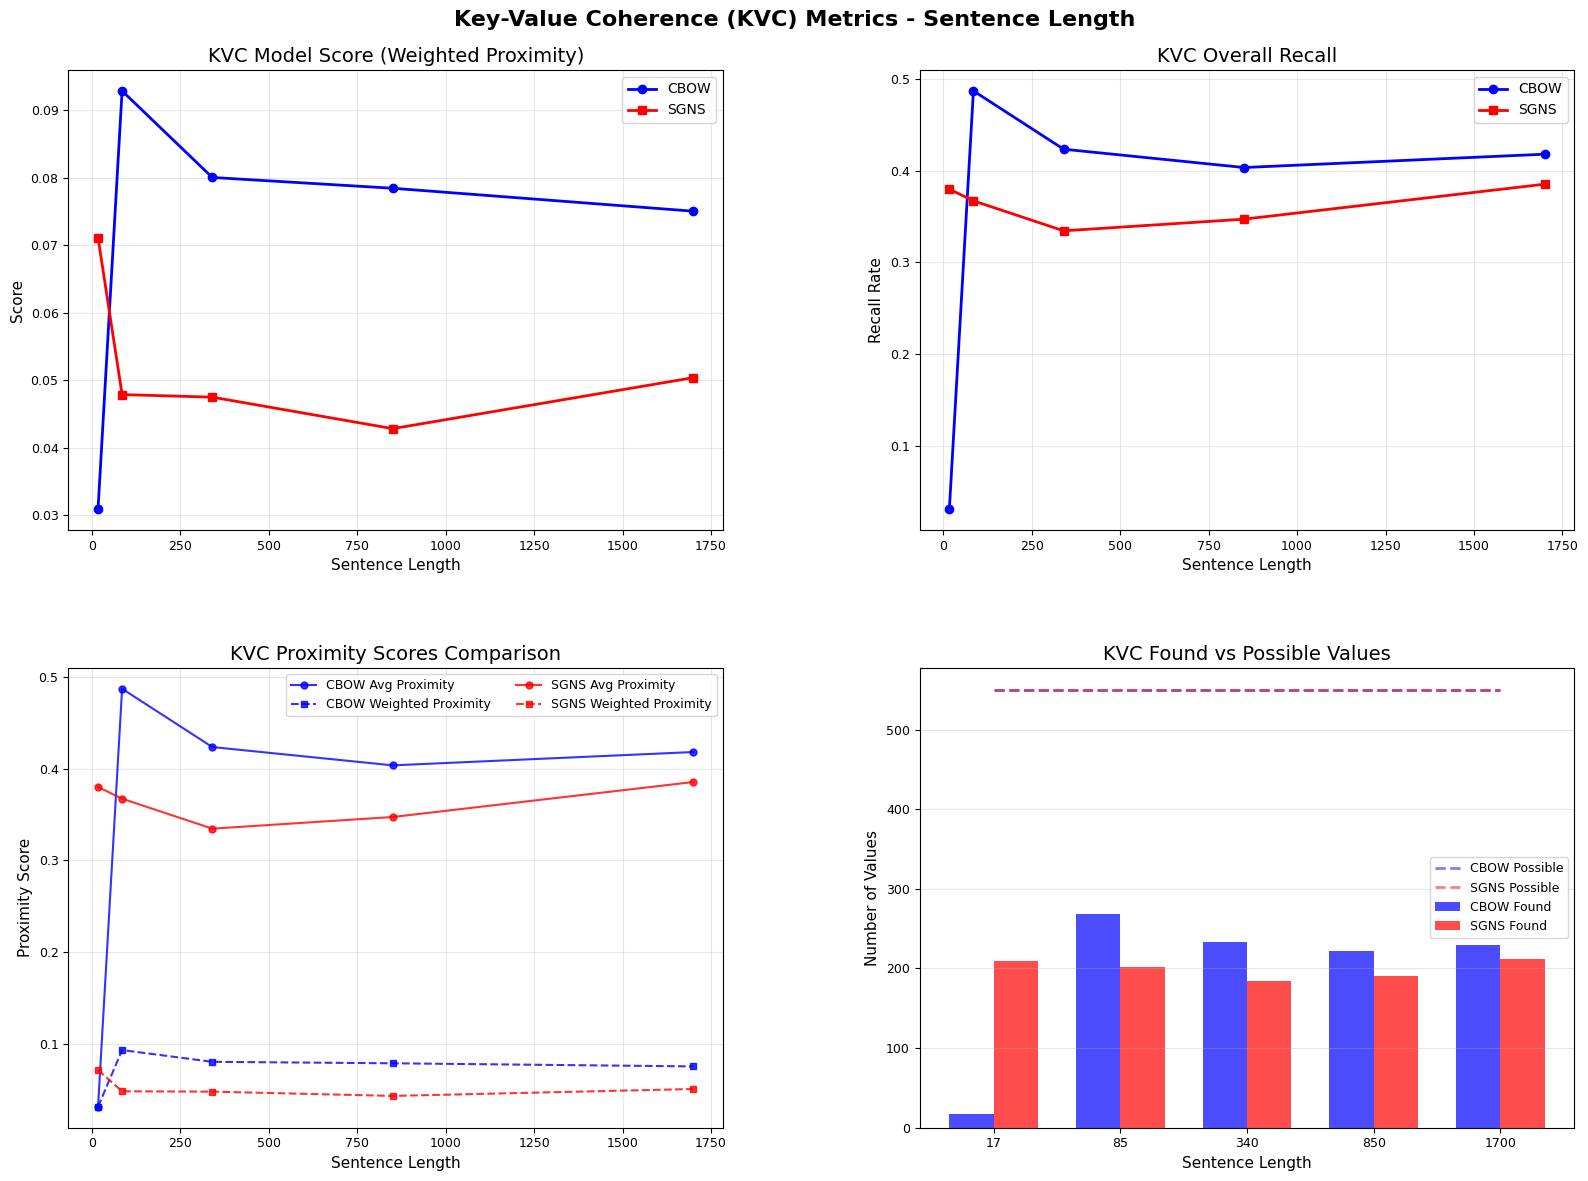


KVC METRICS SUMMARY FOR CATEGORY: SENTENCE

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Sentence Length CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
17              0.0309     0.0309     0.0309     0.0309     0.0711     0.38       0.0711     0.38      
85              0.0929     0.4873     0.0929     0.4873     0.0479     0.3673     0.0479     0.3673    
340             0.08       0.4236     0.08       0.4236     0.0475     0.3345     0.0475     0.3345    
850             0.0784     0.4036     0.0784     0.4036     0.0428     0.3473     0.0428     0.3473    
1700            0.075      0.4182     0.075      0.4182     0.0504    

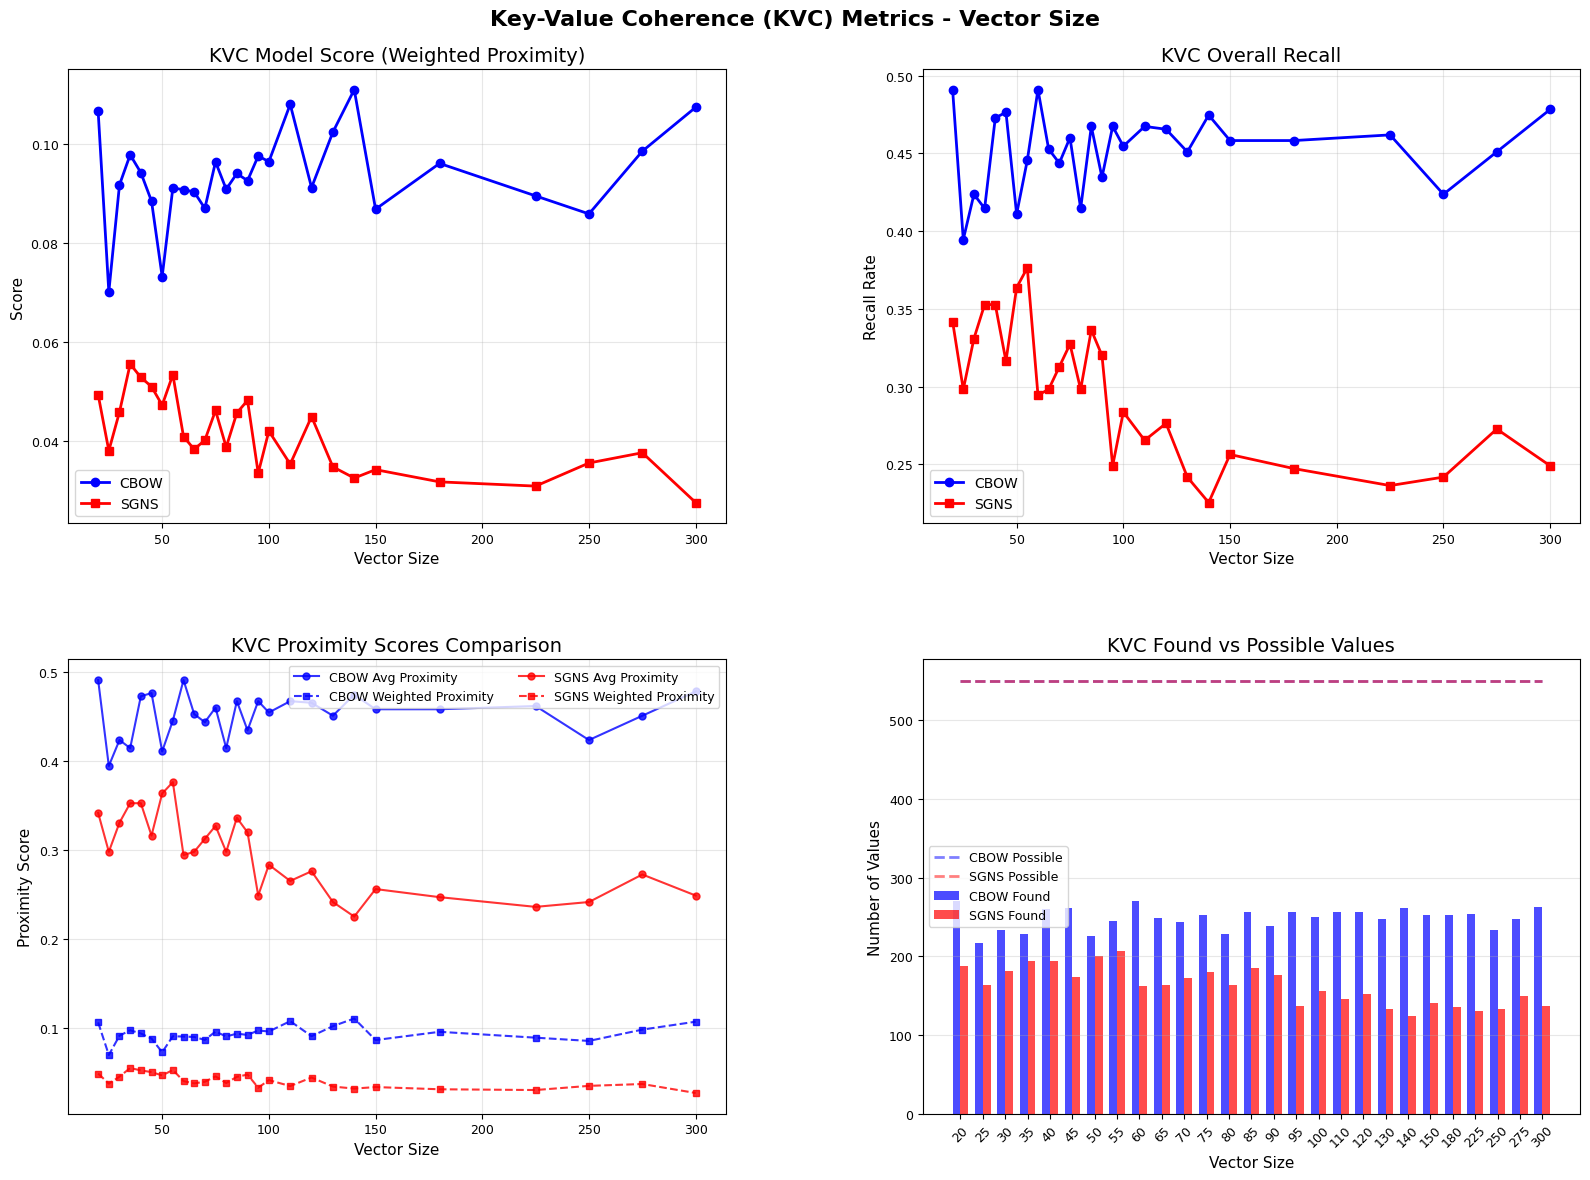


KVC METRICS SUMMARY FOR CATEGORY: VECTOR

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Vector Size     CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
20              0.1067     0.4909     0.1067     0.4909     0.0493     0.3418     0.0493     0.3418    
25              0.0701     0.3945     0.0701     0.3945     0.038      0.2982     0.038      0.2982    
30              0.0918     0.4236     0.0918     0.4236     0.0458     0.3309     0.0458     0.3309    
35              0.0979     0.4145     0.0979     0.4145     0.0555     0.3527     0.0555     0.3527    
40              0.0943     0.4727     0.0943     0.4727     0.0528     0

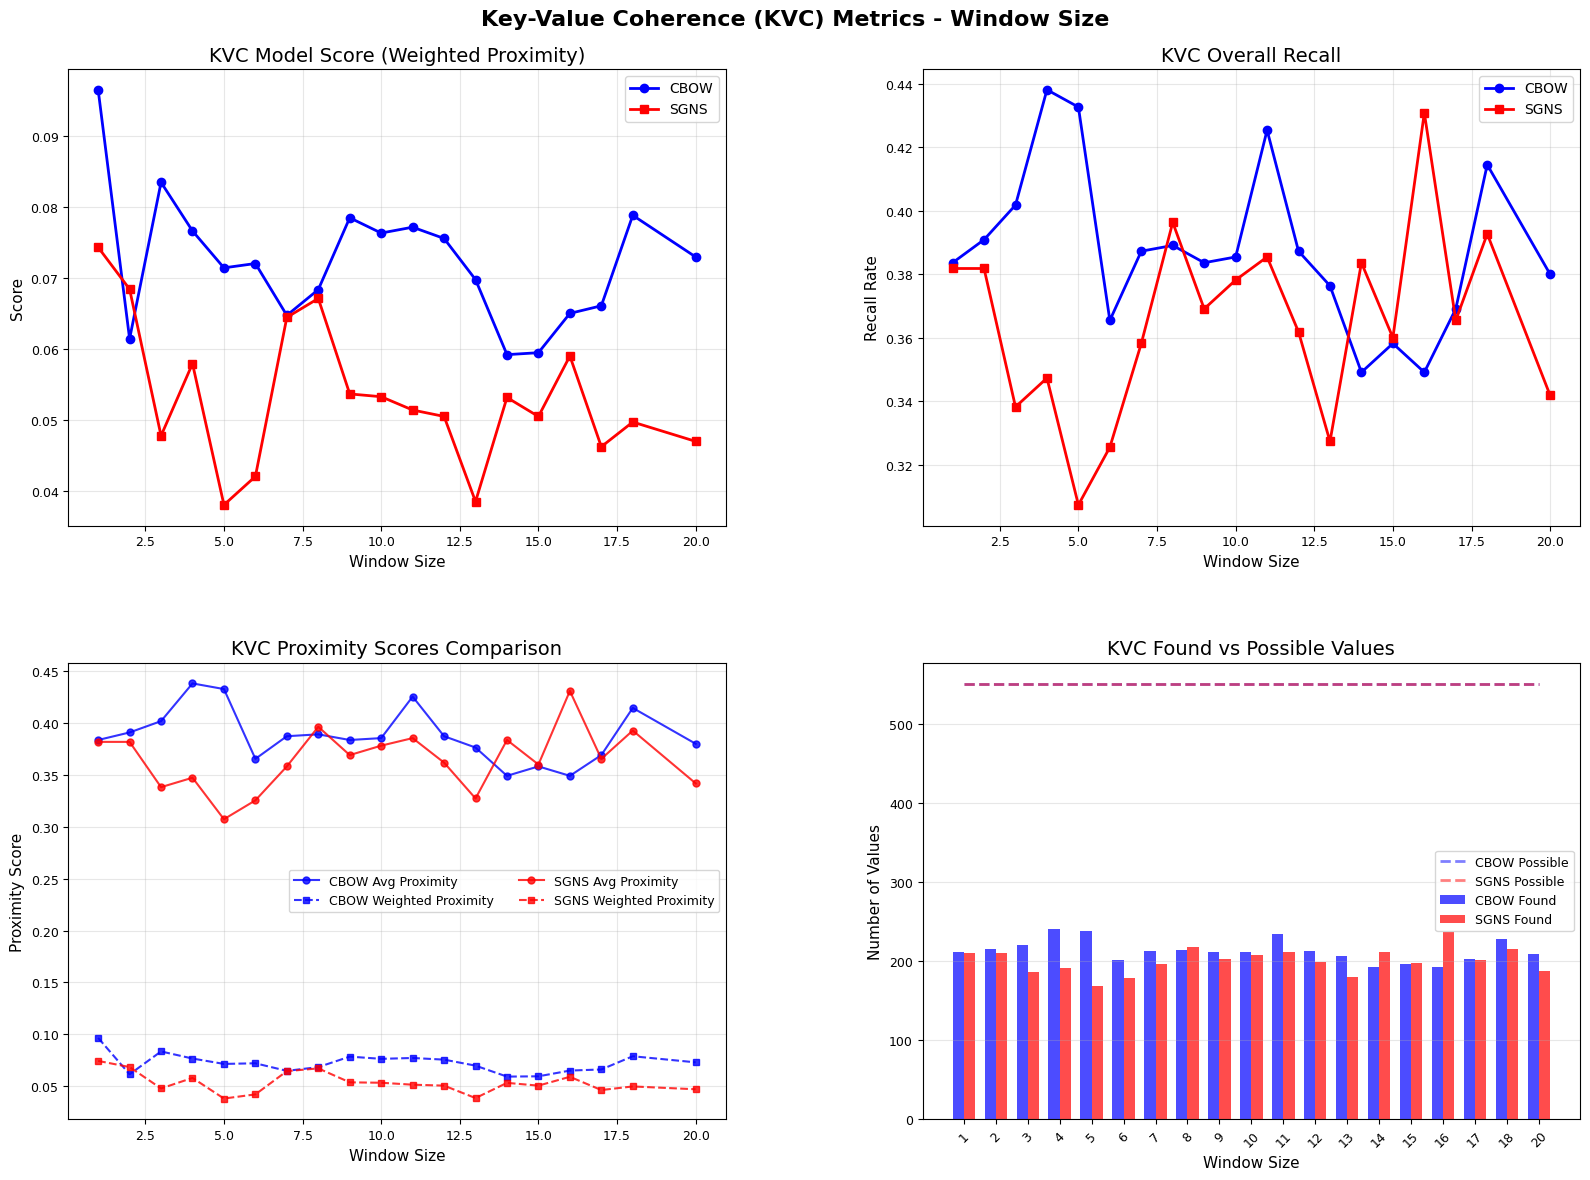


KVC METRICS SUMMARY FOR CATEGORY: WINDOWSIZE

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Window Size     CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
1               0.0965     0.3836     0.0965     0.3836     0.0743     0.3818     0.0743     0.3818    
2               0.0614     0.3909     0.0614     0.3909     0.0684     0.3818     0.0684     0.3818    
3               0.0834     0.4018     0.0834     0.4018     0.0477     0.3382     0.0477     0.3382    
4               0.0766     0.4382     0.0766     0.4382     0.0579     0.3473     0.0579     0.3473    
5               0.0714     0.4327     0.0714     0.4327     0.038   

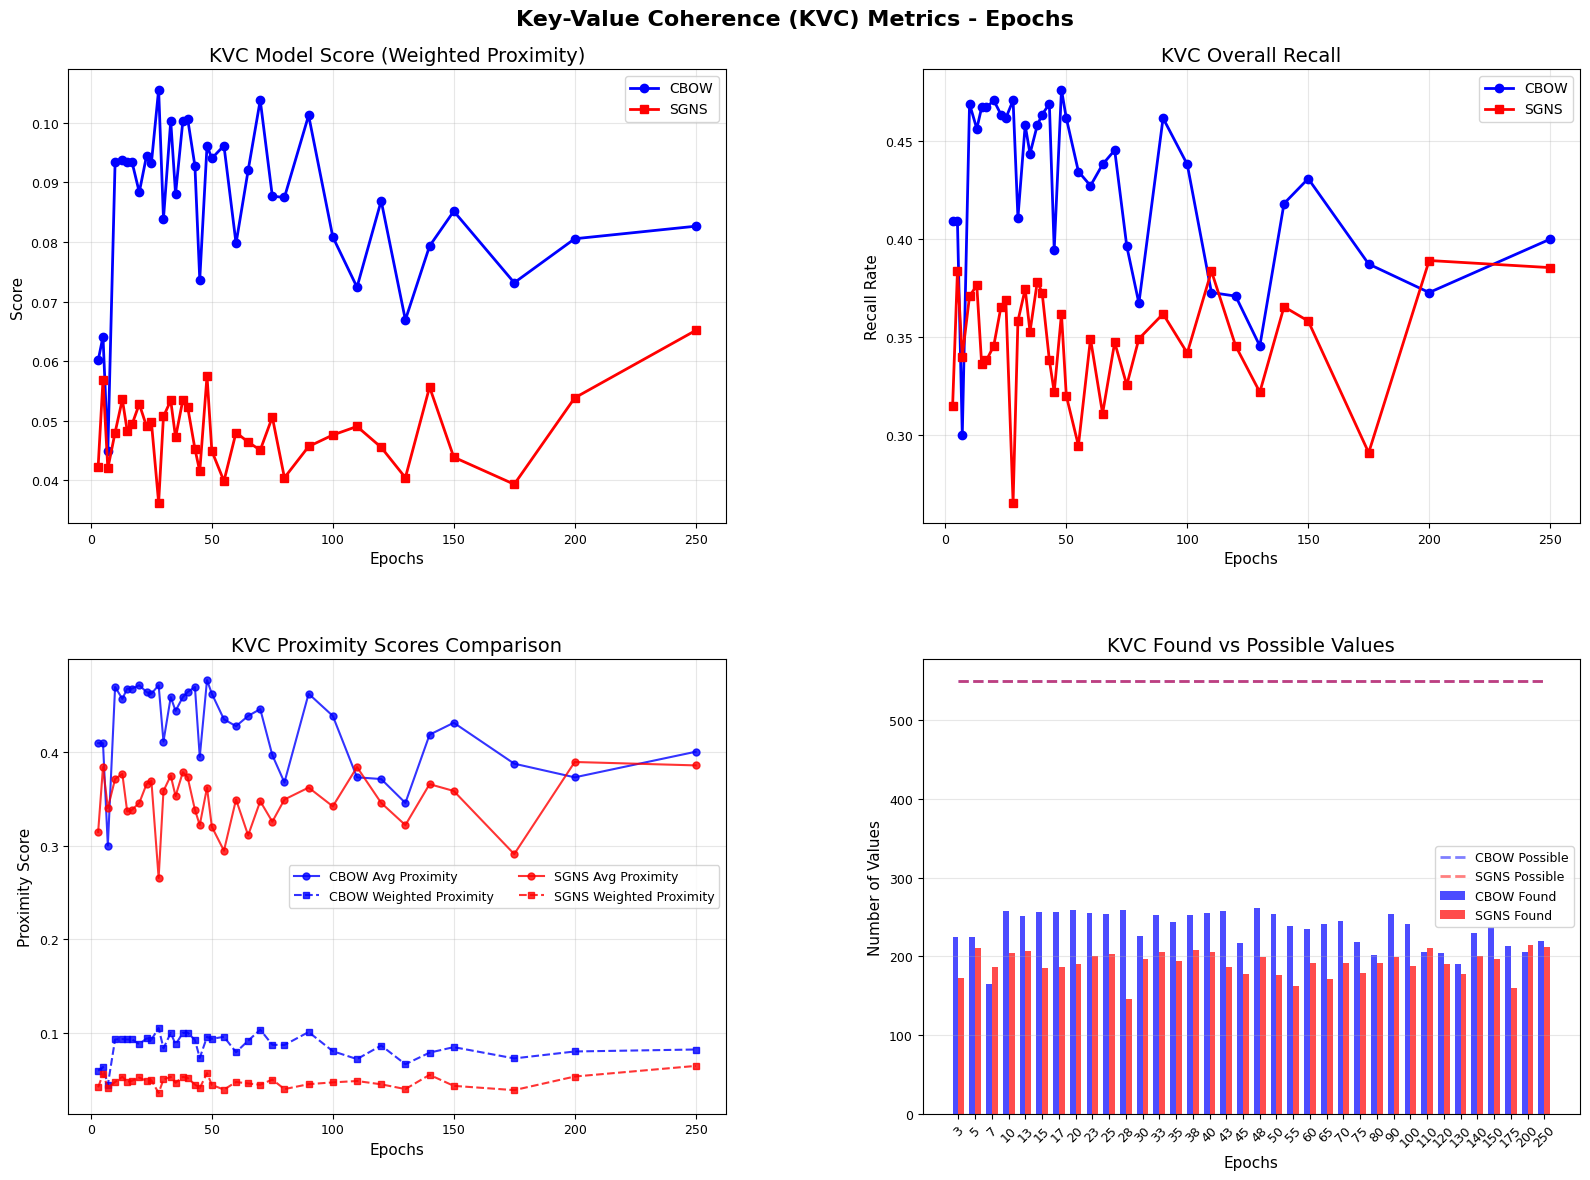


KVC METRICS SUMMARY FOR CATEGORY: EPOCH

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Epochs          CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
3               0.0601     0.4091     0.0601     0.4091     0.0423     0.3145     0.0423     0.3145    
5               0.0641     0.4091     0.0641     0.4091     0.0569     0.3836     0.0569     0.3836    
7               0.0449     0.3        0.0449     0.3        0.042      0.34       0.042      0.34      
10              0.0934     0.4691     0.0934     0.4691     0.048      0.3709     0.048      0.3709    
13              0.0937     0.4564     0.0937     0.4564     0.0536     0.

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Daten nach Kategorien und Algorithmen strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        # Erweiterte Datenstruktur für alle Metriken inklusive KVC
        data_by_category[category] = {
            'CBOW': {
                # Hauptmetriken
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {},
                # KVC Metriken
                'kvc_model_score': {}, 'kvc_avg_proximity': {}, 'kvc_weighted_proximity': {},
                'kvc_recall': {}, 'kvc_found_values': {}, 'kvc_possible_values': {},
                'kvc_keys_evaluated': {}
            },
            'SGNS': {
                # Hauptmetriken
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {},
                # KVC Metriken
                'kvc_model_score': {}, 'kvc_avg_proximity': {}, 'kvc_weighted_proximity': {},
                'kvc_recall': {}, 'kvc_found_values': {}, 'kvc_possible_values': {},
                'kvc_keys_evaluated': {}
            }
        }
    
    # Determine which parameter is relevant for this category
    if category == 'sentence':
        x_value = result['params']['Satzlänge']
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_value = result['params']['Vector Size']
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_value = result['params']['Window']
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_value = result['params']['Epochs']
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_value = result['params']['Negative Sampling']
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_value = result['params']['Sample']
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_value = result['params']['Hierarchical Softmax']
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_value = result['params']['Alpha']
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_value = None
        x_label = 'UNKNOWN - PLEASE SET'
        title_category = category
        print(f"Unknown category: {category}")
    
    # Extract all metrics if they exist
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    # Extract other main metrics
    rs_mean_value = float(result['rs_mean']) if 'rs_mean' in result else None
    rs_5_value = float(result['rs_5']) if 'rs_5' in result else None
    rs_10_value = float(result['rs_10']) if 'rs_10' in result else None
    rs_20_value = float(result['rs_20']) if 'rs_20' in result else None
    fc_value = float(result['fc']) if 'fc' in result else None
    ssmq_value = float(result['ssmq']) if 'ssmq' in result else None
    
    # Extract KVC metrics if they exist
    kvc_model_score = None
    kvc_avg_proximity = None
    kvc_weighted_proximity = None
    kvc_recall = None
    kvc_found_values = None
    kvc_possible_values = None
    kvc_keys_evaluated = None
    
    if 'kvc' in result:
        kvc_data = result['kvc']
        kvc_model_score = float(kvc_data.get('model_score', 0))
        kvc_avg_proximity = float(kvc_data.get('avg_proximity_score', 0))
        kvc_weighted_proximity = float(kvc_data.get('avg_weighted_proximity_score', 0))
        
        # Calculate recall if not directly available
        if 'overall_recall' in kvc_data:
            kvc_recall = float(kvc_data['overall_recall'])
        elif 'total_found_values' in kvc_data and 'total_possible_values' in kvc_data:
            total_found = kvc_data['total_found_values']
            total_possible = kvc_data['total_possible_values']
            kvc_recall = total_found / total_possible if total_possible > 0 else 0
        
        kvc_found_values = kvc_data.get('total_found_values', 0)
        kvc_possible_values = kvc_data.get('total_possible_values', 0)
        kvc_keys_evaluated = kvc_data.get('keys_evaluated', 0)
    
    if x_value is not None:
        # Store all available metrics
        main_metrics = [
            ('nd', nd_value),
            ('rs_mean', rs_mean_value),
            ('rs_5', rs_5_value),
            ('rs_10', rs_10_value),
            ('rs_20', rs_20_value),
            ('fc', fc_value),
            ('ssmq', ssmq_value)
        ]
        
        kvc_metrics = [
            ('kvc_model_score', kvc_model_score),
            ('kvc_avg_proximity', kvc_avg_proximity),
            ('kvc_weighted_proximity', kvc_weighted_proximity),
            ('kvc_recall', kvc_recall),
            ('kvc_found_values', kvc_found_values),
            ('kvc_possible_values', kvc_possible_values),
            ('kvc_keys_evaluated', kvc_keys_evaluated)
        ]
        
        # Store main metrics
        for metric_name, metric_value in main_metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value
        
        # Store KVC metrics
        for metric_name, metric_value in kvc_metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value

# OPTION 1: Separate KVC Plots (empfohlen für Detailanalyse)
print("=== SEPARATE KVC METRICS VISUALIZATION ===")
for category, category_data in data_by_category.items():
    # Get the correct labels for this category
    if category == 'sentence':
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_label = 'X-Axis'
        title_category = category
    
    # Create figure for KVC metrics (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Key-Value Coherence (KVC) Metrics - {title_category}', fontsize=16, fontweight='bold')
    
    axs = axes.flatten()
    
    # 1. KVC Model Score (Top Left)
    ax1 = axs[0]
    cbow_model_score = category_data['CBOW']['kvc_model_score']
    sgns_model_score = category_data['SGNS']['kvc_model_score']
    
    if cbow_model_score or sgns_model_score:
        if cbow_model_score:
            x_cbow = sorted(cbow_model_score.keys())
            y_cbow = [cbow_model_score[x] for x in x_cbow]
            ax1.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        
        if sgns_model_score:
            x_sgns = sorted(sgns_model_score.keys())
            y_sgns = [sgns_model_score[x] for x in x_sgns]
            ax1.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        
        ax1.set_title('KVC Model Score (Weighted Proximity)', fontsize=14)
        ax1.set_xlabel(x_label, fontsize=11)
        ax1.set_ylabel('Score', fontsize=11)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
    else:
        ax1.text(0.5, 0.5, 'No KVC Model Score data', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax1.transAxes, fontsize=12)
        ax1.set_title('KVC Model Score', fontsize=14)
    
    # 2. KVC Recall (Top Right)
    ax2 = axs[1]
    cbow_recall = category_data['CBOW']['kvc_recall']
    sgns_recall = category_data['SGNS']['kvc_recall']
    
    if cbow_recall or sgns_recall:
        if cbow_recall:
            x_cbow = sorted(cbow_recall.keys())
            y_cbow = [cbow_recall[x] for x in x_cbow]
            ax2.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        
        if sgns_recall:
            x_sgns = sorted(sgns_recall.keys())
            y_sgns = [sgns_recall[x] for x in x_sgns]
            ax2.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        
        ax2.set_title('KVC Overall Recall', fontsize=14)
        ax2.set_xlabel(x_label, fontsize=11)
        ax2.set_ylabel('Recall Rate', fontsize=11)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No KVC Recall data', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax2.transAxes, fontsize=12)
        ax2.set_title('KVC Recall', fontsize=14)
    
    # 3. KVC Proximity Scores Comparison (Bottom Left)
    ax3 = axs[2]
    
    # Define KVC metrics to plot
    kvc_proximity_metrics = [
        ('kvc_avg_proximity', 'Avg Proximity', '-', 'o'),
        ('kvc_weighted_proximity', 'Weighted Proximity', '--', 's')
    ]
    
    # Plot CBOW KVC proximity metrics
    for kvc_key, kvc_label, linestyle, marker in kvc_proximity_metrics:
        cbow_data = category_data['CBOW'][kvc_key]
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            ax3.plot(x_cbow, y_cbow, f'b{marker}{linestyle}', linewidth=1.5, markersize=5, 
                    label=f'CBOW {kvc_label}', alpha=0.8)
    
    # Plot SGNS KVC proximity metrics
    for kvc_key, kvc_label, linestyle, marker in kvc_proximity_metrics:
        sgns_data = category_data['SGNS'][kvc_key]
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            ax3.plot(x_sgns, y_sgns, f'r{marker}{linestyle}', linewidth=1.5, markersize=5, 
                    label=f'SGNS {kvc_label}', alpha=0.8)
    
    ax3.set_title('KVC Proximity Scores Comparison', fontsize=14)
    ax3.set_xlabel(x_label, fontsize=11)
    ax3.set_ylabel('Proximity Score', fontsize=11)
    ax3.legend(fontsize=9, ncol=2)
    ax3.grid(True, alpha=0.3)
    
    # 4. KVC Found vs Possible Values (Bottom Right)
    ax4 = axs[3]
    
    # Prepare data for bar chart
    x_values = sorted(set(list(category_data['CBOW']['kvc_found_values'].keys()) + 
                          list(category_data['SGNS']['kvc_found_values'].keys())))
    
    if x_values:
        # Get data for bar chart
        cbow_found = [category_data['CBOW']['kvc_found_values'].get(x, 0) for x in x_values]
        sgns_found = [category_data['SGNS']['kvc_found_values'].get(x, 0) for x in x_values]
        cbow_possible = [category_data['CBOW']['kvc_possible_values'].get(x, 0) for x in x_values]
        sgns_possible = [category_data['SGNS']['kvc_possible_values'].get(x, 0) for x in x_values]
        
        x_pos = np.arange(len(x_values))
        width = 0.35
        
        # Create grouped bar chart
        bars1 = ax4.bar(x_pos - width/2, cbow_found, width, label='CBOW Found', color='blue', alpha=0.7)
        bars2 = ax4.bar(x_pos + width/2, sgns_found, width, label='SGNS Found', color='red', alpha=0.7)
        
        # Add possible values as line
        ax4.plot(x_pos, cbow_possible, 'b--', linewidth=2, label='CBOW Possible', alpha=0.5)
        ax4.plot(x_pos, sgns_possible, 'r--', linewidth=2, label='SGNS Possible', alpha=0.5)
        
        ax4.set_title('KVC Found vs Possible Values', fontsize=14)
        ax4.set_xlabel(x_label, fontsize=11)
        ax4.set_ylabel('Number of Values', fontsize=11)
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(x_values, rotation=45 if len(x_values) > 5 else 0)
        ax4.legend(fontsize=9)
        ax4.grid(True, alpha=0.3, axis='y')
    else:
        ax4.text(0.5, 0.5, 'No KVC Values data', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax4.transAxes, fontsize=12)
        ax4.set_title('KVC Found vs Possible Values', fontsize=14)
    
    # Better readability for all subplots
    for ax in axs:
        ax.tick_params(axis='x', labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.3)
    plt.show()
    
    # Tabular overview for KVC metrics
    print(f"\n{'='*100}")
    print(f"KVC METRICS SUMMARY FOR CATEGORY: {category.upper()}")
    print(f"{'='*100}")
    
    # Find common x-values
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['kvc_model_score', 'kvc_avg_proximity', 'kvc_weighted_proximity', 
                      'kvc_recall', 'kvc_found_values', 'kvc_possible_values']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if sorted_x:
        print(f"\nKVC PERFORMANCE METRICS:")
        print("-" * 120)
        print(f"{x_label:<15} {'CBOW KVC:':<40} {'SGNS KVC:':<40}")
        print(f"{'':<15} {'Model':<10} {'Avg Prox':<10} {'Wtd Prox':<10} {'Recall':<10} "
              f"{'Model':<10} {'Avg Prox':<10} {'Wtd Prox':<10} {'Recall':<10}")
        print("-" * 120)
        
        for x in sorted_x:
            # CBOW KVC values
            cbow_model = category_data['CBOW']['kvc_model_score'].get(x, "N/A")
            cbow_avg = category_data['CBOW']['kvc_avg_proximity'].get(x, "N/A")
            cbow_wtd = category_data['CBOW']['kvc_weighted_proximity'].get(x, "N/A")
            cbow_recall = category_data['CBOW']['kvc_recall'].get(x, "N/A")
            
            # SGNS KVC values
            sgns_model = category_data['SGNS']['kvc_model_score'].get(x, "N/A")
            sgns_avg = category_data['SGNS']['kvc_avg_proximity'].get(x, "N/A")
            sgns_wtd = category_data['SGNS']['kvc_weighted_proximity'].get(x, "N/A")
            sgns_recall = category_data['SGNS']['kvc_recall'].get(x, "N/A")
            
            print(f"{x:<15} "
                  f"{str(round(cbow_model, 4) if isinstance(cbow_model, (int, float)) else cbow_model):<10} "
                  f"{str(round(cbow_avg, 4) if isinstance(cbow_avg, (int, float)) else cbow_avg):<10} "
                  f"{str(round(cbow_wtd, 4) if isinstance(cbow_wtd, (int, float)) else cbow_wtd):<10} "
                  f"{str(round(cbow_recall, 4) if isinstance(cbow_recall, (int, float)) else cbow_recall):<10} "
                  f"{str(round(sgns_model, 4) if isinstance(sgns_model, (int, float)) else sgns_model):<10} "
                  f"{str(round(sgns_avg, 4) if isinstance(sgns_avg, (int, float)) else sgns_avg):<10} "
                  f"{str(round(sgns_wtd, 4) if isinstance(sgns_wtd, (int, float)) else sgns_wtd):<10} "
                  f"{str(round(sgns_recall, 4) if isinstance(sgns_recall, (int, float)) else sgns_recall):<10}")
        
        print(f"\nKVC VALUE COUNTS:")
        print("-" * 80)
        print(f"{x_label:<15} {'CBOW:':<25} {'SGNS:':<25}")
        print(f"{'':<15} {'Found':<10} {'Possible':<10} {'Keys':<10} "
              f"{'Found':<10} {'Possible':<10} {'Keys':<10}")
        print("-" * 80)
        
        for x in sorted_x:
            # CBOW value counts
            cbow_found = category_data['CBOW']['kvc_found_values'].get(x, "N/A")
            cbow_possible = category_data['CBOW']['kvc_possible_values'].get(x, "N/A")
            cbow_keys = category_data['CBOW']['kvc_keys_evaluated'].get(x, "N/A")
            
            # SGNS value counts
            sgns_found = category_data['SGNS']['kvc_found_values'].get(x, "N/A")
            sgns_possible = category_data['SGNS']['kvc_possible_values'].get(x, "N/A")
            sgns_keys = category_data['SGNS']['kvc_keys_evaluated'].get(x, "N/A")
            
            print(f"{x:<15} "
                  f"{str(cbow_found) if isinstance(cbow_found, (int, float)) else cbow_found:<10} "
                  f"{str(cbow_possible) if isinstance(cbow_possible, (int, float)) else cbow_possible:<10} "
                  f"{str(cbow_keys) if isinstance(cbow_keys, (int, float)) else cbow_keys:<10} "
                  f"{str(sgns_found) if isinstance(sgns_found, (int, float)) else sgns_found:<10} "
                  f"{str(sgns_possible) if isinstance(sgns_possible, (int, float)) else sgns_possible:<10} "
                  f"{str(sgns_keys) if isinstance(sgns_keys, (int, float)) else sgns_keys:<10}")
    
    print(f"\n{'-'*100}\n")


<h2>Nice Plots<h2>


WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



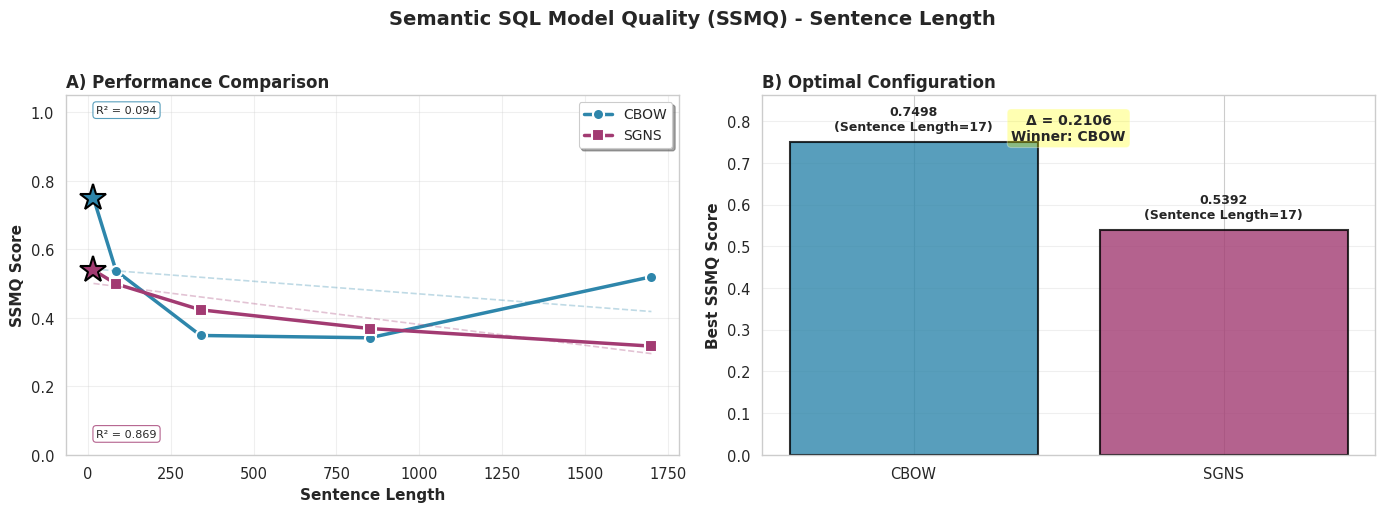


SSMQ SUMMARY - SENTENCE LENGTH
CBOW Best: 0.7498 at Sentence Length=17
SGNS Best: 0.5392 at Sentence Length=17



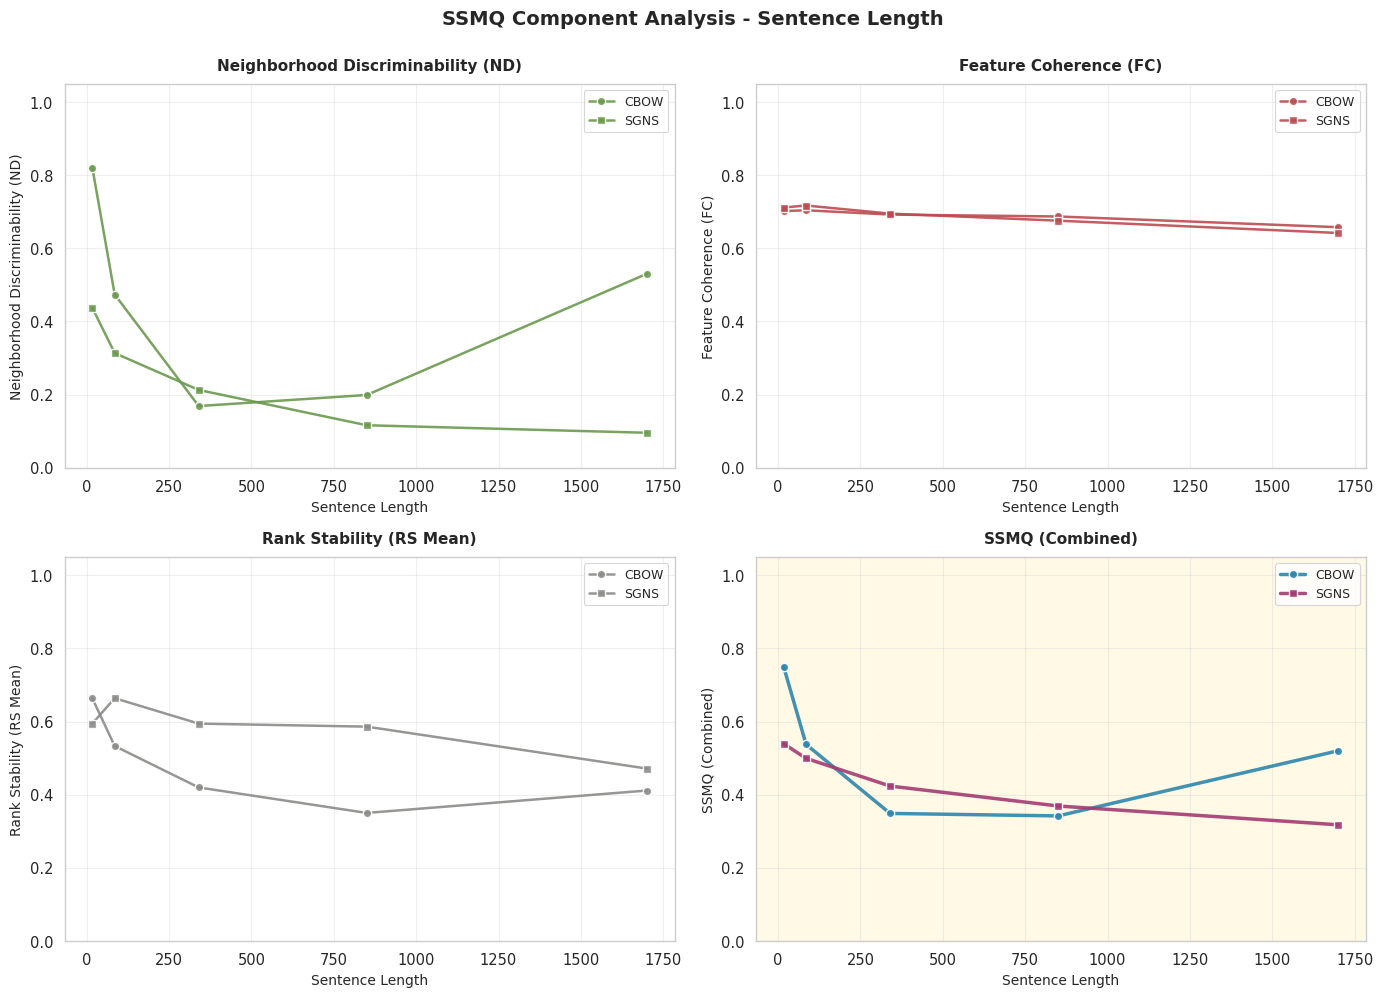


NUMERICAL RESULTS TABLE - SENTENCE

Sentence Length | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
17           | 0.8208    0.7017    0.6635    0.7498    | 0.4372    0.7115    0.5944    0.5392   
85           | 0.4735    0.7040    0.5329    0.5374    | 0.3134    0.7170    0.6637    0.4992   
340          | 0.1686    0.6922    0.4196    0.3486    | 0.2126    0.6948    0.5942    0.4235   
850          | 0.1989    0.6870    0.3500    0.3418    | 0.1161    0.6755    0.5860    0.3689   
1700         | 0.5302    0.6577    0.4113    0.5200    | 0.0955    0.6419    0.4713    0.3175   


####################################################################################################
# CATEGORY: VECTOR SIZE
###################################################

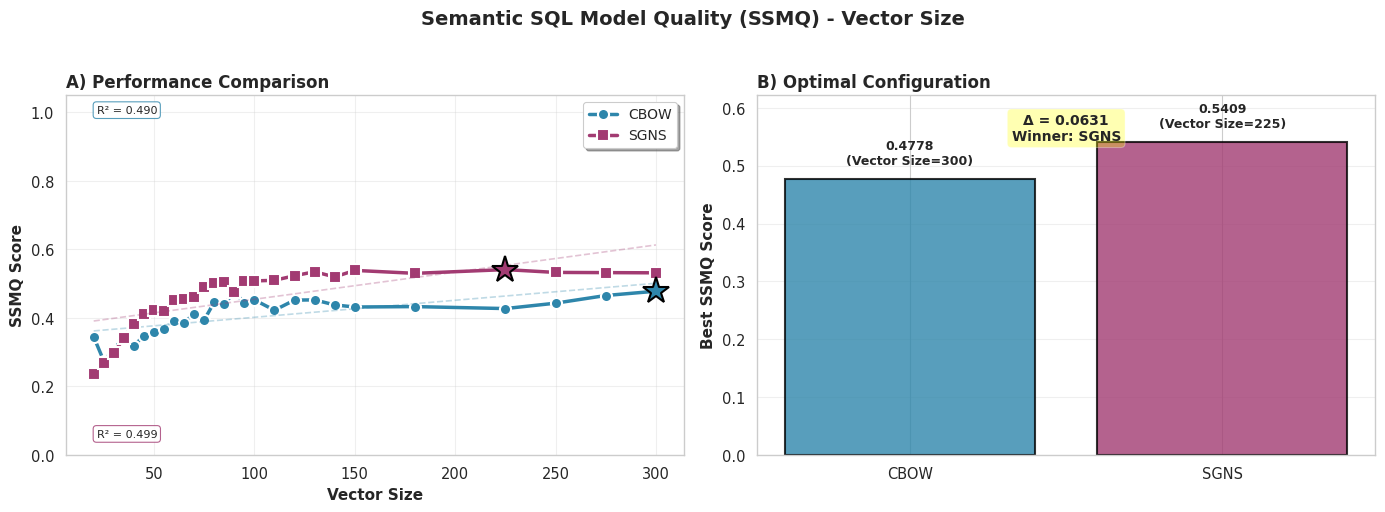


SSMQ SUMMARY - VECTOR SIZE
CBOW Best: 0.4778 at Vector Size=300
SGNS Best: 0.5409 at Vector Size=225



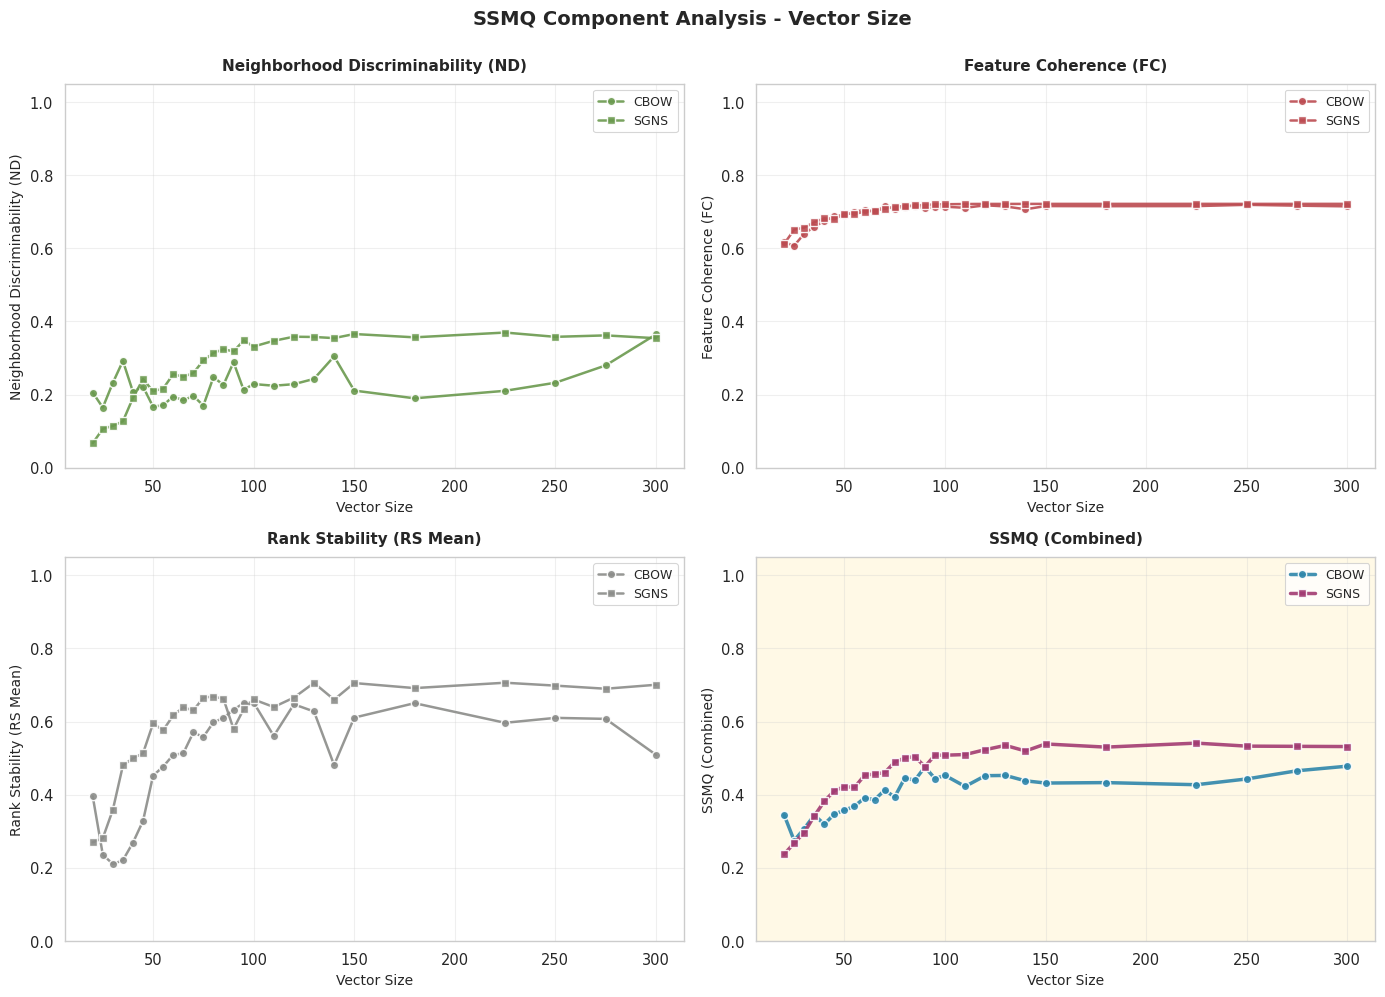


NUMERICAL RESULTS TABLE - VECTOR

Vector Size  | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
20           | 0.2056    0.6164    0.3952    0.3446    | 0.0671    0.6120    0.2696    0.2369   
25           | 0.1645    0.6072    0.2360    0.2745    | 0.1062    0.6509    0.2811    0.2676   
30           | 0.2322    0.6399    0.2102    0.3071    | 0.1143    0.6566    0.3586    0.2961   
35           | 0.2919    0.6590    0.2206    0.3439    | 0.1269    0.6711    0.4797    0.3416   
40           | 0.2073    0.6747    0.2689    0.3193    | 0.1910    0.6821    0.4996    0.3818   
45           | 0.2219    0.6876    0.3281    0.3469    | 0.2423    0.6792    0.5132    0.4110   
50           | 0.1666    0.6922    0.4521    0.3573    | 0.2091    0.6948    0.5946   

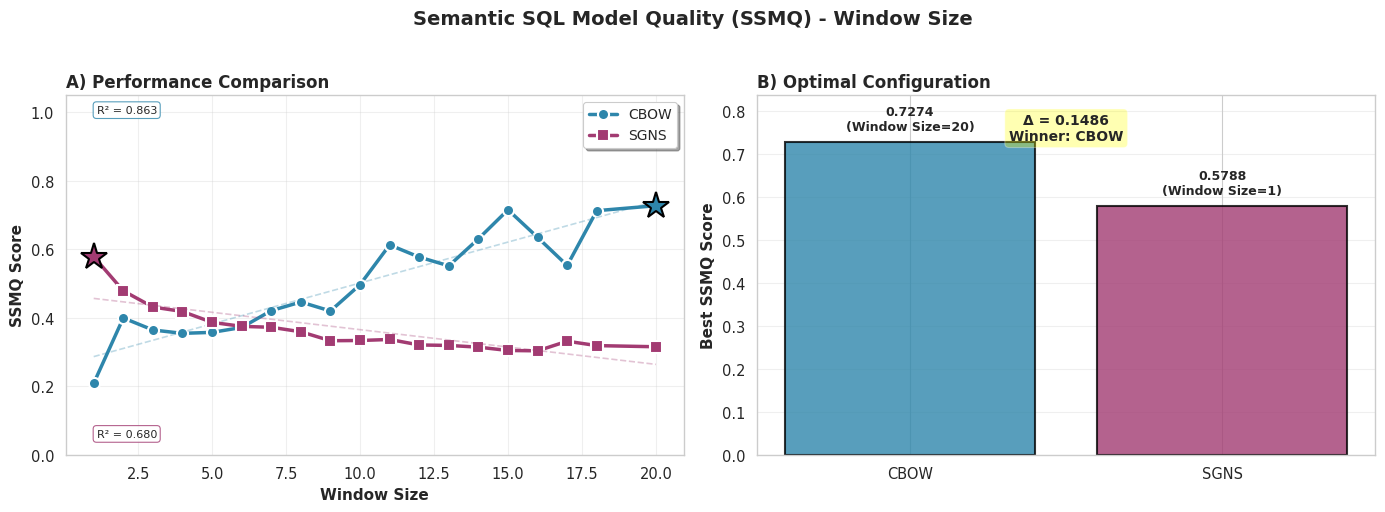


SSMQ SUMMARY - WINDOW SIZE
CBOW Best: 0.7274 at Window Size=20
SGNS Best: 0.5788 at Window Size=1



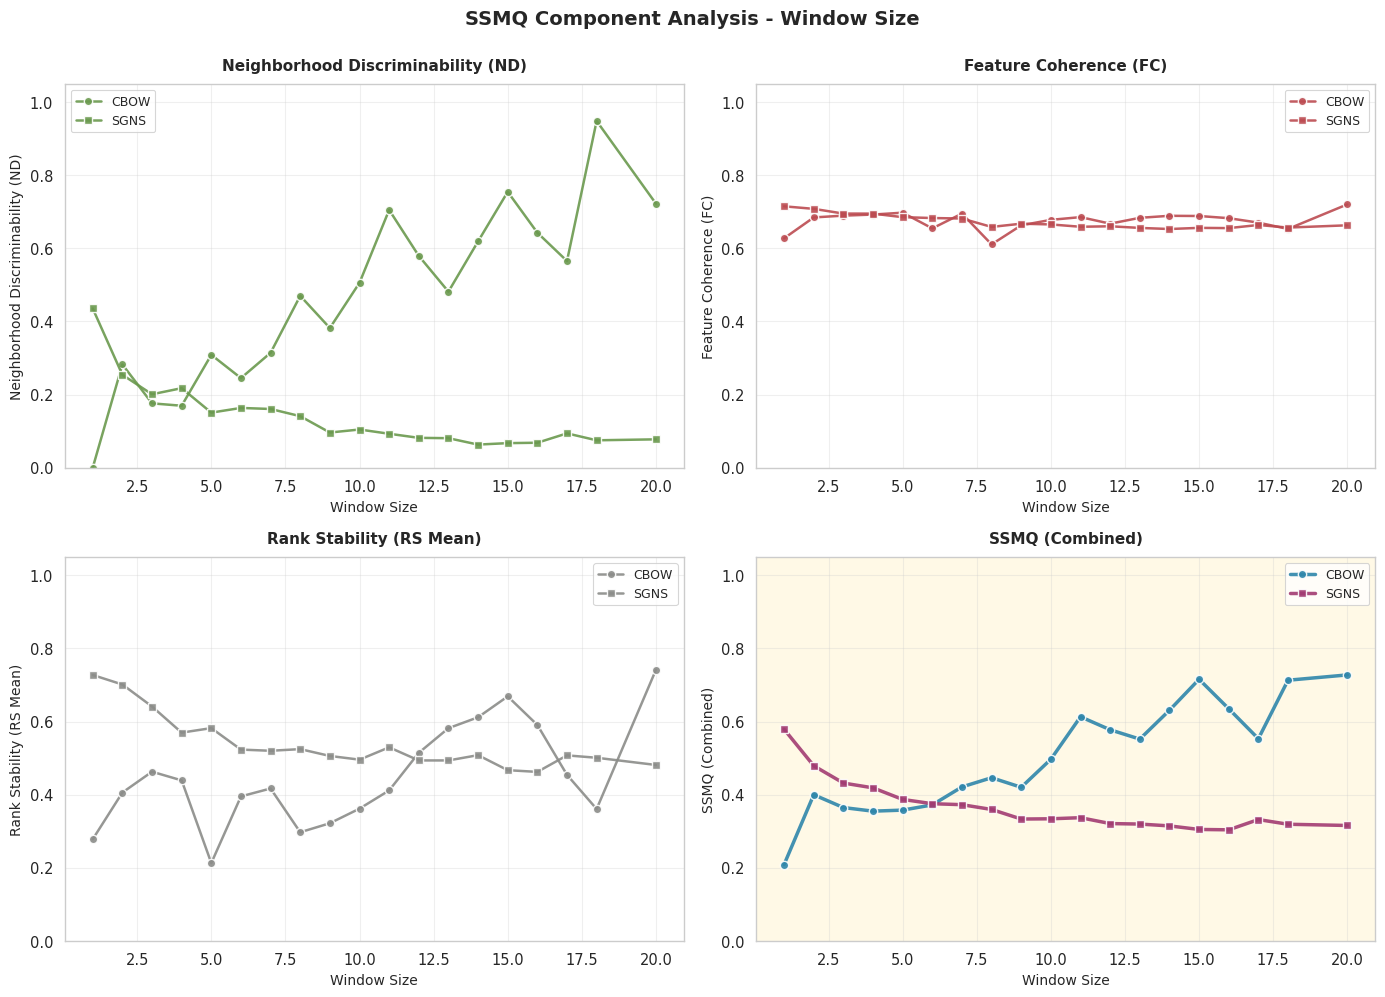


NUMERICAL RESULTS TABLE - WINDOWSIZE

Window Size  | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
1            | 0.0000    0.6273    0.2782    0.2089    | 0.4354    0.7148    0.7272    0.5788   
2            | 0.2823    0.6844    0.4057    0.3997    | 0.2539    0.7078    0.7012    0.4789   
3            | 0.1760    0.6893    0.4627    0.3647    | 0.2008    0.6949    0.6410    0.4317   
4            | 0.1694    0.6922    0.4390    0.3548    | 0.2175    0.6948    0.5696    0.4186   
5            | 0.3086    0.6974    0.2130    0.3577    | 0.1506    0.6851    0.5819    0.3869   
6            | 0.2450    0.6544    0.3952    0.3720    | 0.1634    0.6827    0.5232    0.3752   
7            | 0.3142    0.6949    0.4168    0.4211    | 0.1606    0.6814    0.520

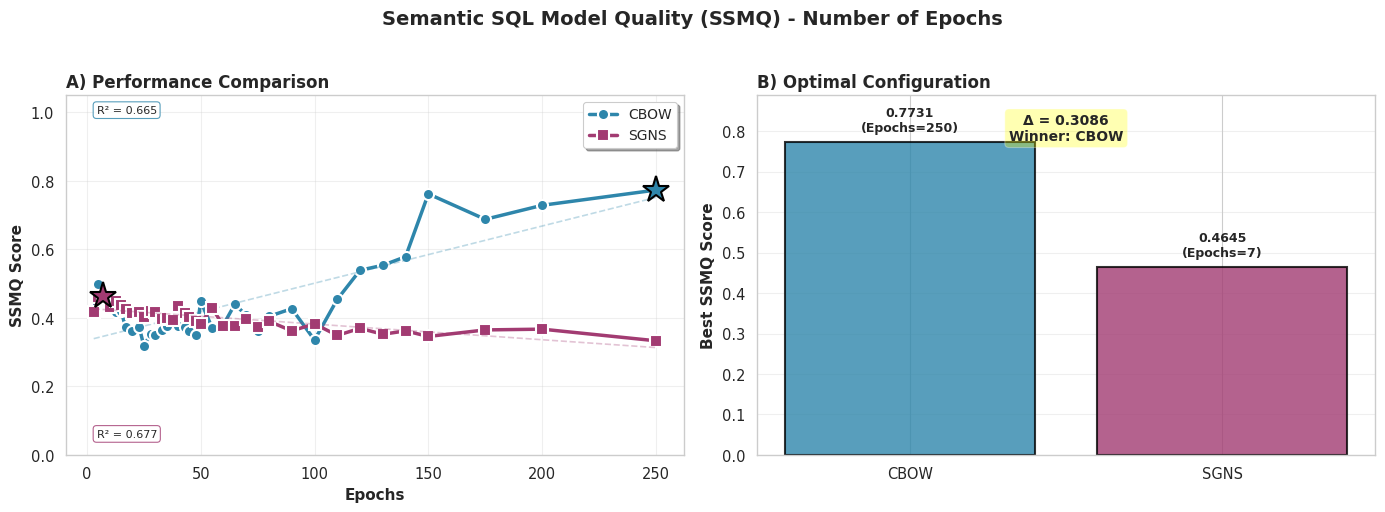


SSMQ SUMMARY - NUMBER OF EPOCHS
CBOW Best: 0.7731 at Epochs=250
SGNS Best: 0.4645 at Epochs=7



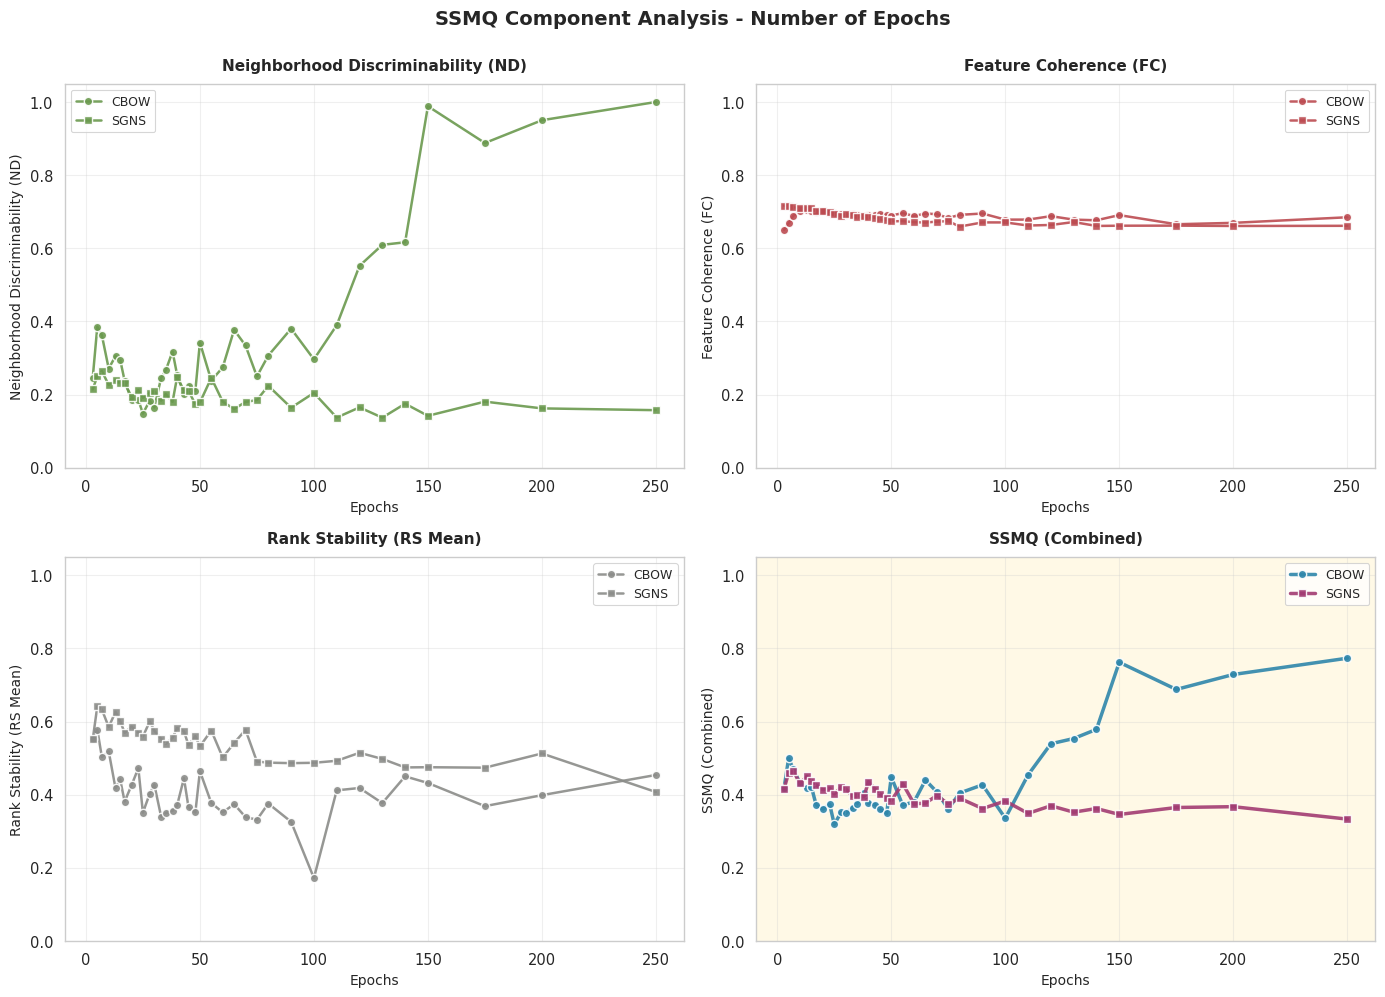


NUMERICAL RESULTS TABLE - EPOCH

Epochs       | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
3            | 0.2463    0.6505    0.5512    0.4186    | 0.2141    0.7165    0.5512    0.4157   
5            | 0.3854    0.6686    0.5779    0.4998    | 0.2503    0.7148    0.6412    0.4605   
7            | 0.3622    0.6886    0.5029    0.4697    | 0.2644    0.7118    0.6330    0.4645   
10           | 0.2710    0.7022    0.5184    0.4315    | 0.2262    0.7114    0.5849    0.4308   
13           | 0.3055    0.7034    0.4170    0.4185    | 0.2393    0.7114    0.6266    0.4499   
15           | 0.2957    0.7016    0.4420    0.4208    | 0.2323    0.7096    0.6013    0.4385   
17           | 0.2376    0.6994    0.3811    0.3730    | 0.2307    0.7030    0.5692    

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress
from scipy import interpolate

# Wissenschaftliches Farbschema
COLORS = {
    'CBOW': '#2E86AB',      # Professionelles Blau
    'SGNS': '#A23B72',      # Kontrastierendes Magenta
    'SSMQ': '#F18F01',      # Orange für Wichtigkeit
    'ND': '#6A994E',        # Grün
    'FC': '#BC4B51',        # Rot
    'RS': '#8B8C89'         # Grau
}

# Linienstärken nach Wichtigkeit
LINEWIDTHS = {
    'primary': 2.5,         # SSMQ
    'secondary': 1.8,       # ND, FC, RS_mean
    'tertiary': 1.0         # Hintergrund-Komponenten
}

# Seaborn Style Setup
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Daten nach Kategorien strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        data_by_category[category] = {
            'CBOW': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            },
            'SGNS': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            }
        }
    
    # X-Wert und Label bestimmen
    category_mapping = {
        'sentence': ('Satzlänge', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window', 'Window Size'),
        'epoch': ('Epochs', 'Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling'),
        'sample': ('Sample', 'Sample'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Alpha')
    }
    
    if category in category_mapping:
        param_key, x_label = category_mapping[category]
        x_value = result['params'][param_key]
    else:
        x_value = None
        x_label = 'Parameter'
        print(f"Unknown category: {category}")
    
    # Metriken extrahieren
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    metrics_dict = {
        'nd': nd_value,
        'rs_mean': float(result['rs_mean']) if 'rs_mean' in result else None,
        'rs_5': float(result['rs_5']) if 'rs_5' in result else None,
        'rs_10': float(result['rs_10']) if 'rs_10' in result else None,
        'rs_20': float(result['rs_20']) if 'rs_20' in result else None,
        'fc': float(result['fc']) if 'fc' in result else None,
        'ssmq': float(result['ssmq']) if 'ssmq' in result else None
    }
    
    if x_value is not None:
        for metric_name, metric_value in metrics_dict.items():
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value


def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.2)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


def plot_ssmq_main_result(category, category_data, x_label, title_category):
    """
    FIGURE 1: SSMQ Hauptergebnis (Das wichtigste Ergebnis)
    Panel A: Line Plot mit Trends
    Panel B: Best Performance Bar Chart
    """
    cbow_ssmq_data = category_data['CBOW']['ssmq']
    sgns_ssmq_data = category_data['SGNS']['ssmq']
    
    if not cbow_ssmq_data and not sgns_ssmq_data:
        print(f"No SSMQ data for {category}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Semantic SQL Model Quality (SSMQ) - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Line Plot mit Trends
    if cbow_ssmq_data:
        x_cbow = sorted(cbow_ssmq_data.keys())
        y_cbow = [cbow_ssmq_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='CBOW', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_cbow, y_cbow, ax1, COLORS['CBOW'], 'top')
        
        # Markiere Maximum
        max_idx = np.argmax(y_cbow)
        ax1.plot(x_cbow[max_idx], y_cbow[max_idx], '*', 
                color=COLORS['CBOW'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    if sgns_ssmq_data:
        x_sgns = sorted(sgns_ssmq_data.keys())
        y_sgns = [sgns_ssmq_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='SGNS', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_sgns, y_sgns, ax1, COLORS['SGNS'], 'bottom')
        
        # Markiere Maximum
        max_idx = np.argmax(y_sgns)
        ax1.plot(x_sgns[max_idx], y_sgns[max_idx], '*', 
                color=COLORS['SGNS'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('SSMQ Score', fontsize=11, fontweight='bold')
    ax1.set_title('A) Performance Comparison', fontsize=12, loc='left', fontweight='bold')
    ax1.legend(fontsize=10, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Best Performance Comparison
    if cbow_ssmq_data and sgns_ssmq_data:
        max_cbow = max(cbow_ssmq_data.values())
        max_sgns = max(sgns_ssmq_data.values())
        max_cbow_param = max(cbow_ssmq_data, key=cbow_ssmq_data.get)
        max_sgns_param = max(sgns_ssmq_data, key=sgns_ssmq_data.get)
        
        algorithms = ['CBOW', 'SGNS']
        scores = [max_cbow, max_sgns]
        params = [max_cbow_param, max_sgns_param]
        colors_list = [COLORS['CBOW'], COLORS['SGNS']]
        
        bars = ax2.bar(algorithms, scores, color=colors_list, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
        
        # Werte auf Balken
        for bar, score, param in zip(bars, scores, params):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}\n({x_label}={param})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Best SSMQ Score', fontsize=11, fontweight='bold')
        ax2.set_title('B) Optimal Configuration', fontsize=12, loc='left', fontweight='bold')
        ax2.set_ylim([0, max(scores) * 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Differenz anzeigen
        diff = abs(max_cbow - max_sgns)
        winner = 'CBOW' if max_cbow > max_sgns else 'SGNS'
        ax2.text(0.5, 0.95, f'Δ = {diff:.4f}\nWinner: {winner}',
                transform=ax2.transAxes, ha='center', va='top',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    # Numerische Zusammenfassung
    print(f"\n{'='*80}")
    print(f"SSMQ SUMMARY - {title_category.upper()}")
    print(f"{'='*80}")
    if cbow_ssmq_data:
        print(f"CBOW Best: {max(cbow_ssmq_data.values()):.4f} at {x_label}={max(cbow_ssmq_data, key=cbow_ssmq_data.get)}")
    if sgns_ssmq_data:
        print(f"SGNS Best: {max(sgns_ssmq_data.values()):.4f} at {x_label}={max(sgns_ssmq_data, key=sgns_ssmq_data.get)}")
    print(f"{'='*80}\n")


def plot_component_analysis(category, category_data, x_label, title_category):
    """
    FIGURE 2: Komponenten-Analyse
    Zeigt wie sich SSMQ aus ND, FC und RS zusammensetzt
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'SSMQ Component Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    metrics_config = [
        ('nd', 'Neighborhood Discriminability (ND)', COLORS['ND'], axes[0, 0]),
        ('fc', 'Feature Coherence (FC)', COLORS['FC'], axes[0, 1]),
        ('rs_mean', 'Rank Stability (RS Mean)', COLORS['RS'], axes[1, 0]),
        ('ssmq', 'SSMQ (Combined)', COLORS['SSMQ'], axes[1, 1])
    ]
    
    for metric_key, metric_title, metric_color, ax in metrics_config:
        cbow_data = category_data['CBOW'][metric_key]
        sgns_data = category_data['SGNS'][metric_key]
        
        has_data = False
        
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            
            # CBOW immer in eigenem Farbton, aber heller
            cbow_color = COLORS['CBOW'] if metric_key == 'ssmq' else metric_color
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_cbow, y_cbow, '-o', color=cbow_color, 
                   linewidth=linewidth, markersize=6, label='CBOW',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            
            # SGNS immer in eigenem Farbton, aber heller
            sgns_color = COLORS['SGNS'] if metric_key == 'ssmq' else metric_color
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_sgns, y_sgns, '-s', color=sgns_color, 
                   linewidth=linewidth, markersize=6, label='SGNS',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(metric_title, fontsize=10)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
            ax.legend(fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            # Für SSMQ: Hervorhebung
            if metric_key == 'ssmq':
                ax.set_facecolor('#FFF9E6')  # Leichter gelber Hintergrund
        else:
            ax.text(0.5, 0.5, f'No {metric_key.upper()} data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.show()


def plot_rank_stability_details(category, category_data, x_label, title_category):
    """
    OPTIONAL FIGURE 3: Detaillierte Rank Stability Analyse
    Nur wenn RS-Komponenten relevant sind
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Rank Stability Details - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    rs_components = ['rs_5', 'rs_10', 'rs_20']
    rs_labels = ['RS @5', 'RS @10', 'RS @20']
    rs_styles = [':', '--', '-.']
    
    # CBOW RS Components
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['CBOW'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax1.plot(x, y, style, color='lightblue', alpha=0.5, 
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # CBOW RS Mean (prominent)
    cbow_mean_data = category_data['CBOW']['rs_mean']
    if cbow_mean_data:
        x = sorted(cbow_mean_data.keys())
        y = [cbow_mean_data[xi] for xi in x]
        ax1.plot(x, y, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax1.set_title('CBOW - Rank Stability', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, frameon=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # SGNS RS Components
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['SGNS'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax2.plot(x, y, style, color='lightcoral', alpha=0.5, 
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # SGNS RS Mean (prominent)
    sgns_mean_data = category_data['SGNS']['rs_mean']
    if sgns_mean_data:
        x = sorted(sgns_mean_data.keys())
        y = [sgns_mean_data[xi] for xi in x]
        ax2.plot(x, y, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax2.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax2.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax2.set_title('SGNS - Rank Stability', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, frameon=True)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.show()


def create_summary_table(category, category_data, x_label):
    """
    Erstellt formatierte Tabelle für wissenschaftliche Arbeit
    """
    print(f"\n{'='*100}")
    print(f"NUMERICAL RESULTS TABLE - {category.upper()}")
    print(f"{'='*100}")
    
    # Sammle alle x-Werte
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['nd', 'fc', 'rs_mean', 'ssmq']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if not sorted_x:
        print("No data available")
        return
    
    # Header
    print(f"\n{x_label:<12} | {'CBOW':<40} | {'SGNS':<40}")
    print(f"{'':<12} | {'ND':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9} | {'ND':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9}")
    print("-" * 100)
    
    # Datenzeilen
    for x in sorted_x:
        cbow_nd = category_data['CBOW']['nd'].get(x, None)
        cbow_fc = category_data['CBOW']['fc'].get(x, None)
        cbow_rs = category_data['CBOW']['rs_mean'].get(x, None)
        cbow_ssmq = category_data['CBOW']['ssmq'].get(x, None)
        
        sgns_nd = category_data['SGNS']['nd'].get(x, None)
        sgns_fc = category_data['SGNS']['fc'].get(x, None)
        sgns_rs = category_data['SGNS']['rs_mean'].get(x, None)
        sgns_ssmq = category_data['SGNS']['ssmq'].get(x, None)
        
        def fmt(val):
            return f"{val:.4f}" if val is not None else "N/A"
        
        print(f"{str(x):<12} | {fmt(cbow_nd):<9} {fmt(cbow_fc):<9} {fmt(cbow_rs):<9} {fmt(cbow_ssmq):<9} | "
              f"{fmt(sgns_nd):<9} {fmt(sgns_fc):<9} {fmt(sgns_rs):<9} {fmt(sgns_ssmq):<9}")
    
    print(f"{'='*100}\n")


# Hauptschleife: Erzeuge Plots für jede Kategorie
print("\n" + "="*100)
print("WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION")
print("="*100 + "\n")

for category, category_data in data_by_category.items():
    # Label-Mapping
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # FIGURE 1: Hauptergebnis SSMQ
    plot_ssmq_main_result(category, category_data, x_label, title_category)
    
    # FIGURE 2: Komponenten-Analyse
    plot_component_analysis(category, category_data, x_label, title_category)
    
    # OPTIONAL FIGURE 3: RS Details (nur wenn interessant)
    # plot_rank_stability_details(category, category_data, x_label, title_category)
    
    # TABLE: Numerische Ergebnisse
    create_summary_table(category, category_data, x_label)

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)


WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



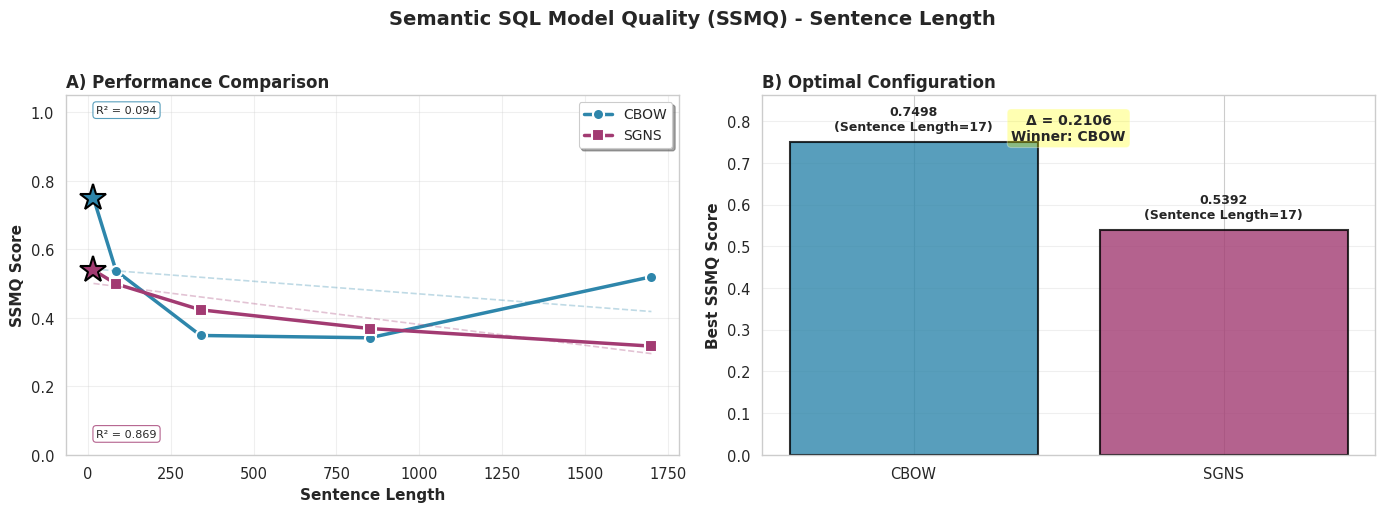


SSMQ SUMMARY - SENTENCE LENGTH
CBOW Best: 0.7498 at Sentence Length=17
SGNS Best: 0.5392 at Sentence Length=17



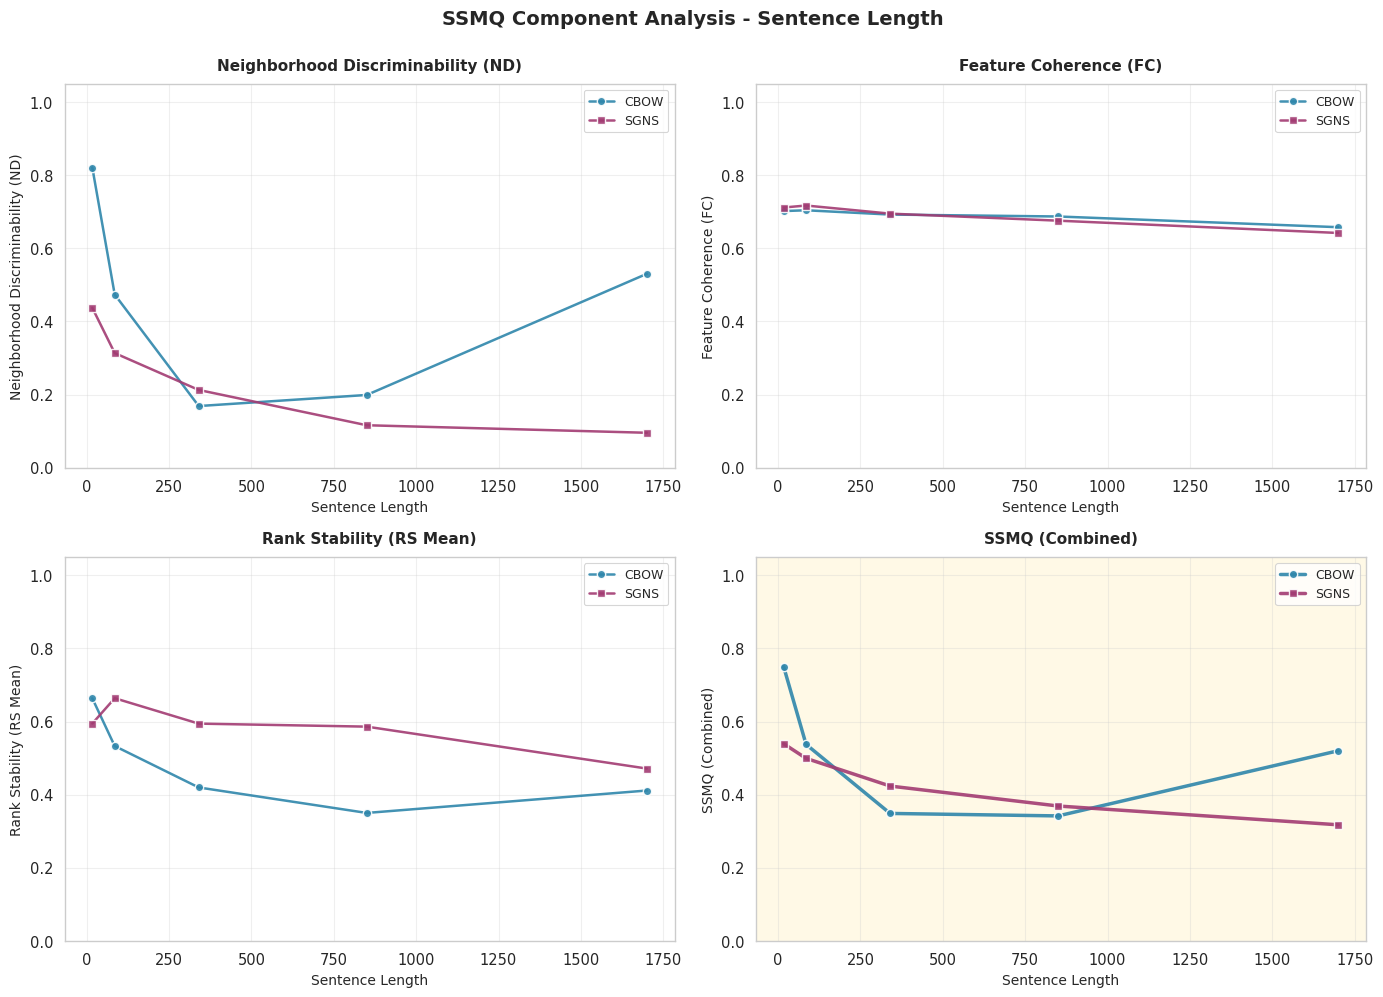


NUMERICAL RESULTS TABLE - SENTENCE

Sentence Length | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
17           | 0.8208    0.7017    0.6635    0.7498    | 0.4372    0.7115    0.5944    0.5392   
85           | 0.4735    0.7040    0.5329    0.5374    | 0.3134    0.7170    0.6637    0.4992   
340          | 0.1686    0.6922    0.4196    0.3486    | 0.2126    0.6948    0.5942    0.4235   
850          | 0.1989    0.6870    0.3500    0.3418    | 0.1161    0.6755    0.5860    0.3689   
1700         | 0.5302    0.6577    0.4113    0.5200    | 0.0955    0.6419    0.4713    0.3175   


####################################################################################################
# CATEGORY: VECTOR SIZE
###################################################

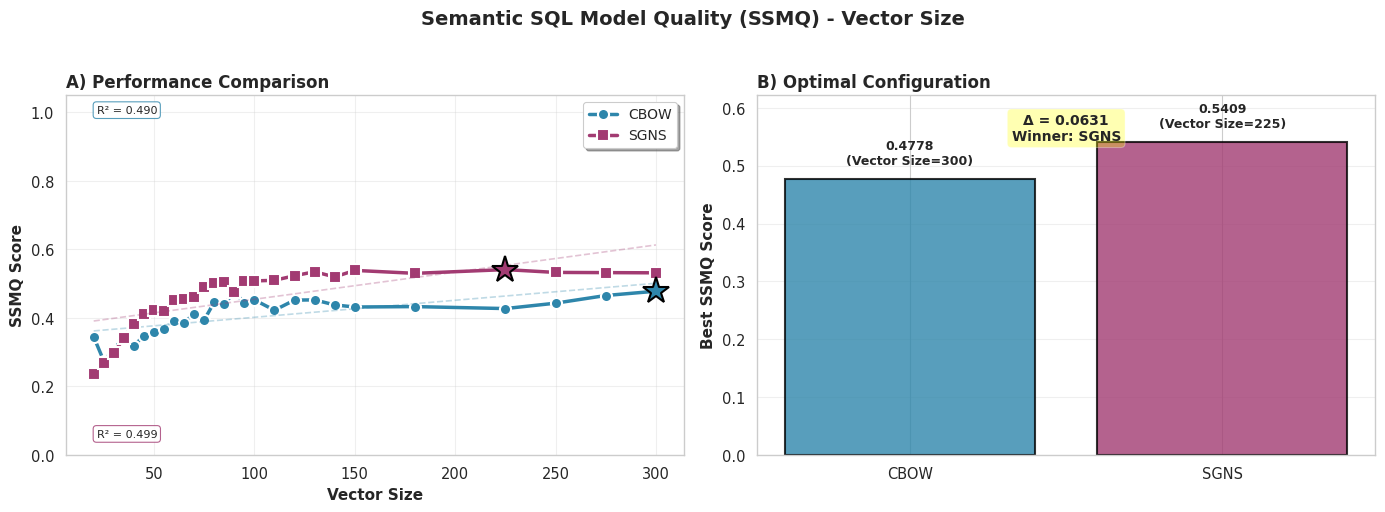


SSMQ SUMMARY - VECTOR SIZE
CBOW Best: 0.4778 at Vector Size=300
SGNS Best: 0.5409 at Vector Size=225



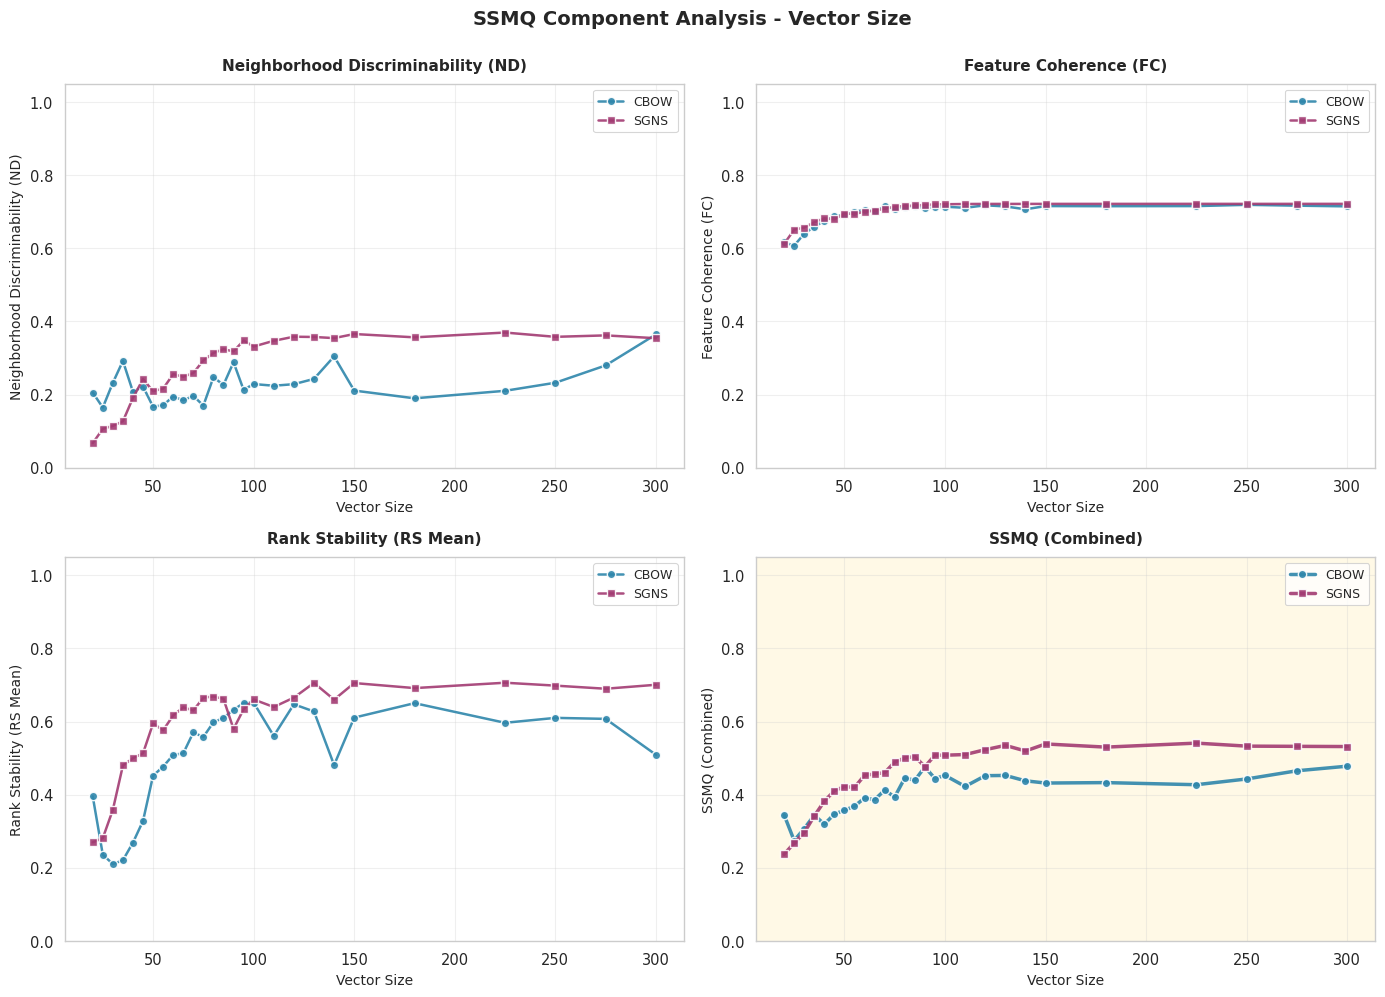


NUMERICAL RESULTS TABLE - VECTOR

Vector Size  | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
20           | 0.2056    0.6164    0.3952    0.3446    | 0.0671    0.6120    0.2696    0.2369   
25           | 0.1645    0.6072    0.2360    0.2745    | 0.1062    0.6509    0.2811    0.2676   
30           | 0.2322    0.6399    0.2102    0.3071    | 0.1143    0.6566    0.3586    0.2961   
35           | 0.2919    0.6590    0.2206    0.3439    | 0.1269    0.6711    0.4797    0.3416   
40           | 0.2073    0.6747    0.2689    0.3193    | 0.1910    0.6821    0.4996    0.3818   
45           | 0.2219    0.6876    0.3281    0.3469    | 0.2423    0.6792    0.5132    0.4110   
50           | 0.1666    0.6922    0.4521    0.3573    | 0.2091    0.6948    0.5946   

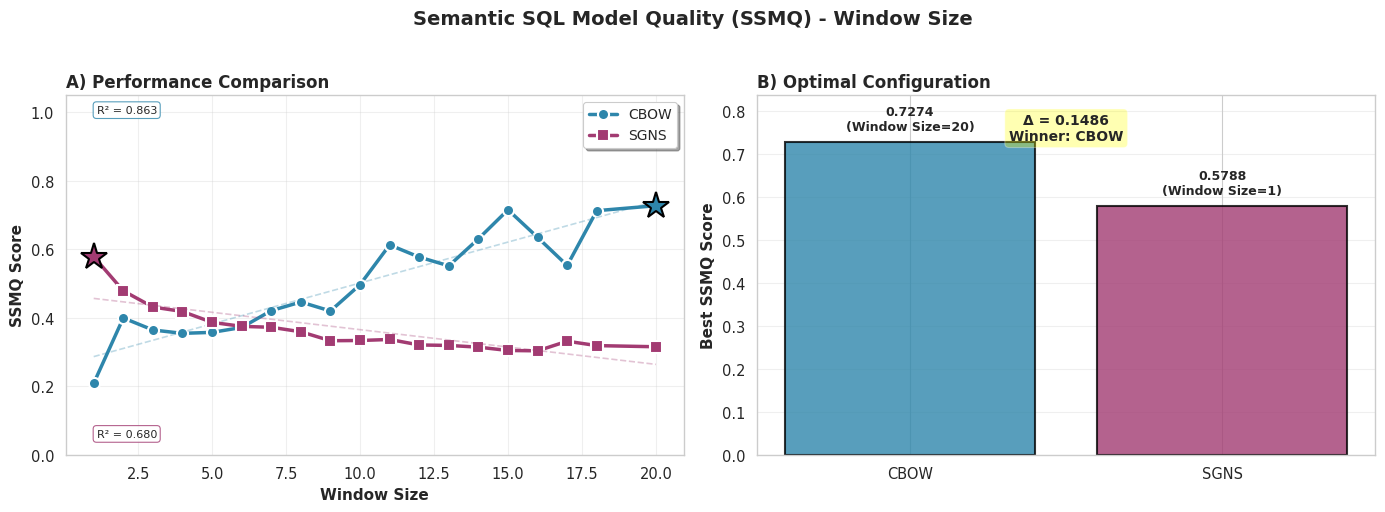


SSMQ SUMMARY - WINDOW SIZE
CBOW Best: 0.7274 at Window Size=20
SGNS Best: 0.5788 at Window Size=1



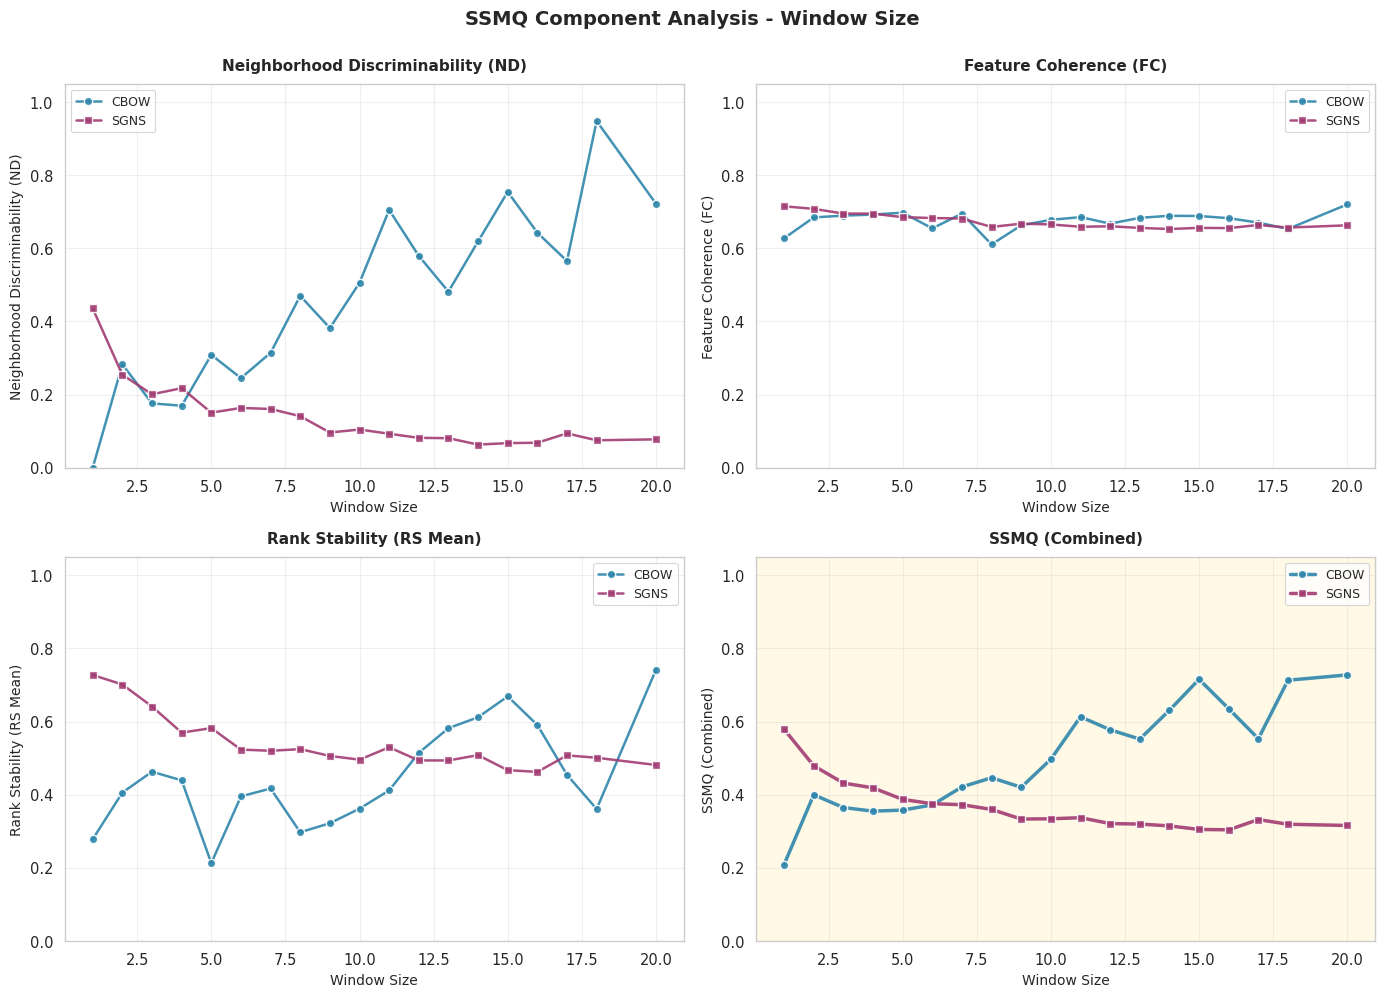


NUMERICAL RESULTS TABLE - WINDOWSIZE

Window Size  | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
1            | 0.0000    0.6273    0.2782    0.2089    | 0.4354    0.7148    0.7272    0.5788   
2            | 0.2823    0.6844    0.4057    0.3997    | 0.2539    0.7078    0.7012    0.4789   
3            | 0.1760    0.6893    0.4627    0.3647    | 0.2008    0.6949    0.6410    0.4317   
4            | 0.1694    0.6922    0.4390    0.3548    | 0.2175    0.6948    0.5696    0.4186   
5            | 0.3086    0.6974    0.2130    0.3577    | 0.1506    0.6851    0.5819    0.3869   
6            | 0.2450    0.6544    0.3952    0.3720    | 0.1634    0.6827    0.5232    0.3752   
7            | 0.3142    0.6949    0.4168    0.4211    | 0.1606    0.6814    0.520

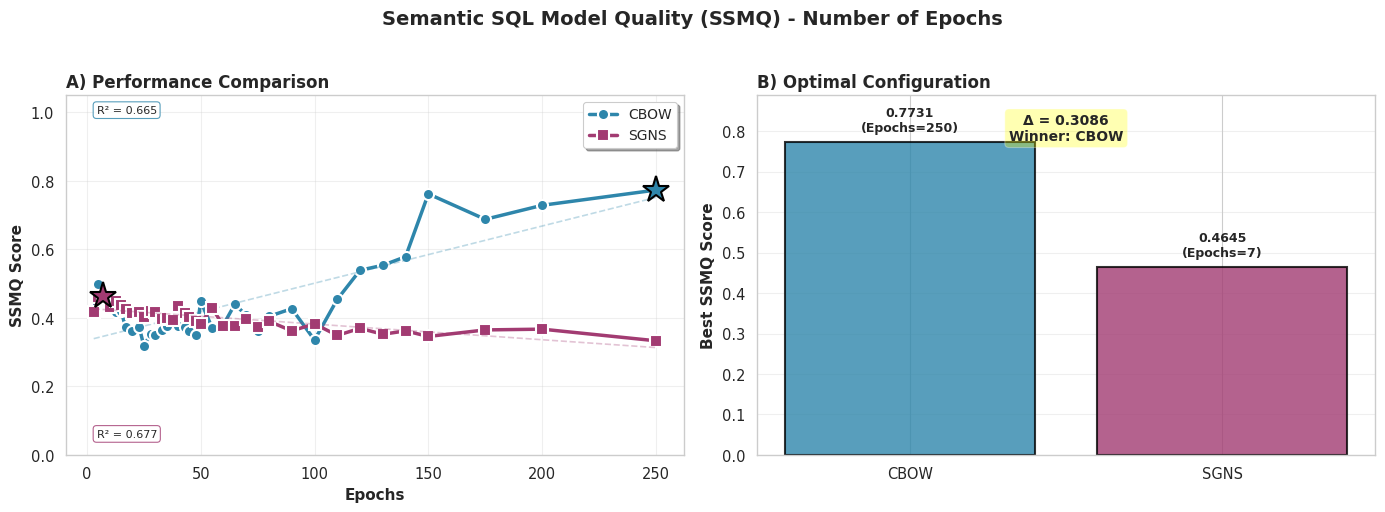


SSMQ SUMMARY - NUMBER OF EPOCHS
CBOW Best: 0.7731 at Epochs=250
SGNS Best: 0.4645 at Epochs=7



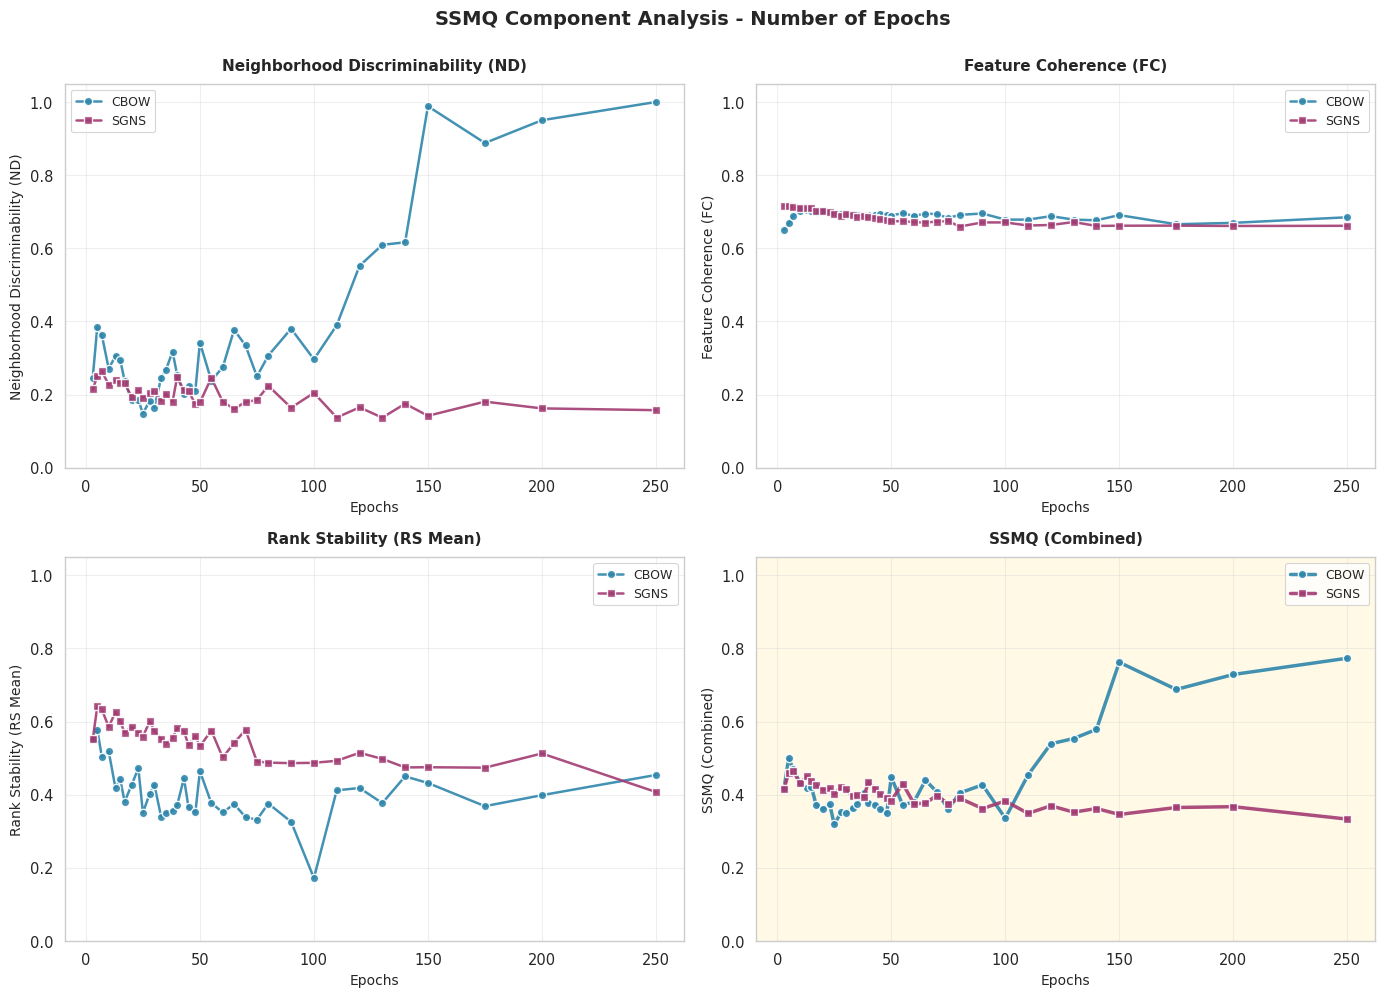


NUMERICAL RESULTS TABLE - EPOCH

Epochs       | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
3            | 0.2463    0.6505    0.5512    0.4186    | 0.2141    0.7165    0.5512    0.4157   
5            | 0.3854    0.6686    0.5779    0.4998    | 0.2503    0.7148    0.6412    0.4605   
7            | 0.3622    0.6886    0.5029    0.4697    | 0.2644    0.7118    0.6330    0.4645   
10           | 0.2710    0.7022    0.5184    0.4315    | 0.2262    0.7114    0.5849    0.4308   
13           | 0.3055    0.7034    0.4170    0.4185    | 0.2393    0.7114    0.6266    0.4499   
15           | 0.2957    0.7016    0.4420    0.4208    | 0.2323    0.7096    0.6013    0.4385   
17           | 0.2376    0.6994    0.3811    0.3730    | 0.2307    0.7030    0.5692    

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress
from scipy import interpolate

# Wissenschaftliches Farbschema - UNVERÄNDERT
COLORS = {
    'CBOW': '#2E86AB',      # Professionelles Blau
    'SGNS': '#A23B72',      # Kontrastierendes Magenta
    'SSMQ': '#F18F01',      # Orange für Wichtigkeit
    'ND': '#6A994E',        # Grün
    'FC': '#BC4B51',        # Rot
    'RS': '#8B8C89'         # Grau
}

# Linienstärken nach Wichtigkeit
LINEWIDTHS = {
    'primary': 2.5,         # SSMQ
    'secondary': 1.8,       # ND, FC, RS_mean
    'tertiary': 1.0         # Hintergrund-Komponenten
}

# Seaborn Style Setup
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Daten nach Kategorien strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        data_by_category[category] = {
            'CBOW': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            },
            'SGNS': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            }
        }
    
    # X-Wert und Label bestimmen
    category_mapping = {
        'sentence': ('Satzlänge', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window', 'Window Size'),
        'epoch': ('Epochs', 'Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling'),
        'sample': ('Sample', 'Sample'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Alpha')
    }
    
    if category in category_mapping:
        param_key, x_label = category_mapping[category]
        x_value = result['params'][param_key]
    else:
        x_value = None
        x_label = 'Parameter'
        print(f"Unknown category: {category}")
    
    # Metriken extrahieren
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    metrics_dict = {
        'nd': nd_value,
        'rs_mean': float(result['rs_mean']) if 'rs_mean' in result else None,
        'rs_5': float(result['rs_5']) if 'rs_5' in result else None,
        'rs_10': float(result['rs_10']) if 'rs_10' in result else None,
        'rs_20': float(result['rs_20']) if 'rs_20' in result else None,
        'fc': float(result['fc']) if 'fc' in result else None,
        'ssmq': float(result['ssmq']) if 'ssmq' in result else None
    }
    
    if x_value is not None:
        for metric_name, metric_value in metrics_dict.items():
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value


def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.2)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


def plot_ssmq_main_result(category, category_data, x_label, title_category):
    """
    FIGURE 1: SSMQ Hauptergebnis (Das wichtigste Ergebnis)
    Panel A: Line Plot mit Trends
    Panel B: Best Performance Bar Chart
    """
    cbow_ssmq_data = category_data['CBOW']['ssmq']
    sgns_ssmq_data = category_data['SGNS']['ssmq']
    
    if not cbow_ssmq_data and not sgns_ssmq_data:
        print(f"No SSMQ data for {category}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Semantic SQL Model Quality (SSMQ) - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Line Plot mit Trends - UNVERÄNDERT (schon richtig)
    if cbow_ssmq_data:
        x_cbow = sorted(cbow_ssmq_data.keys())
        y_cbow = [cbow_ssmq_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='CBOW', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_cbow, y_cbow, ax1, COLORS['CBOW'], 'top')
        
        # Markiere Maximum
        max_idx = np.argmax(y_cbow)
        ax1.plot(x_cbow[max_idx], y_cbow[max_idx], '*', 
                color=COLORS['CBOW'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    if sgns_ssmq_data:
        x_sgns = sorted(sgns_ssmq_data.keys())
        y_sgns = [sgns_ssmq_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='SGNS', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_sgns, y_sgns, ax1, COLORS['SGNS'], 'bottom')
        
        # Markiere Maximum
        max_idx = np.argmax(y_sgns)
        ax1.plot(x_sgns[max_idx], y_sgns[max_idx], '*', 
                color=COLORS['SGNS'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('SSMQ Score', fontsize=11, fontweight='bold')
    ax1.set_title('A) Performance Comparison', fontsize=12, loc='left', fontweight='bold')
    ax1.legend(fontsize=10, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Best Performance Comparison
    if cbow_ssmq_data and sgns_ssmq_data:
        max_cbow = max(cbow_ssmq_data.values())
        max_sgns = max(sgns_ssmq_data.values())
        max_cbow_param = max(cbow_ssmq_data, key=cbow_ssmq_data.get)
        max_sgns_param = max(sgns_ssmq_data, key=sgns_ssmq_data.get)
        
        algorithms = ['CBOW', 'SGNS']
        scores = [max_cbow, max_sgns]
        params = [max_cbow_param, max_sgns_param]
        colors_list = [COLORS['CBOW'], COLORS['SGNS']]
        
        bars = ax2.bar(algorithms, scores, color=colors_list, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
        
        # Werte auf Balken
        for bar, score, param in zip(bars, scores, params):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}\n({x_label}={param})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Best SSMQ Score', fontsize=11, fontweight='bold')
        ax2.set_title('B) Optimal Configuration', fontsize=12, loc='left', fontweight='bold')
        ax2.set_ylim([0, max(scores) * 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Differenz anzeigen
        diff = abs(max_cbow - max_sgns)
        winner = 'CBOW' if max_cbow > max_sgns else 'SGNS'
        ax2.text(0.5, 0.95, f'Δ = {diff:.4f}\nWinner: {winner}',
                transform=ax2.transAxes, ha='center', va='top',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    # Numerische Zusammenfassung
    print(f"\n{'='*80}")
    print(f"SSMQ SUMMARY - {title_category.upper()}")
    print(f"{'='*80}")
    if cbow_ssmq_data:
        print(f"CBOW Best: {max(cbow_ssmq_data.values()):.4f} at {x_label}={max(cbow_ssmq_data, key=cbow_ssmq_data.get)}")
    if sgns_ssmq_data:
        print(f"SGNS Best: {max(sgns_ssmq_data.values()):.4f} at {x_label}={max(sgns_ssmq_data, key=sgns_ssmq_data.get)}")
    print(f"{'='*80}\n")


def plot_component_analysis(category, category_data, x_label, title_category):
    """
    FIGURE 2: Komponenten-Analyse
    Zeigt wie sich SSMQ aus ND, FC und RS zusammensetzt
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'SSMQ Component Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    metrics_config = [
        ('nd', 'Neighborhood Discriminability (ND)', COLORS['ND'], axes[0, 0]),
        ('fc', 'Feature Coherence (FC)', COLORS['FC'], axes[0, 1]),
        ('rs_mean', 'Rank Stability (RS Mean)', COLORS['RS'], axes[1, 0]),
        ('ssmq', 'SSMQ (Combined)', COLORS['SSMQ'], axes[1, 1])
    ]
    
    for metric_key, metric_title, metric_color, ax in metrics_config:
        cbow_data = category_data['CBOW'][metric_key]
        sgns_data = category_data['SGNS'][metric_key]
        
        has_data = False
        
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            
            # CBOW: Immer professionelles Blau für alle Metriken
            cbow_color = COLORS['CBOW']  # Jetzt immer CBOW-Blau
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_cbow, y_cbow, '-o', color=cbow_color, 
                   linewidth=linewidth, markersize=6, label='CBOW',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            
            # SGNS: Immer kontrastierendes Magenta für alle Metriken
            sgns_color = COLORS['SGNS']  # Jetzt immer SGNS-Magenta
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_sgns, y_sgns, '-s', color=sgns_color, 
                   linewidth=linewidth, markersize=6, label='SGNS',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(metric_title, fontsize=10)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
            ax.legend(fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            # Für SSMQ: Hervorhebung
            if metric_key == 'ssmq':
                ax.set_facecolor('#FFF9E6')  # Leichter gelber Hintergrund
        else:
            ax.text(0.5, 0.5, f'No {metric_key.upper()} data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.show()


def plot_rank_stability_details(category, category_data, x_label, title_category):
    """
    OPTIONAL FIGURE 3: Detaillierte Rank Stability Analyse
    Nur wenn RS-Komponenten relevant sind
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Rank Stability Details - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    rs_components = ['rs_5', 'rs_10', 'rs_20']
    rs_labels = ['RS @5', 'RS @10', 'RS @20']
    rs_styles = [':', '--', '-.']
    
    # CBOW RS Components - Jetzt in hellen Blautönen
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['CBOW'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax1.plot(x, y, style, color='#87CEEB', alpha=0.7,  # Heller Blauton für CBOW
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # CBOW RS Mean (prominent) - Jetzt in voller CBOW-Farbe
    cbow_mean_data = category_data['CBOW']['rs_mean']
    if cbow_mean_data:
        x = sorted(cbow_mean_data.keys())
        y = [cbow_mean_data[xi] for xi in x]
        ax1.plot(x, y, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax1.set_title('CBOW - Rank Stability', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, frameon=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # SGNS RS Components - Jetzt in hellen Magentatönen
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['SGNS'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax2.plot(x, y, style, color='#FFB6C1', alpha=0.7,  # Heller Magentaton für SGNS
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # SGNS RS Mean (prominent) - Jetzt in voller SGNS-Farbe
    sgns_mean_data = category_data['SGNS']['rs_mean']
    if sgns_mean_data:
        x = sorted(sgns_mean_data.keys())
        y = [sgns_mean_data[xi] for xi in x]
        ax2.plot(x, y, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax2.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax2.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax2.set_title('SGNS - Rank Stability', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, frameon=True)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.show()


def create_summary_table(category, category_data, x_label):
    """
    Erstellt formatierte Tabelle für wissenschaftliche Arbeit
    """
    print(f"\n{'='*100}")
    print(f"NUMERICAL RESULTS TABLE - {category.upper()}")
    print(f"{'='*100}")
    
    # Sammle alle x-Werte
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['nd', 'fc', 'rs_mean', 'ssmq']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if not sorted_x:
        print("No data available")
        return
    
    # Header
    print(f"\n{x_label:<12} | {'CBOW':<40} | {'SGNS':<40}")
    print(f"{'':<12} | {'ND':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9} | {'ND':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9}")
    print("-" * 100)
    
    # Datenzeilen
    for x in sorted_x:
        cbow_nd = category_data['CBOW']['nd'].get(x, None)
        cbow_fc = category_data['CBOW']['fc'].get(x, None)
        cbow_rs = category_data['CBOW']['rs_mean'].get(x, None)
        cbow_ssmq = category_data['CBOW']['ssmq'].get(x, None)
        
        sgns_nd = category_data['SGNS']['nd'].get(x, None)
        sgns_fc = category_data['SGNS']['fc'].get(x, None)
        sgns_rs = category_data['SGNS']['rs_mean'].get(x, None)
        sgns_ssmq = category_data['SGNS']['ssmq'].get(x, None)
        
        def fmt(val):
            return f"{val:.4f}" if val is not None else "N/A"
        
        print(f"{str(x):<12} | {fmt(cbow_nd):<9} {fmt(cbow_fc):<9} {fmt(cbow_rs):<9} {fmt(cbow_ssmq):<9} | "
              f"{fmt(sgns_nd):<9} {fmt(sgns_fc):<9} {fmt(sgns_rs):<9} {fmt(sgns_ssmq):<9}")
    
    print(f"{'='*100}\n")


# Hauptschleife: Erzeuge Plots für jede Kategorie
print("\n" + "="*100)
print("WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION")
print("="*100 + "\n")

for category, category_data in data_by_category.items():
    # Label-Mapping
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # FIGURE 1: Hauptergebnis SSMQ
    plot_ssmq_main_result(category, category_data, x_label, title_category)
    
    # FIGURE 2: Komponenten-Analyse
    plot_component_analysis(category, category_data, x_label, title_category)
    
    # OPTIONAL FIGURE 3: RS Details (nur wenn interessant)
    # plot_rank_stability_details(category, category_data, x_label, title_category)
    
    # TABLE: Numerische Ergebnisse
    create_summary_table(category, category_data, x_label)

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)


TOP 10 WORD2VEC MODELS BY SSMQ SCORE



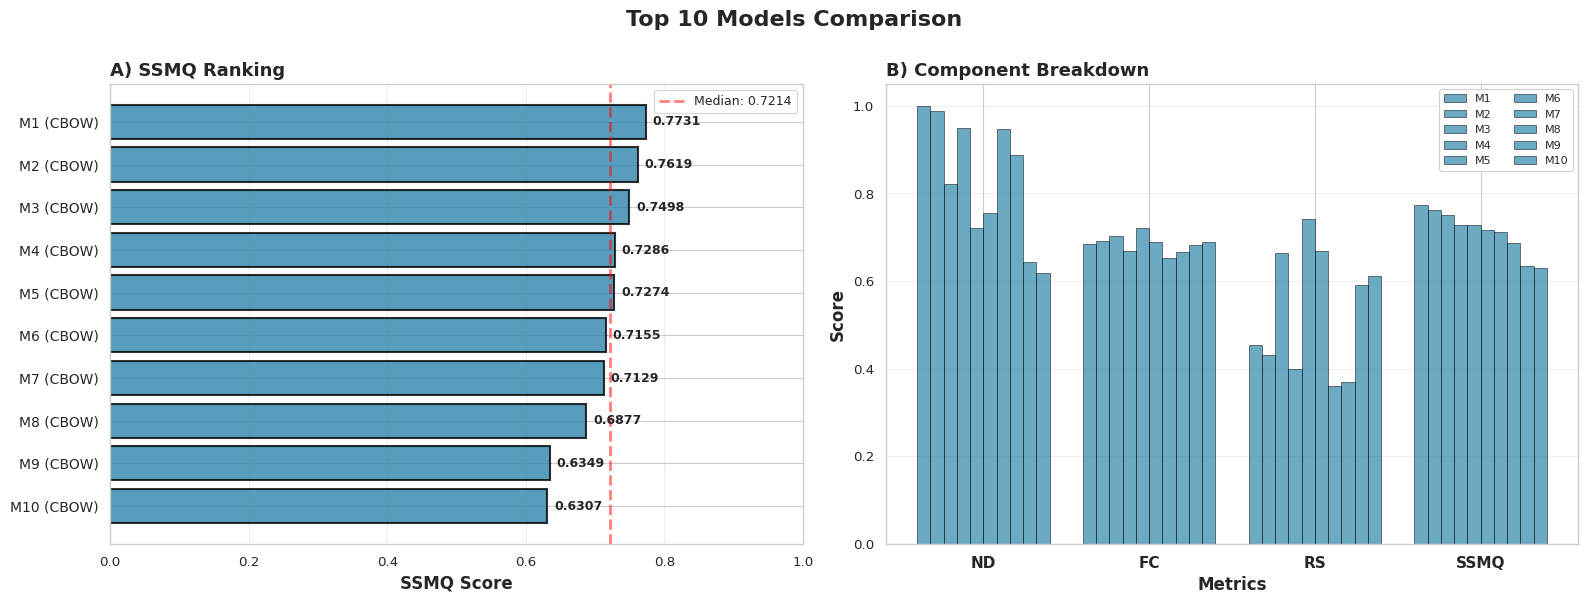

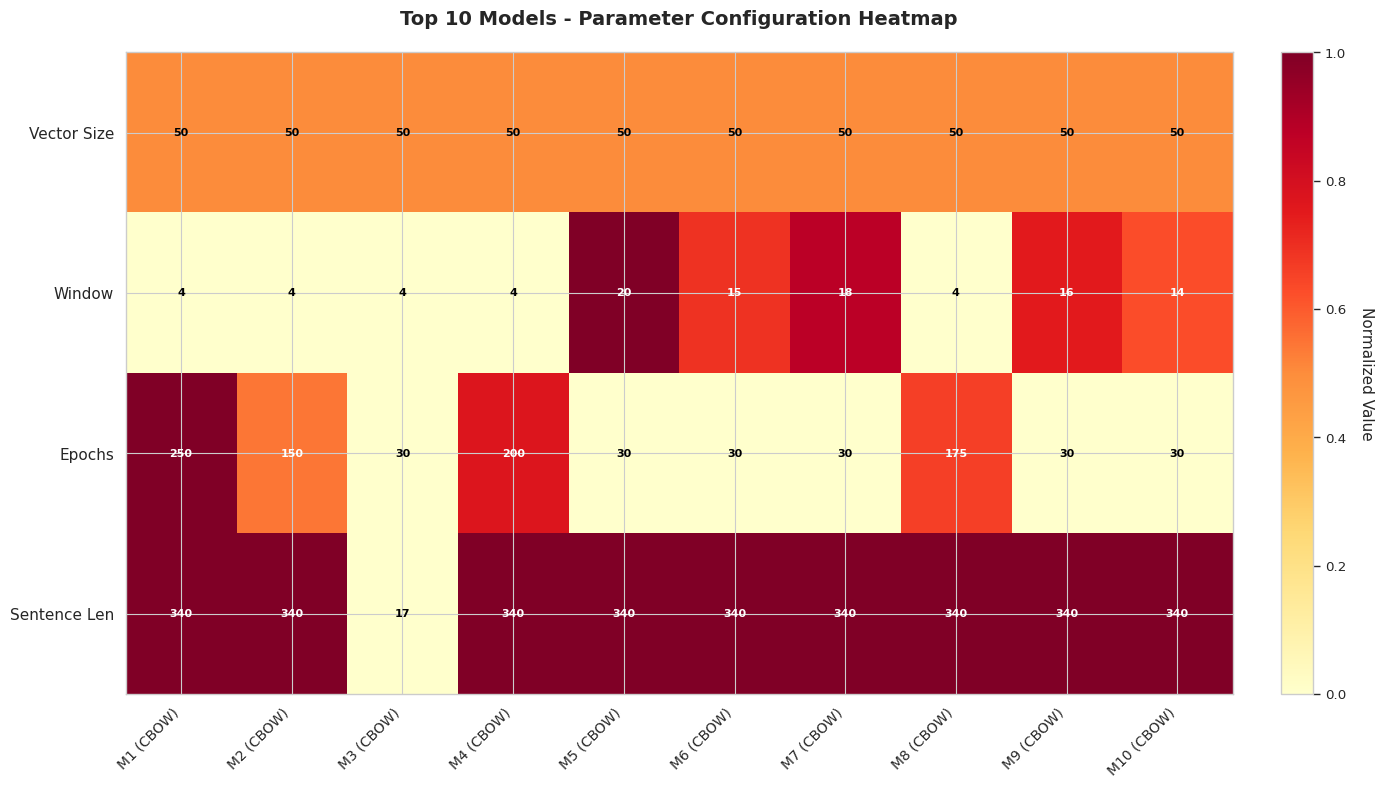


TOP 10 MODELS - SUMMARY TABLE (LaTeX-ready)

Model Algorithm   SSMQ     ND     FC     RS  Vec  Win  Epoch
   M1      CBOW 0.7731 1.0000 0.6848 0.4538   50    4    250
   M2      CBOW 0.7619 0.9885 0.6907 0.4319   50    4    150
   M3      CBOW 0.7498 0.8208 0.7017 0.6635   50    4     30
   M4      CBOW 0.7286 0.9502 0.6696 0.3985   50    4    200
   M5      CBOW 0.7274 0.7221 0.7200 0.7412   50   20     30
   M6      CBOW 0.7155 0.7544 0.6883 0.6687   50   15     30
   M7      CBOW 0.7129 0.9481 0.6529 0.3608   50   18     30
   M8      CBOW 0.6877 0.8879 0.6658 0.3685   50    4    175
   M9      CBOW 0.6349 0.6426 0.6823 0.5906   50   16     30
  M10      CBOW 0.6307 0.6189 0.6888 0.6116   50   14     30


LaTeX Table Code:
--------------------------------------------------------------------------------
\begin{tabular}{llllllrrr}
\toprule
Model & Algorithm & SSMQ & ND & FC & RS & Vec & Win & Epoch \\
\midrule
M1 & CBOW & 0.7731 & 1.0000 & 0.6848 & 0.4538 & 50 & 4 & 250 \\
M2 & CBOW 

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'SSMQ': '#F18F01',
    'ND': '#6A994E',
    'FC': '#BC4B51',
    'RS': '#8B8C89'
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Sammle alle Modelle mit ihren SSMQ-Werten und Parametern
# ==================================================================================

models_list = []

for result in test_results:
    # SSMQ-Wert extrahieren
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue  # Überspringe Modelle ohne SSMQ
    
    # Parameter extrahieren
    params = result['params']
    algorithm = params.get('Algorithmus', 'Unknown')
    
    # Alle Metriken sammeln
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': algorithm,
        'vector_size': params.get('Vector Size', 'N/A'),
        'window': params.get('Window', 'N/A'),
        'epochs': params.get('Epochs', 'N/A'),
        'sentence_length': params.get('Satzlänge', 'N/A'),
        'negative': params.get('Negative Sampling', 'N/A'),
        'sample': params.get('Sample', 'N/A'),
        'alpha': params.get('Alpha', 'N/A'),
        'hs': params.get('Hierarchical Softmax', 'N/A'),
    }
    
    models_list.append(model_data)

# ==================================================================================
# SCHRITT 2: Sortiere nach SSMQ und wähle Top 10
# ==================================================================================

models_sorted = sorted(models_list, key=lambda x: x['ssmq'], reverse=True)
top10_models = models_sorted[:10]

print("\n" + "="*120)
print("TOP 10 WORD2VEC MODELS BY SSMQ SCORE")
print("="*120 + "\n")

# ==================================================================================
# SCHRITT 3: Erstelle Model-IDs und Parameter-Tabelle
# ==================================================================================

model_ids = []
model_labels = []
model_colors = []

for i, model in enumerate(top10_models, 1):
    model_id = f"M{i}"
    model_ids.append(model_id)
    
    # Farbe basierend auf Algorithmus
    color = COLORS['CBOW'] if model['algorithm'] == 'CBOW' else COLORS['SGNS']
    model_colors.append(color)
    
    # Kurze Label für Plot
    label = f"{model_id} ({model['algorithm']})"
    model_labels.append(label)

# ==================================================================================
# FIGURE 1: Metriken-Vergleich (Radar Plot Style mit Bars)
# ==================================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Models Comparison', fontsize=16, fontweight='bold', y=1.00)

# Panel A: SSMQ Ranking
ssmq_scores = [model['ssmq'] for model in top10_models]
x_pos = np.arange(len(model_ids))

bars = ax1.barh(x_pos, ssmq_scores, color=model_colors, alpha=0.8, 
                edgecolor='black', linewidth=1.5)

# Werte auf Balken
for i, (bar, score, model) in enumerate(zip(bars, ssmq_scores, top10_models)):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2., 
            f'{score:.4f}', 
            ha='left', va='center', fontsize=9, fontweight='bold')

ax1.set_yticks(x_pos)
ax1.set_yticklabels(model_labels, fontsize=10)
ax1.invert_yaxis()  # Bestes Modell oben
ax1.set_xlabel('SSMQ Score', fontsize=12, fontweight='bold')
ax1.set_title('A) SSMQ Ranking', fontsize=13, fontweight='bold', loc='left')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim([0, 1.0])

# Trennlinie bei Median
median_ssmq = np.median(ssmq_scores)
ax1.axvline(median_ssmq, color='red', linestyle='--', linewidth=2, 
           alpha=0.5, label=f'Median: {median_ssmq:.4f}')
ax1.legend(fontsize=9)

# Panel B: Component Breakdown (alle Metriken für Top 10)
metrics = ['ND', 'FC', 'RS', 'SSMQ']
x_metrics = np.arange(len(metrics))
bar_width = 0.08  # Schmale Balken für 10 Modelle

for i, model in enumerate(top10_models):
    values = [model['nd'], model['fc'], model['rs_mean'], model['ssmq']]
    offset = (i - 4.5) * bar_width  # Zentriere die Balken
    
    ax2.bar(x_metrics + offset, values, bar_width, 
           label=model_ids[i], color=model_colors[i], 
           alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('B) Component Breakdown', fontsize=13, fontweight='bold', loc='left')
ax2.set_xticks(x_metrics)
ax2.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=8, ncol=2, loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ==================================================================================
# FIGURE 2: Detaillierte Parameter-Heatmap
# ==================================================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Erstelle Parameter-Matrix für Heatmap (ohne negative, sample, alpha)
param_names = ['Vector Size', 'Window', 'Epochs', 'Sentence Len']
param_keys = ['vector_size', 'window', 'epochs', 'sentence_length']

# Normalisiere Parameter für Heatmap (0-1 Skala)
param_matrix = []
param_raw_matrix = []

for model in top10_models:
    row = []
    raw_row = []
    for key in param_keys:
        val = model[key]
        raw_row.append(val)
        # Versuche numerischen Wert zu extrahieren
        try:
            num_val = float(val)
            row.append(num_val)
        except:
            row.append(0)
    param_matrix.append(row)
    param_raw_matrix.append(raw_row)

param_matrix = np.array(param_matrix)

# Normalisiere jede Spalte auf [0, 1]
param_matrix_norm = np.zeros_like(param_matrix)
for col in range(param_matrix.shape[1]):
    col_data = param_matrix[:, col]
    col_min = col_data.min()
    col_max = col_data.max()
    if col_max > col_min:
        param_matrix_norm[:, col] = (col_data - col_min) / (col_max - col_min)
    else:
        param_matrix_norm[:, col] = 0.5  # Alle gleich

# Erstelle Heatmap
im = ax.imshow(param_matrix_norm.T, cmap='YlOrRd', aspect='auto', 
              vmin=0, vmax=1, interpolation='nearest')

# Achsenbeschriftungen
ax.set_xticks(np.arange(len(model_ids)))
ax.set_yticks(np.arange(len(param_names)))
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(param_names, fontsize=11)

# Zeige tatsächliche Werte in Zellen
for i in range(len(model_ids)):
    for j in range(len(param_names)):
        text_val = param_raw_matrix[i][j]
        # Textfarbe basierend auf Helligkeit
        color = 'white' if param_matrix_norm[i, j] > 0.5 else 'black'
        ax.text(i, j, str(text_val), ha='center', va='center', 
               color=color, fontsize=8, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Normalized Value', rotation=270, labelpad=20, fontsize=11)

ax.set_title('Top 10 Models - Parameter Configuration Heatmap', 
            fontsize=14, fontweight='bold', pad=20)

# Trennlinie zwischen CBOW und SGNS (falls vorhanden)
cbow_count = sum(1 for m in top10_models if m['algorithm'] == 'CBOW')
if 0 < cbow_count < len(top10_models):
    ax.axvline(cbow_count - 0.5, color='blue', linewidth=3, alpha=0.6)
    ax.text(cbow_count/2 - 0.5, -0.8, 'CBOW', ha='center', fontsize=12, 
           fontweight='bold', color=COLORS['CBOW'])
    ax.text(cbow_count + (len(top10_models) - cbow_count)/2 - 0.5, -0.8, 
           'SGNS', ha='center', fontsize=12, fontweight='bold', 
           color=COLORS['SGNS'])

plt.tight_layout()
plt.show()

# ==================================================================================
# SUMMARY TABLE: Export-ready
# ==================================================================================

print("\n" + "="*120)
print("TOP 10 MODELS - SUMMARY TABLE (LaTeX-ready)")
print("="*120 + "\n")

# Erstelle DataFrame
df_data = []
for i, model in enumerate(top10_models, 1):
    df_data.append({
        'Model': f'M{i}',
        'Algorithm': model['algorithm'],
        'SSMQ': f"{model['ssmq']:.4f}",
        'ND': f"{model['nd']:.4f}",
        'FC': f"{model['fc']:.4f}",
        'RS': f"{model['rs_mean']:.4f}",
        'Vec': model['vector_size'],
        'Win': model['window'],
        'Epoch': model['epochs']
    })

df = pd.DataFrame(df_data)
print(df.to_string(index=False))
print("\n" + "="*120 + "\n")

# Optional: LaTeX Export
try:
    latex_table = df.to_latex(index=False, float_format="%.4f")
    print("LaTeX Table Code:")
    print("-" * 80)
    print(latex_table)
except:
    print("(pandas LaTeX export not available)")

print("\n" + "="*120)
print("ANALYSIS COMPLETE - Top 10 Models Identified and Visualized")
print("="*120)


SELECTED MODELS COMPARISON (2 best & 2 worst per algorithm)

BEST 2 CBOW MODELS:
  #1: CBOW | SSMQ: 0.7731 | Vec: 50, Win: 4, Epochs: 250
  #2: CBOW | SSMQ: 0.7619 | Vec: 50, Win: 4, Epochs: 150

WORST 2 CBOW MODELS:
  #1: CBOW | SSMQ: 0.2745 | Vec: 25, Win: 4, Epochs: 30
  #2: CBOW | SSMQ: 0.2089 | Vec: 50, Win: 1, Epochs: 30

BEST 2 SGNS MODELS:
  #1: SGNS | SSMQ: 0.5788 | Vec: 50, Win: 1, Epochs: 30
  #2: SGNS | SSMQ: 0.5409 | Vec: 225, Win: 4, Epochs: 30

WORST 2 SGNS MODELS:
  #1: SGNS | SSMQ: 0.2676 | Vec: 25, Win: 4, Epochs: 30
  #2: SGNS | SSMQ: 0.2369 | Vec: 20, Win: 4, Epochs: 30

EXTRACTING WORD VECTORS...

CBOW Best Models:
   Total words: 10053, Filtered (containing 'key_'): 10000, Kept: 53
   Examples of filtered words: ['key_10000', 'key_9999', 'key_9998', 'key_9997', 'key_9996']
   Examples of kept words: ['Churn_No', 'CreditCard_Yes', 'Age_Adults_in_their_Prime', 'Gender_Male', 'ActiveMember_Yes']
✓ CBOW Best Model #1: 53 words, 50 dimensions
   Total words: 10053, Fi

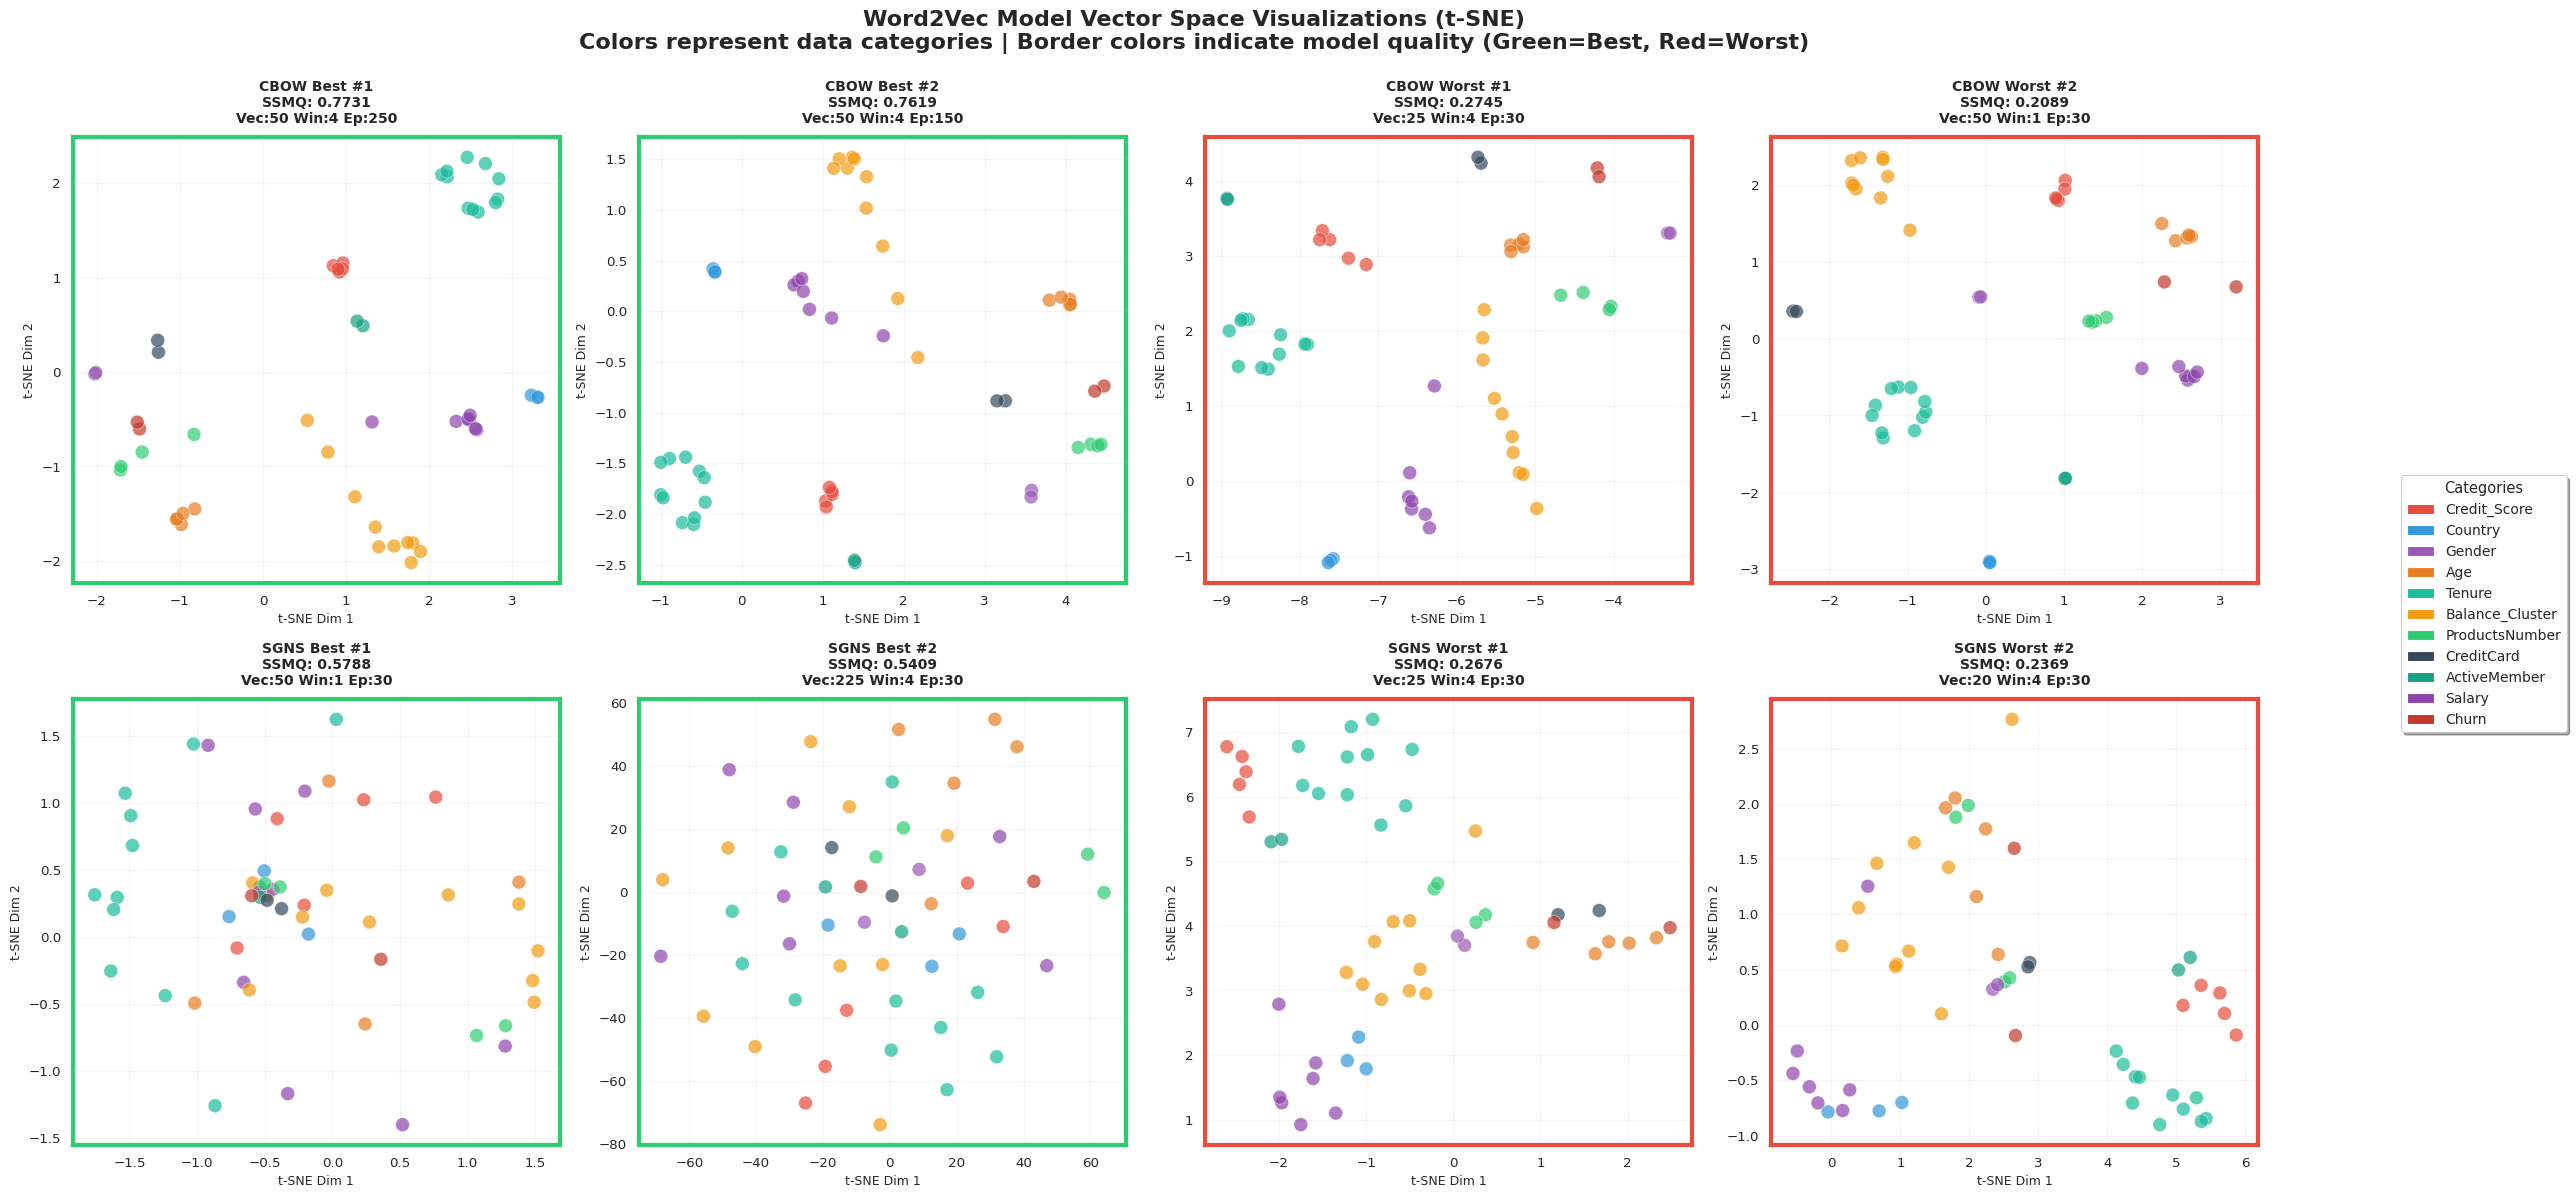


INDIVIDUAL VISUALIZATIONS COMPLETE



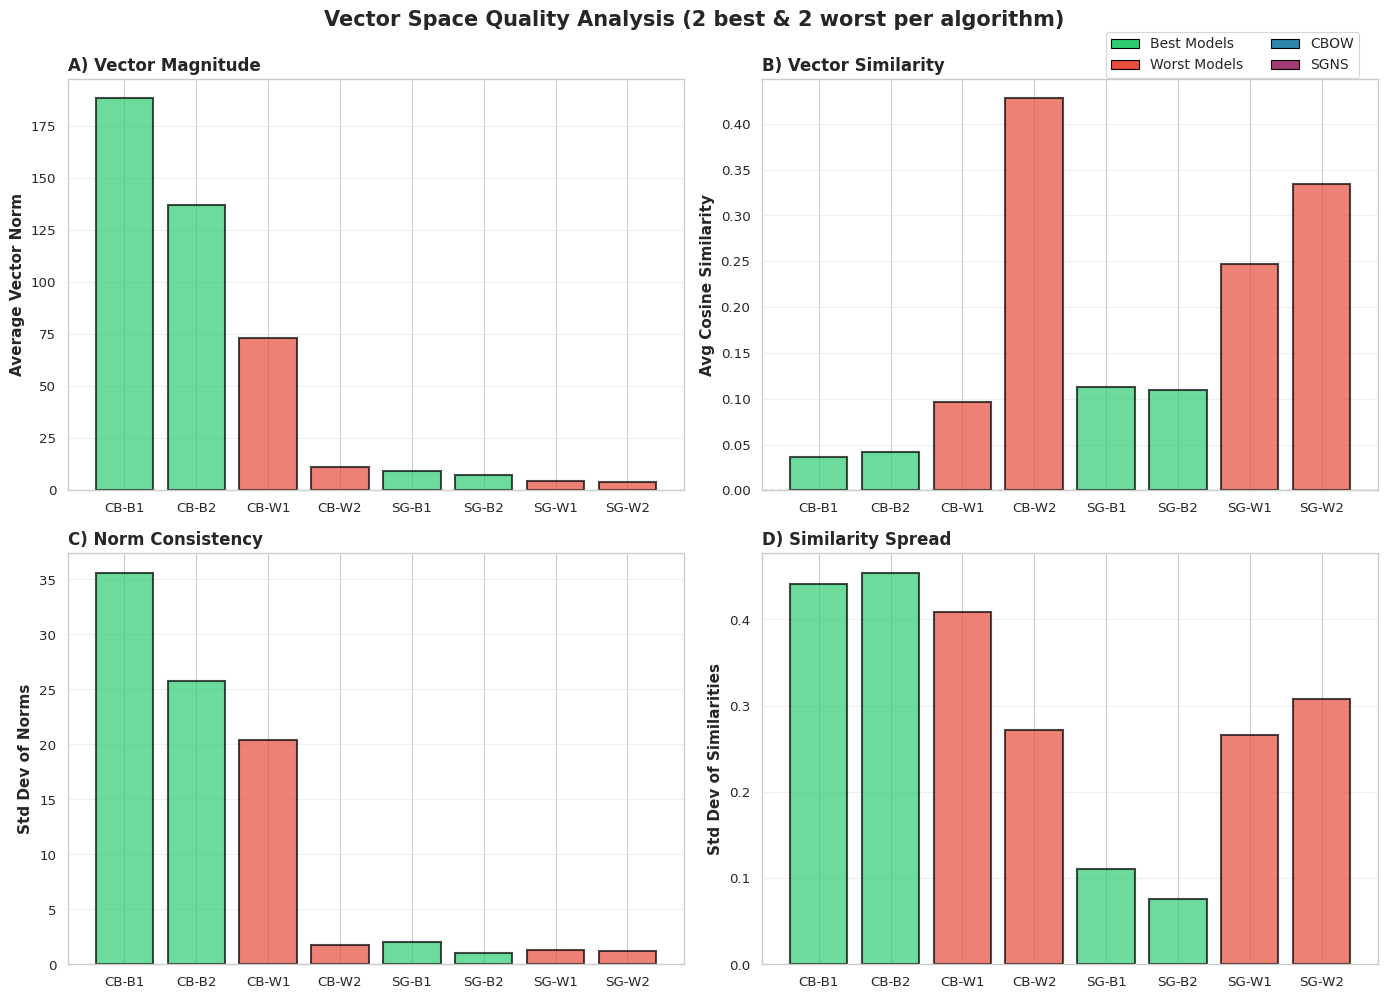


VECTOR SPACE STATISTICS SUMMARY

Model      Algorithm Quality  Avg Norm     Std Norm     Avg Sim      Std Sim     
--------------------------------------------------------------------------------
CB-B1      CBOW     Best     187.9866     35.6121      0.0368       0.4410      
CB-B2      CBOW     Best     136.8818     25.7646      0.0420       0.4543      
CB-W1      CBOW     Worst    73.2298      20.4131      0.0961       0.4090      
CB-W2      CBOW     Worst    11.0131      1.7713       0.4278       0.2724      
SG-B1      SGNS     Best     9.3732       2.0369       0.1133       0.1112      
SG-B2      SGNS     Best     7.2651       1.0349       0.1100       0.0764      
SG-W1      SGNS     Worst    4.4600       1.2889       0.2469       0.2656      
SG-W2      SGNS     Worst    3.7691       1.2609       0.3342       0.3080      


MODEL COMPARISON COMPLETE


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'best': '#2ECC71',    # Grün für beste Modelle
    'worst': '#E74C3C',   # Rot für schlechteste Modelle
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Finde 2 beste und 2 schlechteste CBOW- und SGNS-Modelle
# ==================================================================================

# Annahme: models_sorted existiert bereits aus vorherigem Code
# Falls nicht, hier nochmal erstellen:
models_list = []
for result in test_results:
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue
    
    # Speichere auch Referenz zum ursprünglichen Result-Objekt
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': result['params'].get('Algorithmus', 'Unknown'),
        'vector_size': result['params'].get('Vector Size', 'N/A'),
        'window': result['params'].get('Window', 'N/A'),
        'epochs': result['params'].get('Epochs', 'N/A'),
        'result_ref': result  # Referenz zum Original für Vektor-Zugriff
    }
    
    models_list.append(model_data)

# Trenne Modelle nach Algorithmus
cbow_models = [m for m in models_list if m['algorithm'].upper() == 'CBOW']
sgns_models = [m for m in models_list if m['algorithm'].upper() == 'SGNS']

# Sortiere nach SSMQ (absteigend)
cbow_sorted = sorted(cbow_models, key=lambda x: x['ssmq'], reverse=True)
sgns_sorted = sorted(sgns_models, key=lambda x: x['ssmq'], reverse=True)

# Wähle 2 beste und 2 schlechteste für jeden Algorithmus
best_2_cbow = cbow_sorted[:2]
worst_2_cbow = cbow_sorted[-2:] if len(cbow_sorted) >= 2 else []
best_2_sgns = sgns_sorted[:2]
worst_2_sgns = sgns_sorted[-2:] if len(sgns_sorted) >= 2 else []

# Kombiniere alle ausgewählten Modelle
selected_models = best_2_cbow + worst_2_cbow + best_2_sgns + worst_2_sgns

print("\n" + "="*100)
print("SELECTED MODELS COMPARISON (2 best & 2 worst per algorithm)")
print("="*100 + "\n")

print("BEST 2 CBOW MODELS:")
for i, model in enumerate(best_2_cbow, 1):
    print(f"  #{i}: CBOW | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nWORST 2 CBOW MODELS:")
for i, model in enumerate(worst_2_cbow, 1):
    print(f"  #{i}: CBOW | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nBEST 2 SGNS MODELS:")
for i, model in enumerate(best_2_sgns, 1):
    print(f"  #{i}: SGNS | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nWORST 2 SGNS MODELS:")
for i, model in enumerate(worst_2_sgns, 1):
    print(f"  #{i}: SGNS | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

# ==================================================================================
# SCHRITT 2: Extrahiere Word Vectors (falls verfügbar im result)
# ==================================================================================

def extract_word_vectors(model_data):
    """
    Extrahiert Word Vectors aus dem Gensim Word2Vec Modell.
    Filtert alle Wörter heraus, die "key_" (kleingeschrieben) im Namen enthalten.
    """
    result = model_data['result_ref']
    
    # Gensim Word2Vec Model aus 'used_model'
    if 'used_model' in result and 'model_object' in result['used_model']:
        model = result['used_model']['model_object']
        
        if hasattr(model, 'wv'):
            # Alle Wörter und ihre Vektoren
            all_vocab = list(model.wv.key_to_index.keys())
            
            # Filtere Wörter, die "key_" enthalten (case-insensitive für Sicherheit)
            filtered_vocab = [word for word in all_vocab if 'key_' not in word.lower()]
            
            if len(filtered_vocab) == 0:
                print(f"⚠️ Alle Wörter wurden gefiltert (nur key_* vorhanden)")
                return None, None
            
            # Extrahiere nur die gefilterten Vektoren
            filtered_indices = [model.wv.key_to_index[word] for word in filtered_vocab]
            filtered_vectors = model.wv.vectors[filtered_indices]
            
            # Debug-Ausgabe
            filtered_count = len(all_vocab) - len(filtered_vocab)
            print(f"   Total words: {len(all_vocab)}, Filtered (containing 'key_'): {filtered_count}, Kept: {len(filtered_vocab)}")
            
            # Zeige einige Beispiele der gefilterten und behaltenen Wörter
            if filtered_count > 0:
                key_words = [w for w in all_vocab if 'key_' in w.lower()][:5]
                print(f"   Examples of filtered words: {key_words}")
            
            kept_words = filtered_vocab[:5]
            print(f"   Examples of kept words: {kept_words}")
            
            return filtered_vectors, filtered_vocab
    
    print(f"⚠️ Keine Vektoren gefunden für Modell {model_data['algorithm']}")
    return None, None


def get_category_color(word):
    """
    Bestimmt die Farbe basierend auf der Kategorie (Präfix vor dem ersten Unterstrich).
    Format: [Kategorie]_Wert → z.B. Credit_Score_Fair, Country_France, Gender_Female
    """
    # Kategorie-Farbschema
    category_colors = {
        'Credit_Score': '#E74C3C',      # Rot
        'Country': '#3498DB',           # Blau
        'Gender': '#9B59B6',            # Lila
        'Age': '#E67E22',               # Orange
        'Tenure': '#1ABC9C',            # Türkis
        'Balance_Cluster': '#F39C12',   # Gelb-Orange
        'ProductsNumber': '#2ECC71',    # Grün
        'CreditCard': '#34495E',        # Dunkelgrau
        'ActiveMember': '#16A085',      # Dunkel-Türkis
        'Salary': '#8E44AD',            # Dunkel-Lila
        'Churn': '#C0392B',             # Dunkel-Rot
    }
    
    # Versuche Kategorie zu extrahieren
    # Für Balance_Cluster_X müssen wir die ersten zwei Teile nehmen
    parts = word.split('_')
    
    # Spezialfall: Balance_Cluster
    if len(parts) >= 2 and parts[0] == 'Balance' and parts[1] == 'Cluster':
        category = 'Balance_Cluster'
    # Normalfall: Erste Teil ist die Kategorie
    elif len(parts) >= 1:
        category = parts[0]
        # Für zweistufige Kategorien wie Credit_Score
        if len(parts) >= 2 and f"{parts[0]}_{parts[1]}" in category_colors:
            category = f"{parts[0]}_{parts[1]}"
    else:
        category = None
    
    # Gib Farbe zurück oder Standard-Grau
    return category_colors.get(category, '#95A5A6')  # Standard: Grau

# Sammle Vektoren für ausgewählte Modelle
cbow_best_vectors = []
cbow_worst_vectors = []
sgns_best_vectors = []
sgns_worst_vectors = []

cbow_best_vocab = []
cbow_worst_vocab = []
sgns_best_vocab = []
sgns_worst_vocab = []

print("\n" + "="*100)
print("EXTRACTING WORD VECTORS...")
print("="*100 + "\n")

# CBOW beste Modelle
print("CBOW Best Models:")
for i, model in enumerate(best_2_cbow):
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        cbow_best_vectors.append(vectors)
        cbow_best_vocab.append(vocab)
        print(f"✓ CBOW Best Model #{i+1}: {vectors.shape[0]} words, {vectors.shape[1]} dimensions")
    else:
        print(f"✗ CBOW Best Model #{i+1}: No vectors found")

# CBOW schlechteste Modelle
print("\nCBOW Worst Models:")
for i, model in enumerate(worst_2_cbow):
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        cbow_worst_vectors.append(vectors)
        cbow_worst_vocab.append(vocab)
        print(f"✓ CBOW Worst Model #{i+1}: {vectors.shape[0]} words, {vectors.shape[1]} dimensions")
    else:
        print(f"✗ CBOW Worst Model #{i+1}: No vectors found")

# SGNS beste Modelle
print("\nSGNS Best Models:")
for i, model in enumerate(best_2_sgns):
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        sgns_best_vectors.append(vectors)
        sgns_best_vocab.append(vocab)
        print(f"✓ SGNS Best Model #{i+1}: {vectors.shape[0]} words, {vectors.shape[1]} dimensions")
    else:
        print(f"✗ SGNS Best Model #{i+1}: No vectors found")

# SGNS schlechteste Modelle
print("\nSGNS Worst Models:")
for i, model in enumerate(worst_2_sgns):
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        sgns_worst_vectors.append(vectors)
        sgns_worst_vocab.append(vocab)
        print(f"✓ SGNS Worst Model #{i+1}: {vectors.shape[0]} words, {vectors.shape[1]} dimensions")
    else:
        print(f"✗ SGNS Worst Model #{i+1}: No vectors found")

# ==================================================================================
# FIGURE 1: Separate Vector Space Visualization für jedes Modell (8 Modelle)
# ==================================================================================

# Kombiniere alle Vektoren für die Visualisierung
all_vectors_to_plot = []
vector_categories = []

# CBOW Beste Modelle
for i in range(min(2, len(cbow_best_vectors))):
    all_vectors_to_plot.append({
        'vectors': cbow_best_vectors[i],
        'vocab': cbow_best_vocab[i],
        'model_info': best_2_cbow[i],
        'algorithm': 'CBOW',
        'quality': 'Best',
        'rank': i + 1,
        'border_color': COLORS['best'],
        'plot_color': COLORS['CBOW']
    })

# CBOW Schlechteste Modelle
for i in range(min(2, len(cbow_worst_vectors))):
    all_vectors_to_plot.append({
        'vectors': cbow_worst_vectors[i],
        'vocab': cbow_worst_vocab[i],
        'model_info': worst_2_cbow[i],
        'algorithm': 'CBOW',
        'quality': 'Worst',
        'rank': i + 1,
        'border_color': COLORS['worst'],
        'plot_color': COLORS['CBOW']
    })

# SGNS Beste Modelle
for i in range(min(2, len(sgns_best_vectors))):
    all_vectors_to_plot.append({
        'vectors': sgns_best_vectors[i],
        'vocab': sgns_best_vocab[i],
        'model_info': best_2_sgns[i],
        'algorithm': 'SGNS',
        'quality': 'Best',
        'rank': i + 1,
        'border_color': COLORS['best'],
        'plot_color': COLORS['SGNS']
    })

# SGNS Schlechteste Modelle
for i in range(min(2, len(sgns_worst_vectors))):
    all_vectors_to_plot.append({
        'vectors': sgns_worst_vectors[i],
        'vocab': sgns_worst_vocab[i],
        'model_info': worst_2_sgns[i],
        'algorithm': 'SGNS',
        'quality': 'Worst',
        'rank': i + 1,
        'border_color': COLORS['worst'],
        'plot_color': COLORS['SGNS']
    })

if all_vectors_to_plot:
    print(f"\n{'='*100}")
    print(f"CREATING INDIVIDUAL MODEL VISUALIZATIONS ({len(all_vectors_to_plot)} separate plots)")
    print(f"{'='*100}\n")
    
    # Erstelle 8 separate Plots (2 Reihen x 4 Spalten)
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle('Word2Vec Model Vector Space Visualizations (t-SNE)\n' + 
                 'Colors represent data categories | Border colors indicate model quality (Green=Best, Red=Worst)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    
    for idx, model_data in enumerate(all_vectors_to_plot):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        
        vectors = model_data['vectors']
        vocab = model_data['vocab']
        model_info = model_data['model_info']
        algorithm = model_data['algorithm']
        quality = model_data['quality']
        rank = model_data['rank']
        border_color = model_data['border_color']
        plot_color = model_data['plot_color']
        
        # Limitiere auf max 2000 Wörter für Performance
        max_words = min(2000, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_words, replace=False)
        vectors_sample = vectors[sample_indices]
        vocab_sample = [vocab[i] for i in sample_indices]
        
        print(f"Processing {algorithm} {quality} Model #{rank}: {max_words} words...")
        
        # t-SNE Projektion
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_words-1), max_iter=500)
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        # Bestimme Farben basierend auf Kategorien
        point_colors = [get_category_color(word) for word in vocab_sample]
        
        # Plot Punkte mit kategorie-basierten Farben
        scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                            c=point_colors, alpha=0.7, s=100, edgecolors='white', linewidth=0.4)
        
        # Annotiere 20 zufällige Wörter
        num_annotations = 0  # min(20, len(vocab_sample))
        annotation_indices = np.random.choice(len(vocab_sample), num_annotations, replace=False)
        
        for ann_idx in annotation_indices:
            word = vocab_sample[ann_idx]
            word_color = get_category_color(word)
            ax.annotate(word, 
                       (vectors_2d[ann_idx, 0], vectors_2d[ann_idx, 1]),
                       fontsize=7, alpha=0.9, color='black',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor=word_color, 
                                alpha=0.5, edgecolor='black', linewidth=0.5))
        
        # Titel und Labels
        title = f"{algorithm} {quality} #{rank}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Vec:{model_info['vector_size']} Win:{model_info['window']} Ep:{model_info['epochs']}"
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=9)
        ax.set_ylabel('t-SNE Dim 2', fontsize=9)
        ax.grid(True, alpha=0.2)
        
        # Farbiger Rahmen um den Plot (Best/Worst Indikator)
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
    
    # Entferne leere Subplots falls weniger als 8 Modelle
    for idx in range(len(all_vectors_to_plot), len(axes)):
        axes[idx].set_visible(False)
    
    # Erstelle Legende für Kategorien
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Credit_Score'),
        Patch(facecolor='#3498DB', label='Country'),
        Patch(facecolor='#9B59B6', label='Gender'),
        Patch(facecolor='#E67E22', label='Age'),
        Patch(facecolor='#1ABC9C', label='Tenure'),
        Patch(facecolor='#F39C12', label='Balance_Cluster'),
        Patch(facecolor='#2ECC71', label='ProductsNumber'),
        Patch(facecolor='#34495E', label='CreditCard'),
        Patch(facecolor='#16A085', label='ActiveMember'),
        Patch(facecolor='#8E44AD', label='Salary'),
        Patch(facecolor='#C0392B', label='Churn'),
    ]
    
    # Legende rechts neben den Plots
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.0, 0.5), fontsize=10, title='Categories',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])  # Platz für Legende lassen
    plt.show()
    
    print(f"\n{'='*100}")
    print("INDIVIDUAL VISUALIZATIONS COMPLETE")
    print(f"{'='*100}\n")

# ==================================================================================
# FIGURE 2: Vector Space Quality Metrics
# ==================================================================================

def compute_vector_statistics(vectors):
    """Berechnet Statistiken über den Vektorraum"""
    # Durchschnittliche Norm
    norms = np.linalg.norm(vectors, axis=1)
    avg_norm = np.mean(norms)
    std_norm = np.std(norms)
    
    # Durchschnittliche Kosinus-Ähnlichkeit (Sampling für Performance)
    sample_size = min(1000, len(vectors))
    sample_indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[sample_indices]
    
    # Normalisiere für Kosinus-Ähnlichkeit
    sample_vectors_norm = sample_vectors / (np.linalg.norm(sample_vectors, axis=1, keepdims=True) + 1e-8)
    similarity_matrix = np.dot(sample_vectors_norm, sample_vectors_norm.T)
    
    # Entferne Diagonale (Selbst-Ähnlichkeit)
    mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
    avg_similarity = np.mean(similarity_matrix[mask])
    std_similarity = np.std(similarity_matrix[mask])
    
    return {
        'avg_norm': avg_norm,
        'std_norm': std_norm,
        'avg_similarity': avg_similarity,
        'std_similarity': std_similarity
    }

# Berechne Statistiken für alle Modelle
all_stats = []
all_labels = []

# CBOW Beste Modelle
for i, vectors in enumerate(cbow_best_vectors):
    stats = compute_vector_statistics(vectors)
    all_stats.append(stats)
    all_labels.append(f'CB-B{i+1}')

# CBOW Schlechteste Modelle
for i, vectors in enumerate(cbow_worst_vectors):
    stats = compute_vector_statistics(vectors)
    all_stats.append(stats)
    all_labels.append(f'CB-W{i+1}')

# SGNS Beste Modelle
for i, vectors in enumerate(sgns_best_vectors):
    stats = compute_vector_statistics(vectors)
    all_stats.append(stats)
    all_labels.append(f'SG-B{i+1}')

# SGNS Schlechteste Modelle
for i, vectors in enumerate(sgns_worst_vectors):
    stats = compute_vector_statistics(vectors)
    all_stats.append(stats)
    all_labels.append(f'SG-W{i+1}')

if all_stats:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Vector Space Quality Analysis (2 best & 2 worst per algorithm)', 
                 fontsize=15, fontweight='bold', y=0.995)
    
    # Farben für die Balken
    bar_colors = []
    for label in all_labels:
        if label.startswith('CB-B'):
            bar_colors.append('#2ECC71')  # Grün für CBOW Best
        elif label.startswith('CB-W'):
            bar_colors.append('#E74C3C')  # Rot für CBOW Worst
        elif label.startswith('SG-B'):
            bar_colors.append('#2ECC71')  # Grün für SGNS Best
        elif label.startswith('SG-W'):
            bar_colors.append('#E74C3C')  # Rot für SGNS Worst
    
    # Plot 1: Vector Norms
    ax1 = axes[0, 0]
    avg_norms = [s['avg_norm'] for s in all_stats]
    
    bars = ax1.bar(all_labels, avg_norms, color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Average Vector Norm', fontsize=11, fontweight='bold')
    ax1.set_title('A) Vector Magnitude', fontsize=12, fontweight='bold', loc='left')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Cosine Similarity Distribution
    ax2 = axes[0, 1]
    avg_sims = [s['avg_similarity'] for s in all_stats]
    
    bars = ax2.bar(all_labels, avg_sims, color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Avg Cosine Similarity', fontsize=11, fontweight='bold')
    ax2.set_title('B) Vector Similarity', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Plot 3: Norm Standard Deviation
    ax3 = axes[1, 0]
    std_norms = [s['std_norm'] for s in all_stats]
    
    bars = ax3.bar(all_labels, std_norms, color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Std Dev of Norms', fontsize=11, fontweight='bold')
    ax3.set_title('C) Norm Consistency', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Similarity Standard Deviation
    ax4 = axes[1, 1]
    std_sims = [s['std_similarity'] for s in all_stats]
    
    bars = ax4.bar(all_labels, std_sims, color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Std Dev of Similarities', fontsize=11, fontweight='bold')
    ax4.set_title('D) Similarity Spread', fontsize=12, fontweight='bold', loc='left')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Legende hinzufügen
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ECC71', edgecolor='black', label='Best Models'),
        Patch(facecolor='#E74C3C', edgecolor='black', label='Worst Models'),
        Patch(facecolor=COLORS['CBOW'], edgecolor='black', label='CBOW'),
        Patch(facecolor=COLORS['SGNS'], edgecolor='black', label='SGNS')
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
              bbox_to_anchor=(0.98, 0.98), ncol=2)
    
    plt.tight_layout()
    plt.show()
    
    # Numerische Zusammenfassung
    print("\n" + "="*100)
    print("VECTOR SPACE STATISTICS SUMMARY")
    print("="*100)
    print(f"\n{'Model':<10} {'Algorithm':<8} {'Quality':<8} {'Avg Norm':<12} {'Std Norm':<12} {'Avg Sim':<12} {'Std Sim':<12}")
    print("-" * 80)
    
    for i, (label, stats) in enumerate(zip(all_labels, all_stats)):
        algorithm = "CBOW" if label.startswith('CB') else "SGNS"
        quality = "Best" if label.endswith('B1') or label.endswith('B2') else "Worst"
        print(f"{label:<10} {algorithm:<8} {quality:<8} {stats['avg_norm']:<12.4f} {stats['std_norm']:<12.4f} "
              f"{stats['avg_similarity']:<12.4f} {stats['std_similarity']:<12.4f}")
    
    print("="*100 + "\n")

else:
    print("\n⚠️ Vektoren konnten nicht extrahiert werden.")
    print("Bitte passe die Funktion 'extract_word_vectors()' an deine Datenstruktur an.")
    print("Mögliche Speicherorte: result['model'].wv.vectors, result['vectors'], result['embeddings']")

print("\n" + "="*100)
print("MODEL COMPARISON COMPLETE")
print("="*100)

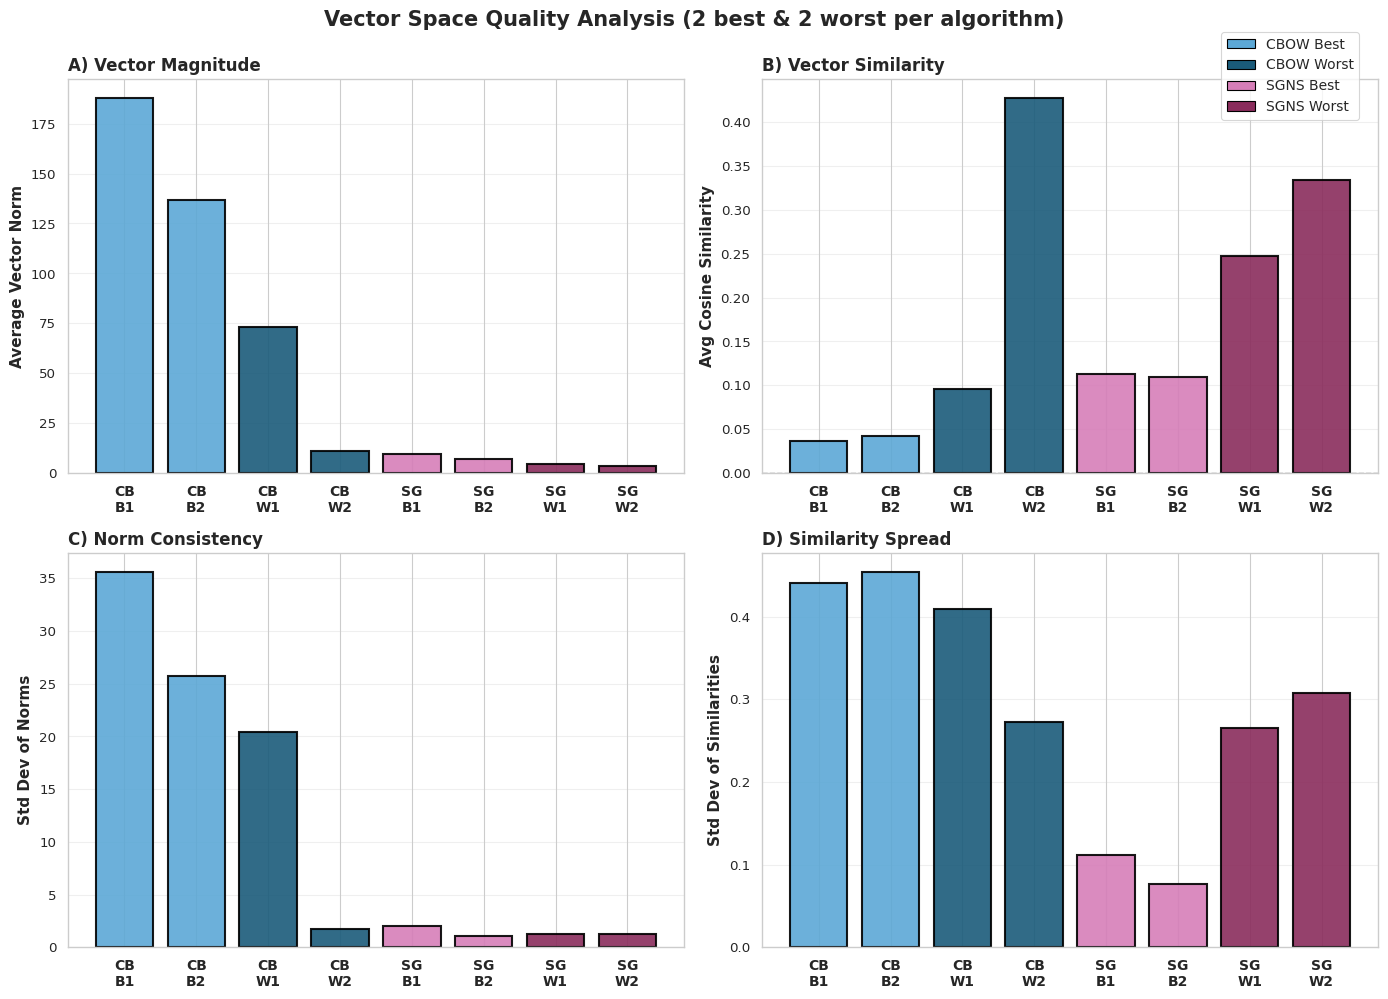


VECTOR SPACE STATISTICS SUMMARY

Model      Algorithm Quality  Avg Norm     Std Norm     Avg Sim      Std Sim     
--------------------------------------------------------------------------------
CB-B1      CBOW     Best     187.9866     35.6121      0.0368       0.4410      
CB-B2      CBOW     Best     136.8818     25.7646      0.0420       0.4543      
CB-W1      CBOW     Best     73.2298      20.4131      0.0961       0.4090      
CB-W2      CBOW     Best     11.0131      1.7713       0.4278       0.2724      
SG-B1      SGNS     Best     9.3732       2.0369       0.1133       0.1112      
SG-B2      SGNS     Best     7.2651       1.0349       0.1100       0.0764      
SG-W1      SGNS     Worst    4.4600       1.2889       0.2469       0.2656      
SG-W2      SGNS     Worst    3.7691       1.2609       0.3342       0.3080      



In [12]:
# Nur den relevanten Teil für die FIGURE 2 anpassen:

# ==================================================================================
# FIGURE 2: Vector Space Quality Metrics (mit kombinierter Farbkodierung)
# ==================================================================================

# [Vorheriger Code bleibt gleich bis zur Farbdefinition...]

if all_stats:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Vector Space Quality Analysis (2 best & 2 worst per algorithm)', 
                 fontsize=15, fontweight='bold', y=0.995)
    
    # KOMBINIERTE FARBEN: Algorithmus + Qualität
    # Für Best: Hellerer Ton des Algorithmus-Farbtons
    # Für Worst: Dunklerer Ton des Algorithmus-Farbtons
    bar_colors = []
    for label in all_labels:
        if label.startswith('CB-B'):  # CBOW Best
            # Hellblau für CBOW Best
            bar_colors.append('#5CA8D6')  
        elif label.startswith('CB-W'):  # CBOW Worst
            # Dunkelblau für CBOW Worst
            bar_colors.append('#1A5B7A')  
        elif label.startswith('SG-B'):  # SGNS Best
            # Hellrosa für SGNS Best
            bar_colors.append('#D67EB8')  
        elif label.startswith('SG-W'):  # SGNS Worst
            # Dunkelrosa für SGNS Worst
            bar_colors.append('#8A2C5C')  
    
    # Plot 1: Vector Norms
    ax1 = axes[0, 0]
    avg_norms = [s['avg_norm'] for s in all_stats]
    
    bars = ax1.bar(all_labels, avg_norms, color=bar_colors, alpha=0.9, 
                   edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Average Vector Norm', fontsize=11, fontweight='bold')
    ax1.set_title('A) Vector Magnitude', fontsize=12, fontweight='bold', loc='left')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Verbesserte x-Achsenbeschriftung mit Algorithmus-Info
    xtick_labels = []
    for label in all_labels:
        algo = "CBOW" if label.startswith('CB') else "SGNS"
        quality = "B" if 'B' in label[-2] else "W"
        num = label[-1]
        xtick_labels.append(f"{algo[:2]}\n{quality}{num}")
    
    ax1.set_xticks(range(len(all_labels)))
    ax1.set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
    
    # Plot 2: Cosine Similarity Distribution
    ax2 = axes[0, 1]
    avg_sims = [s['avg_similarity'] for s in all_stats]
    
    bars = ax2.bar(all_labels, avg_sims, color=bar_colors, alpha=0.9, 
                   edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Avg Cosine Similarity', fontsize=11, fontweight='bold')
    ax2.set_title('B) Vector Similarity', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xticks(range(len(all_labels)))
    ax2.set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
    
    # Plot 3: Norm Standard Deviation
    ax3 = axes[1, 0]
    std_norms = [s['std_norm'] for s in all_stats]
    
    bars = ax3.bar(all_labels, std_norms, color=bar_colors, alpha=0.9, 
                   edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Std Dev of Norms', fontsize=11, fontweight='bold')
    ax3.set_title('C) Norm Consistency', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_xticks(range(len(all_labels)))
    ax3.set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
    
    # Plot 4: Similarity Standard Deviation
    ax4 = axes[1, 1]
    std_sims = [s['std_similarity'] for s in all_stats]
    
    bars = ax4.bar(all_labels, std_sims, color=bar_colors, alpha=0.9, 
                   edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Std Dev of Similarities', fontsize=11, fontweight='bold')
    ax4.set_title('D) Similarity Spread', fontsize=12, fontweight='bold', loc='left')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_xticks(range(len(all_labels)))
    ax4.set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
    
    # VERBESSERTE LEGENDE mit kombinierten Farben
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#5CA8D6', edgecolor='black', label='CBOW Best'),
        Patch(facecolor='#1A5B7A', edgecolor='black', label='CBOW Worst'),
        Patch(facecolor='#D67EB8', edgecolor='black', label='SGNS Best'),
        Patch(facecolor='#8A2C5C', edgecolor='black', label='SGNS Worst')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
              bbox_to_anchor=(0.98, 0.98))
    
    plt.tight_layout()
    plt.show()
    
    # Numerische Zusammenfassung
    print("\n" + "="*100)
    print("VECTOR SPACE STATISTICS SUMMARY")
    print("="*100)
    print(f"\n{'Model':<10} {'Algorithm':<8} {'Quality':<8} {'Avg Norm':<12} {'Std Norm':<12} {'Avg Sim':<12} {'Std Sim':<12}")
    print("-" * 80)
    
    for i, (label, stats) in enumerate(zip(all_labels, all_stats)):
        algorithm = "CBOW" if label.startswith('CB') else "SGNS"
        quality = "Best" if 'B' in label else "Worst"
        print(f"{label:<10} {algorithm:<8} {quality:<8} {stats['avg_norm']:<12.4f} {stats['std_norm']:<12.4f} "
              f"{stats['avg_similarity']:<12.4f} {stats['std_similarity']:<12.4f}")
    
    print("="*100 + "\n")